<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/GEDI_L1B_L2A_L2B_Native_EO_Res_Multi_Branch_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Roadmap

Stage 0

0- Prep Data

Stage 1

1 — Embeddings	Train images	Train embeddings	frozen

1 — Embeddings	Val & test images	Val/test embeddings	frozen

Stage 2

2 — Fusion training	Train embeddings	Fusion model	learn to predict RH

2 — Fusion validation	Val embeddings	Val loss / metrics	tune

2 — Fusion test	Test embeddings	Test metrics	evaluate

Stage 3

3 — Inference	New imagery (2024)	Predicted RH map

# Stage 0

In [1]:
!pip install rasterio torch torchinfo tqdm matplotlib timm torchmetrics --quiet
!pip install -U kaleido

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    '2024_Imagery_For_Inference'
    'data_32_32_patches_11_4_25',
    'target_data',
    'data',
    'data_NaN_filtered',
    'models',
    "model_animations",
    'scripts',
    'notebooks',
    'config',
    'results',
    'prediction_surface'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inferencedata_32_32_patches_11_4_25
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/model_animations
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/prediction_surface


## Sort Find Prep data

In [4]:
import os

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Output directory:", PROCESSED_DIR)


Output directory: /content/processed_32x32_normalized


In [5]:
import os
import re
from collections import Counter

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"


In [6]:
pattern = re.compile(
    r"(?P<covariate>.*?)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_"
    r"(?P<row_id>[0-9]+)_block_"
    r"(?P<block_id>[0-9]+)\.tif$"
)


In [7]:
tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith(".tif")]

selected_files = []
splits = []

for filename in tif_files:
    m = pattern.match(filename)
    if m:
        if m.group("product_field") == "GEDI_L2A":
            selected_files.append(filename)
            splits.append(m.group("split"))


In [8]:
split_counts = Counter(splits)
split_counts


Counter({'test': 501, 'train': 2105, 'val': 255})

In [9]:
print("Found", len(selected_files), "TIFFs with product_field = GEDI_L2A")

print("\nSplit counts:")
for k, v in split_counts.items():
    print(f"{k}: {v}")

print("\nFirst 10 selected TIFFs:")
for f in selected_files[:10]:
    print(f)


Found 2861 TIFFs with product_field = GEDI_L2A

Split counts:
test: 501
train: 2105
val: 255

First 10 selected TIFFs:
s2idx_test_GEDI_L2A_2022358084911_867_block_6013897.tif
s2idx_train_GEDI_L2A_2020196021509_973_block_5943897.tif
s2_train_GEDI_L2A_2020196021509_495_block_5953899.tif
s2_train_GEDI_L2A_2021135083748_1617_block_6013891.tif
s2_test_GEDI_L2A_2022358084911_856_block_6013897.tif
s2_train_GEDI_L2A_2022358084911_1344_block_6023897.tif
s2_test_GEDI_L2A_2022358084911_244_block_5923889.tif
s2_train_GEDI_L2A_2022358084911_1766_block_5983893.tif
s2_train_GEDI_L2A_2020196021509_1445_block_5953897.tif
s2_train_GEDI_L2A_2022358084911_1215_block_5933889.tif


## Move Selected files

In [10]:
import os
import shutil

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"
PROCESSED_DIR = "/content/processed_32x32_normalized"

os.makedirs(PROCESSED_DIR, exist_ok=True)

moved = 0
missing = 0

for fname in selected_files:
    src = os.path.join(RASTER_DIR, fname)
    dst = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(src):
        shutil.copy2(src, dst)   # or use shutil.move(src, dst) if you want to REMOVE originals
        moved += 1
    else:
        print("❗ MISSING FILE:", fname)
        missing += 1

print("=====================================")
print("Selected files moved:", moved)
print("Missing source files:", missing)
print("Destination folder:", PROCESSED_DIR)


Selected files moved: 2861
Missing source files: 0
Destination folder: /content/processed_32x32_normalized


## Investigate a set of Tifs before modifying/prepping

In [11]:
import random

sample_files = random.sample(selected_files, 5)
sample_files


['tcap_train_GEDI_L2A_2020196021509_1368_block_5913894.tif',
 's2idx_train_GEDI_L2A_2020196021509_1446_block_5953897.tif',
 'landsatidx_val_GEDI_L2A_2020196021509_444_block_5923897.tif',
 'landsat_test_GEDI_L2A_2021135083748_1487_block_5933898.tif',
 's2_train_GEDI_L2A_2022358084911_306_block_5953892.tif']


FILE: tcap_train_GEDI_L2A_2020196021509_1368_block_5913894.tif
BANDS: 6
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.2355152815580368
      max:  0.5136139988899231
      mean: 0.3710873541799751
      std:  0.066068714278731

  Band 2 statistics:
      min:  0.026508169248700142
      max:  0.21220842003822327
      mean: 0.09973575326505008
      std:  0.039555347574895705

  Band 3 statistics:
      min:  -0.11566475033760071
      max:  0.0401943176984787
      mean: -0.043110268942063656
      std:  0.03282981282223429

  Band 4 statistics:
      min:  -0.0690387561917305
      max:  -0.0432475209236145
      mean: -0.05069117019842337
      std:  0.003725222375854647

  Band 5 statistics:
      min:  -0.007140890695154667
      max:  0.066120944917202
      mean: 0.031246845723341663
      std:  0.015502664632502067

  Band 6 statistics:
      min:  -0.03739616647362709
      max:  -0.01577917113900

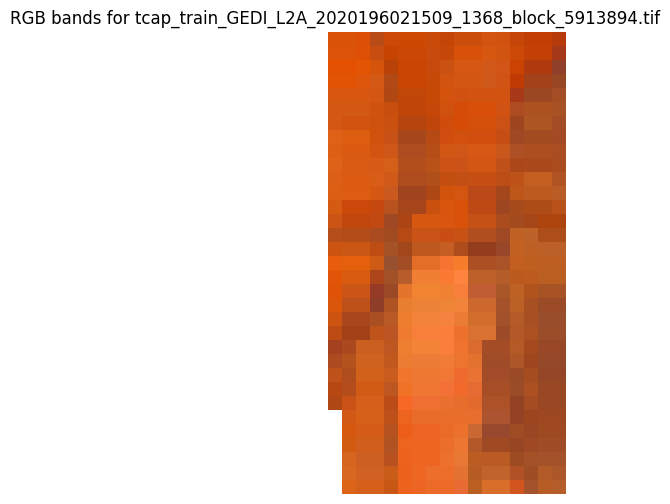


FILE: s2idx_train_GEDI_L2A_2020196021509_1446_block_5953897.tif
BANDS: 8
SIZE (pixels): 34 x 33
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.6151769757270813
      max:  0.8394626379013062
      mean: 0.7098943893390969
      std:  0.03484813199889684

  Band 2 statistics:
      min:  -0.7553297281265259
      max:  -0.6513473391532898
      mean: -0.7215837102097836
      std:  0.016694263905464853

  Band 3 statistics:
      min:  0.3448607623577118
      max:  0.5878286957740784
      mean: 0.45692934797090645
      std:  0.034708428795883886

  Band 4 statistics:
      min:  -0.6369193196296692
      max:  -0.4107120633125305
      mean: -0.5946910921583839
      std:  0.029905299577212906

  Band 5 statistics:
      min:  0.3455984592437744
      max:  0.523165225982666
      mean: 0.43893066792352103
      std:  0.025718221690097322

  Band 6 statistics:
      min:  0.09133460372686386
      max:  0.46489793062210083
    

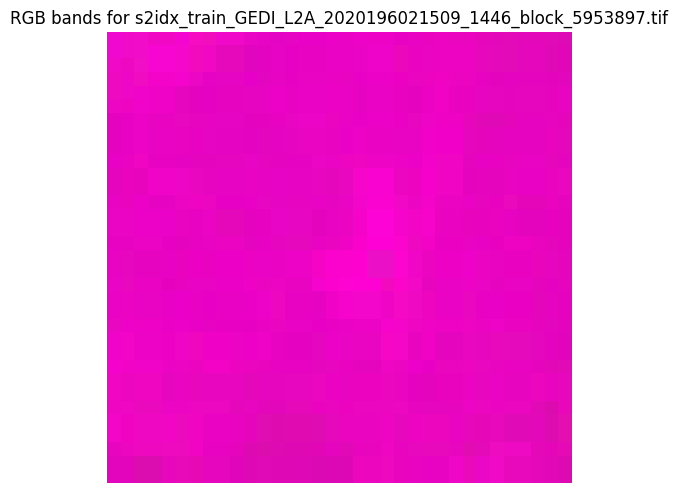


FILE: landsatidx_val_GEDI_L2A_2020196021509_444_block_5923897.tif
BANDS: 7
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.4786927103996277
      max:  0.8086930513381958
      mean: 0.6450301731968276
      std:  0.058051559921991

  Band 2 statistics:
      min:  -0.7865219116210938
      max:  -0.536261796951294
      mean: -0.6727373676085494
      std:  0.038542366214904124

  Band 3 statistics:
      min:  -0.7091569304466248
      max:  -0.5319258570671082
      mean: -0.6187592505095091
      std:  0.02220356480077711

  Band 4 statistics:
      min:  0.21779300272464752
      max:  0.5613915324211121
      mean: 0.37287910338713554
      std:  0.06466840868372076

  Band 5 statistics:
      min:  -0.13847261667251587
      max:  0.3728337287902832
      mean: 0.09429172480054378
      std:  0.08551679347177861

  Band 6 statistics:
      min:  -0.3728337287902832
      max:  0.13847261667251587
    

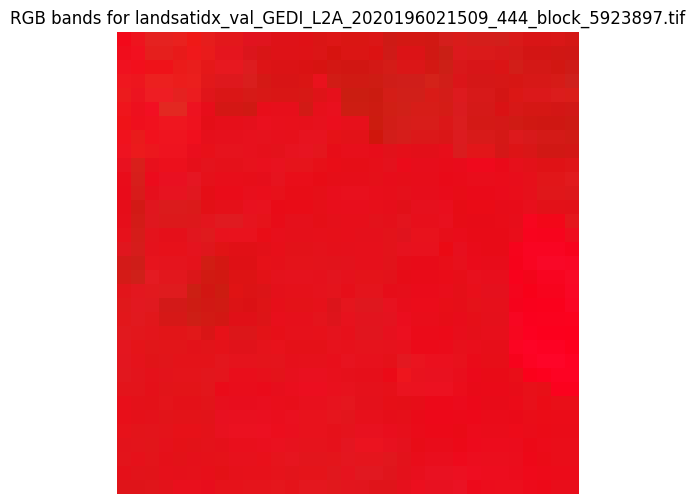


FILE: landsat_test_GEDI_L2A_2021135083748_1487_block_5933898.tif
BANDS: 6
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.016397500410676003
      max:  0.08138000220060349
      mean: 0.04611518945719421
      std:  0.014172122911138476

  Band 2 statistics:
      min:  0.023409999907016754
      max:  0.06160749867558479
      mean: 0.04080922980651711
      std:  0.0049593474720760035

  Band 3 statistics:
      min:  7808.0
      max:  8694.0
      mean: 8248.35766758494
      std:  149.7916334796169

  Band 4 statistics:
      min:  0.10046499967575073
      max:  0.24327249825000763
      mean: 0.18514660355199686
      std:  0.02657570926584656

  Band 5 statistics:
      min:  0.08539500087499619
      max:  0.2853200137615204
      mean: 0.17963493699541433
      std:  0.03404774527026918

  Band 6 statistics:
      min:  8960.0
      max:  13534.0
      mean: 10854.568870523415
      std:  972.3619

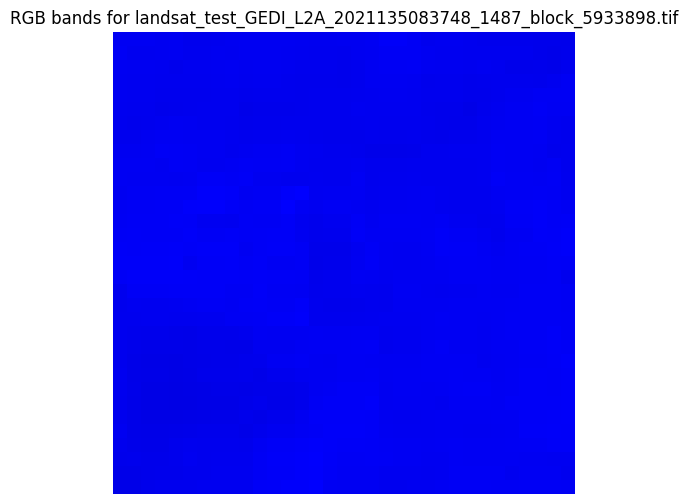


FILE: s2_train_GEDI_L2A_2022358084911_306_block_5953892.tif
BANDS: 6
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.024700000882148743
      max:  0.19232499599456787
      mean: 0.04795764793879261
      std:  0.013876270973672878

  Band 2 statistics:
      min:  0.04036666825413704
      max:  0.19824999570846558
      mean: 0.05573519591886198
      std:  0.012421145832732397

  Band 3 statistics:
      min:  0.02798333391547203
      max:  0.18454286456108093
      mean: 0.03888062480837107
      std:  0.010802353713628391

  Band 4 statistics:
      min:  0.1378999948501587
      max:  0.4081999957561493
      mean: 0.2943690234194252
      std:  0.041975860606292346

  Band 5 statistics:
      min:  0.13490000367164612
      max:  0.37248000502586365
      mean: 0.20514462803243103
      std:  0.02365531602279305

  Band 6 statistics:
      min:  0.07280000299215317
      max:  0.314424991607666
    

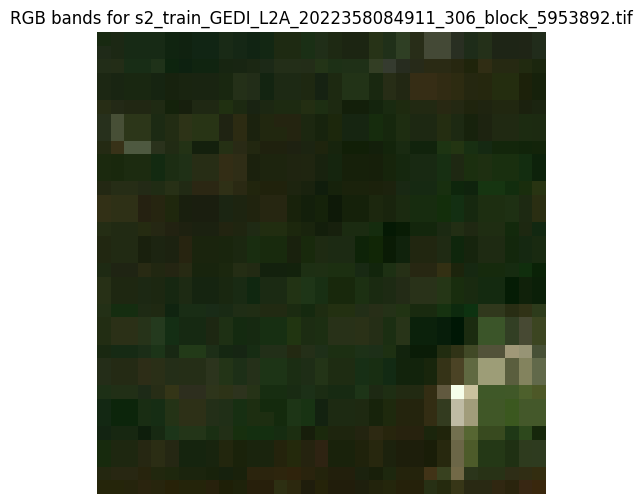

In [12]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

for fname in sample_files:
    fpath = os.path.join(RASTER_DIR, fname)

    print("\n" + "="*80)
    print("FILE:", fname)

    with rasterio.open(fpath) as src:
        width = src.width
        height = src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {transform.e*-1} (approx meters)")

        # Loop over bands for stats
        for b in range(1, count + 1):
            data = src.read(b)
            data = data.astype(float)  # ensure numeric

            # Mask nodata
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

            band_min = np.nanmin(data)
            band_max = np.nanmax(data)
            band_mean = np.nanmean(data)
            band_std = np.nanstd(data)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {band_min}")
            print(f"      max:  {band_max}")
            print(f"      mean: {band_mean}")
            print(f"      std:  {band_std}")

        # --- Visualization ---
        plt.figure(figsize=(6, 6))
        if count >= 3:
            # Read the first three bands for RGB visualization
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize for display (min-max)
            img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)
            plt.imshow(img)
            plt.title(f"RGB bands for {fname}")
        elif count == 1:
            # Read the single band for grayscale visualization
            img = src.read(1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Grayscale band for {fname}")
        else:
            print(f"Skipping visualization for {fname}: not enough bands for RGB or single band.")

        plt.axis('off')
        plt.show()

## Prep tifs: Pad, Normalize, inspect, save to content

In [13]:
from rasterio.enums import Resampling

def resize_to_max32(src):
    """
    Resize rasterio dataset to ensure h,w <= 32 while preserving aspect ratio.
    Returns: resized array (bands, new_h, new_w) and updated transform
    """
    h = src.height
    w = src.width
    bands = src.count

    # No resizing needed
    if h <= 32 and w <= 32:
        return src.read(), src.transform

    scale_h = 32 / h
    scale_w = 32 / w
    scale = min(scale_h, scale_w)

    new_h = max(1, int(h * scale))
    new_w = max(1, int(w * scale))

    resized = src.read(
        out_shape=(bands, new_h, new_w),
        resampling=Resampling.bilinear
    )

    # Update transform to match resized array
    new_transform = Affine(
        src.transform.a / scale, src.transform.b, src.transform.c,
        src.transform.d, src.transform.e / scale, src.transform.f
    )

    return resized, new_transform


# this block drops the spatial meta data updated above here on 11/25
# def resize_to_max32(src):
#     """
#     Resize rasterio dataset to ensure h,w <= 32 while preserving aspect ratio.
#     Returns a numpy array (bands, new_h, new_w).
#     """
#     h = src.height
#     w = src.width
#     bands = src.count

#     # No resizing needed
#     if h <= 32 and w <= 32:
#         return src.read()

#     scale_h = 32 / h
#     scale_w = 32 / w
#     scale = min(scale_h, scale_w)

#     new_h = max(1, int(h * scale))
#     new_w = max(1, int(w * scale))

#     resized = src.read(
#         out_shape=(bands, new_h, new_w),
#         resampling=Resampling.bilinear
#     )

#     return resized


In [14]:
import numpy as np

def pad_to_32x32(arr, transform):
    """Center-pad a raster to exactly (bands, 32, 32) and adjust transform."""
    bands, h, w = arr.shape
    padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

    h_start = (32 - h) // 2
    w_start = (32 - w) // 2

    padded[:, h_start:h_start+h, w_start:w_start+w] = arr

    # Adjust transform to account for padding
    new_transform = transform * Affine.translation(-w_start, -h_start)
    return padded, new_transform



# this block drops the spatial meta data updated above here on 11/25
# def pad_to_32x32(arr):
#     """Center-pad a raster to exactly (bands, 32, 32)."""
#     bands, h, w = arr.shape
#     padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

#     h_start = (32 - h) // 2
#     w_start = (32 - w) // 2

#     padded[:, h_start:h_start+h, w_start:w_start+w] = arr
#     return padded


In [15]:
def minmax_normalize(arr):
    arr = arr.astype(float)
    for b in range(arr.shape[0]):
        mn = np.nanmin(arr[b])
        mx = np.nanmax(arr[b])
        arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
    return arr


In [16]:
import rasterio
import numpy as np
import os

# -------------------------------------------------------------------------
# IMPROVED: Fill ALL NaNs with median (no dropping)
# -------------------------------------------------------------------------

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Scanning directory:", PROCESSED_DIR)

all_tifs = [
    f for f in os.listdir(PROCESSED_DIR)
    if f.lower().endswith((".tif", ".tiff"))
]

total_files = len(all_tifs)
corrected_files = 0

print(f"\nFound {total_files} TIFFs in {PROCESSED_DIR}\n")

selected_files = []

for fname in all_tifs:
    fpath = os.path.join(PROCESSED_DIR, fname)

    with rasterio.open(fpath) as src:
        bands = []
        needs_correction = False

        for b in range(1, src.count + 1):
            data = src.read(b).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

            nan_count = np.isnan(data).sum()

            if nan_count > 0:
                needs_correction = True

            bands.append(data)

    # Fix ALL files with NaNs (no dropping!)
    if needs_correction:
        corrected_files += 1
        print(f"FIXING: {fname} (median fill)")

        cleaned_bands = []
        for data in bands:
            if np.isnan(data).any():
                # Calculate median of non-NaN values
                med = np.nanmedian(data)
                # If entire band is NaN, use 0
                if np.isnan(med):
                    med = 0.0
                data = np.where(np.isnan(data), med, data)
            cleaned_bands.append(data)

        # Write cleaned TIFF back to disk
        with rasterio.open(fpath) as src:
            profile = src.profile

        with rasterio.open(fpath, "w", **profile) as dst:
            for i, band in enumerate(cleaned_bands, start=1):
                dst.write(band.astype(profile["dtype"]), i)

    # Keep ALL TIFFs for further processing
    selected_files.append(fname)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("TIFF QUALITY CHECK SUMMARY")
print(f"Total TIFFs scanned           : {total_files}")
print(f"TIFFs corrected (median fill) : {corrected_files}")
print(f"TIFFs dropped                 : 0")  # No more dropping!
print(f"TIFFs passed to processing    : {len(selected_files)}")
print("="*60 + "\n")

### nan criteria too strong

# import rasterio
# import numpy as np
# import os

# # -------------------------------------------------------------------------
# # 1. QUALITY CHECK: only scan TIFFs in PROCESSED_DIR
# # -------------------------------------------------------------------------

# PROCESSED_DIR = "/content/processed_32x32_normalized"
# os.makedirs(PROCESSED_DIR, exist_ok=True)

# print("Scanning directory:", PROCESSED_DIR)

# all_tifs = [
#     f for f in os.listdir(PROCESSED_DIR)
#     if f.lower().endswith((".tif", ".tiff"))
# ]

# total_files = len(all_tifs)
# corrected_files = 0
# dropped_files = 0

# print(f"\nFound {total_files} TIFFs in {PROCESSED_DIR}\n")

# selected_files = []   # <-- Files that pass checks
# dropped_list = []     # <-- Files to delete


# for fname in all_tifs:
#     fpath = os.path.join(PROCESSED_DIR, fname)

#     with rasterio.open(fpath) as src:
#         bands = []
#         needs_correction = False
#         too_many_nans = False

#         for b in range(1, src.count + 1):
#             data = src.read(b).astype(float)

#             if src.nodata is not None:
#                 data[data == src.nodata] = np.nan

#             nan_count = np.isnan(data).sum()

#             if nan_count > 0:
#                 needs_correction = True
#             if nan_count >= 100:
#                 too_many_nans = True

#             bands.append(data)

#     # Drop files with too many NaNs
#     if too_many_nans:
#         dropped_files += 1
#         dropped_list.append(fname)     # <--- NOW correctly recorded
#         print(f"DROPPED: {fname} (≥100 NaNs)")
#         continue

#     # Fix files that have ≤99 NaNs
#     if needs_correction:
#         corrected_files += 1
#         print(f"FIXING: {fname} (median fill)")

#         cleaned_bands = []
#         for data in bands:
#             if np.isnan(data).any():
#                 med = np.nanmedian(data)
#                 data = np.where(np.isnan(data), med, data)
#             cleaned_bands.append(data)

#         # Write cleaned TIFF back to disk
#         with rasterio.open(fpath) as src:
#             profile = src.profile

#         with rasterio.open(fpath, "w", **profile) as dst:
#             for i, band in enumerate(cleaned_bands, start=1):
#                 dst.write(band.astype(profile["dtype"]), i)

#     # Keep this TIFF for further processing
#     selected_files.append(fname)

# # -------------------------------------------------------------------------
# # SUMMARY
# # -------------------------------------------------------------------------
# print("\n" + "="*60)
# print("TIFF QUALITY CHECK SUMMARY")
# print(f"Total TIFFs scanned           : {total_files}")
# print(f"TIFFs corrected (median fill) : {corrected_files}")
# print(f"TIFFs dropped (≥100 NaNs)     : {dropped_files}")
# print(f"TIFFs passed to processing    : {len(selected_files)}")
# print("="*60 + "\n")

# print("Dropped files:", dropped_list)

# # -------------------------------------------------------------------------
# # DELETE DROPPED FILES
# # -------------------------------------------------------------------------
# print("\nDeleting dropped TIFF files...\n")

# for fname in dropped_list:
#     fpath = os.path.join(PROCESSED_DIR, fname)
#     if os.path.exists(fpath):
#         os.remove(fpath)
#         print("Deleted:", fname)

# print("\nFinished deleting dropped TIFFs.")
# print("Total deleted files:", len(dropped_list))


Scanning directory: /content/processed_32x32_normalized

Found 2861 TIFFs in /content/processed_32x32_normalized

FIXING: s2_test_GEDI_L2A_2021135083748_192_block_6033892.tif (median fill)
FIXING: hls_train_GEDI_L2A_2021135083748_109_block_5983896.tif (median fill)
FIXING: hls_train_GEDI_L2A_2022358084911_408_block_6023898.tif (median fill)
FIXING: s2_train_GEDI_L2A_2020196021509_431_block_5923896.tif (median fill)
FIXING: s2_train_GEDI_L2A_2021135083748_1180_block_6043889.tif (median fill)
FIXING: landsat_train_GEDI_L2A_2021135083748_1665_block_6033889.tif (median fill)
FIXING: tcap_train_GEDI_L2A_2020196021509_432_block_5923896.tif (median fill)
FIXING: dem_train_GEDI_L2A_2021135083748_1665_block_6033889.tif (median fill)
FIXING: landsat_train_GEDI_L2A_2022358084911_713_block_5923888.tif (median fill)
FIXING: landsat_test_GEDI_L2A_2022139064237_194_block_5923889.tif (median fill)
FIXING: hls_train_GEDI_L2A_2022358084911_888_block_6023898.tif (median fill)
FIXING: hls_test_GEDI_L2A_20

In [17]:
import rasterio
from rasterio.transform import Affine
from rasterio.enums import Resampling
import numpy as np
import os


processed_paths = {}

for fname in selected_files:
    src_path = os.path.join(PROCESSED_DIR, fname)
    out_path = os.path.join(PROCESSED_DIR, fname)   # overwrite or change if desired


    with rasterio.open(src_path) as src:
        # Step 1: Resize
        resized, transform_resized = resize_to_max32(src)

        # Step 2: Pad
        padded, transform_padded = pad_to_32x32(resized, transform_resized)

        # Step 3: Normalize
        normalized = minmax_normalize(padded)

        # Write raster
        profile = src.profile.copy()
        profile.update({
            "height": 32,
            "width": 32,
            "transform": transform_padded,
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(normalized.astype("float32"))

# this block drops the spatial meta data updated above here on 11/25
    # with rasterio.open(src_path) as src:

    #     # Step 1: Resize
    #     resized = resize_to_max32(src)

    #     # Step 2: Pad
    #     padded = pad_to_32x32(resized)

    #     # Step 3: Normalize
    #     normalized = minmax_normalize(padded)

    #     # Write raster
    #     profile = src.profile
    #     profile.update({
    #         "height": 32,
    #         "width": 32,
    #         "transform": rasterio.transform.from_origin(0, 0, 1, 1),
    #         "dtype": "float32"
    #     })

    #     with rasterio.open(out_path, "w", **profile) as dst:
    #         dst.write(normalized.astype("float32"))

    processed_paths[fname] = out_path

print("Processed", len(processed_paths), "TIFFs successfully.")


Processed 2861 TIFFs successfully.


## Compare before preprocessing

In [18]:
processed_sample_files = {}

for fname in sample_files:
    processed_path = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(processed_path):
        processed_sample_files[fname] = processed_path
    else:
        print(f"⚠️ WARNING: Processed version not found for {fname}")



PROCESSED FILE: tcap_train_GEDI_L2A_2020196021509_1368_block_5913894.tif
LOCATION: /content/processed_32x32_normalized/tcap_train_GEDI_L2A_2020196021509_1368_block_5913894.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.9375 x 30.9375 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.49348542859479494
      std:  0.1727440795516861

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3692502507296922
      std:  0.14952618912353266

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.49679545459366636
      std:  0.15358094134793357

  Band 4 statistics:
      min:  0.0
      max:  0.9999999403953552
      mean: 0.7317190138237493
      std:  0.09291033671717376

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.49989881810142833
      std:  0.15814794116120315

  Band 6 statistics:
      min:  0.0
      max:  0.9999999403953552
      mean: 0.5565174906369066
      std:  0.109653

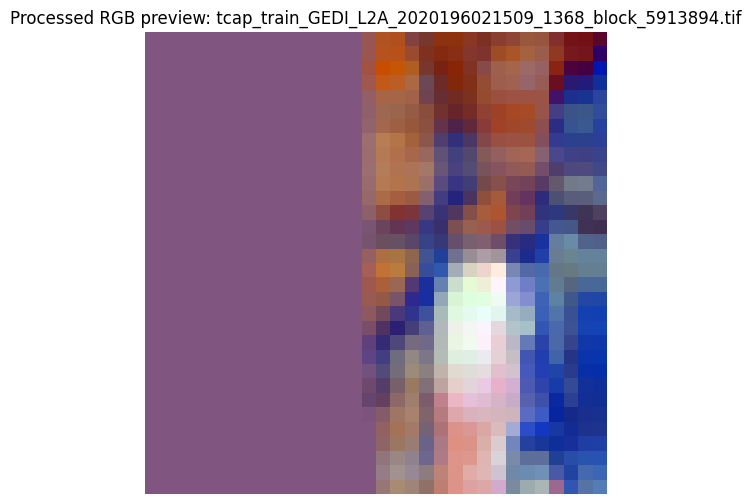


PROCESSED FILE: s2idx_train_GEDI_L2A_2020196021509_1446_block_5953897.tif
LOCATION: /content/processed_32x32_normalized/s2idx_train_GEDI_L2A_2020196021509_1446_block_5953897.tif
BANDS: 8
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 21.25 x 21.25 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.8192246467224322
      std:  0.15193132297443845

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.07218978931496167
      std:  0.16776001076987884

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7530302659142762
      std:  0.14533230289807406

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.09203139351757272
      std:  0.16881544792845068

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.8127882825792767
      std:  0.15246662399634947

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4616395705670584
      std:  0.11687175513774867

  Band 7 statistics

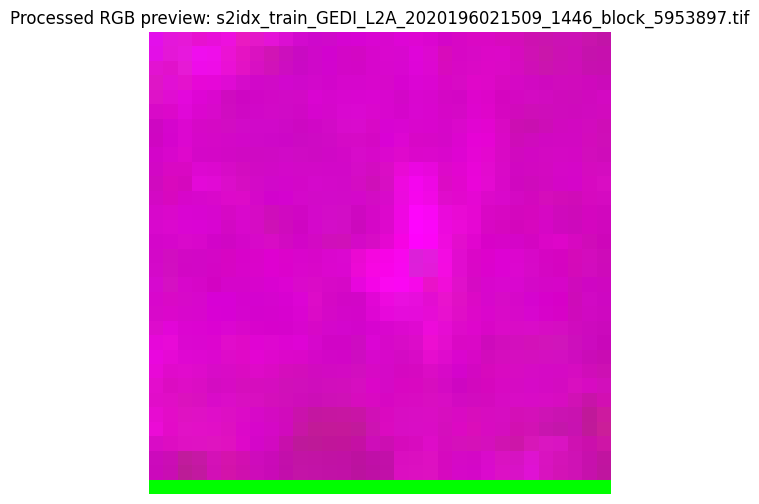


PROCESSED FILE: landsatidx_val_GEDI_L2A_2020196021509_444_block_5923897.tif
LOCATION: /content/processed_32x32_normalized/landsatidx_val_GEDI_L2A_2020196021509_444_block_5923897.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.9375 x 30.9375 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.49342094689200167
      std:  0.17461311877223362

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4848165973107825
      std:  0.16242865949532057

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.43924776801941334
      std:  0.1462787313410471

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.43241612864517265
      std:  0.19130454917617642

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.44177687252204123
      std:  0.16549381117993078

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.558223124140568
      std:  0.1654938105241956

  Band 7 sta

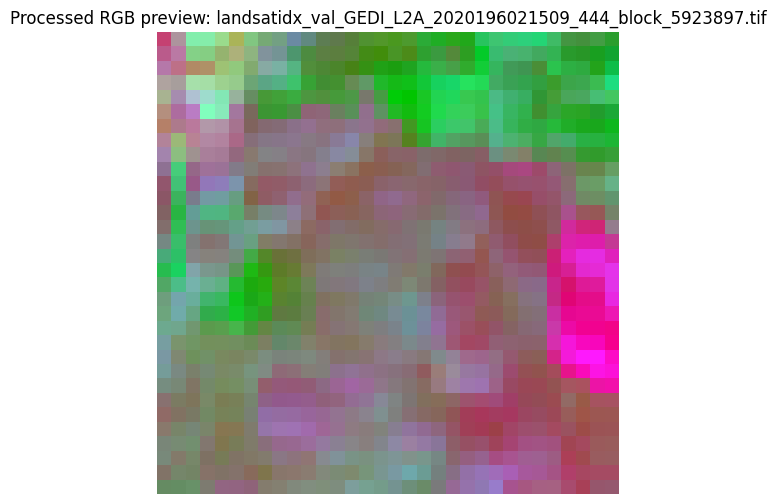


PROCESSED FILE: landsat_test_GEDI_L2A_2021135083748_1487_block_5933898.tif
LOCATION: /content/processed_32x32_normalized/landsat_test_GEDI_L2A_2021135083748_1487_block_5933898.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.9375 x 30.9375 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4894632037567135
      std:  0.22806780674124227

  Band 2 statistics:
      min:  0.0
      max:  0.9999999403953552
      mean: 0.4949581671453416
      std:  0.13853510275121383

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5402111025377963
      std:  0.18134947254786277

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6192172802166169
      std:  0.19801755207494523

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.525427238919292
      std:  0.18894395202612027

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.47614248384525126
      std:  0.23882954159824232


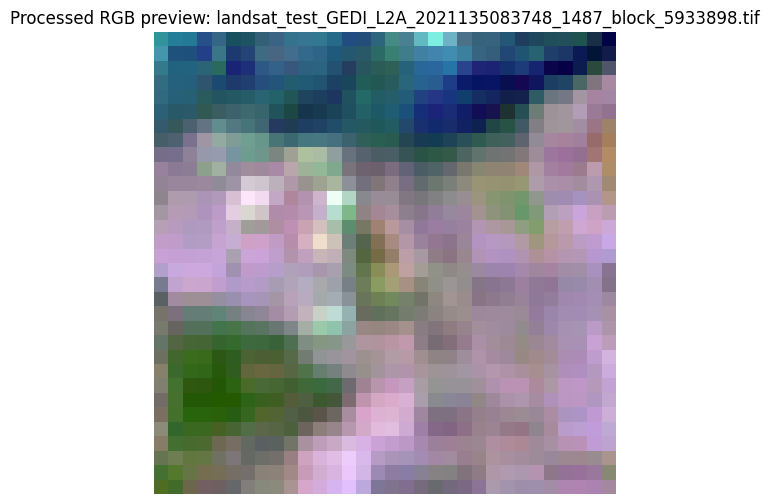


PROCESSED FILE: s2_train_GEDI_L2A_2022358084911_306_block_5953892.tif
LOCATION: /content/processed_32x32_normalized/s2_train_GEDI_L2A_2022358084911_306_block_5953892.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 21.25 x 21.25 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.29906455613672733
      std:  0.0954818103368312

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3527976378391031
      std:  0.09592537628150659

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.28423376790306065
      std:  0.08671838065292624

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7039576245879289
      std:  0.15322539532802787

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5742274221556727
      std:  0.12018263439275155

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.37686903128633276
      std:  0.09846316593590226


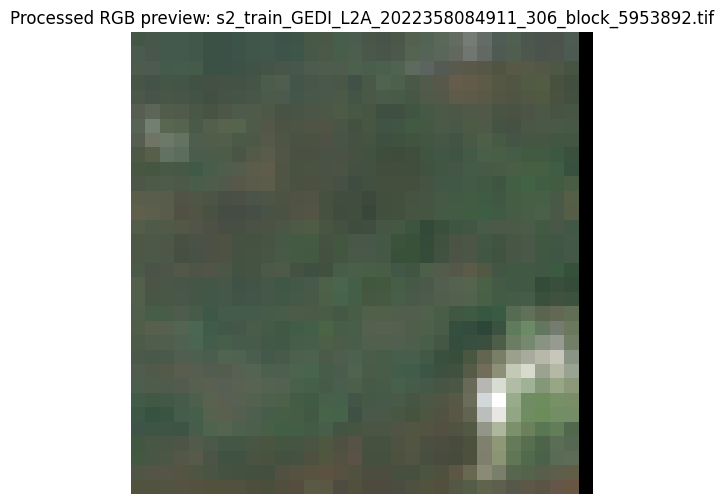

In [19]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for fname, fpath in processed_sample_files.items():

    print("\n" + "="*80)
    print("PROCESSED FILE:", fname)
    print("LOCATION:", fpath)

    with rasterio.open(fpath) as src:
        width, height = src.width, src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (arbitrary)")

        # ---- Band statistics ----
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            plt.imshow(img)
            plt.title(f"Processed RGB preview: {fname}")

        else:
            img = src.read(1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Processed grayscale preview: {fname}")

        plt.axis("off")
        plt.show()


## Target filter

In [20]:
import pandas as pd

GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# Load CSV
df = pd.read_csv(GEDI_CSV)

# Filter for product_field == "GEDI_LSA"
df_filtered_GEDI_L2A = df[df["product_field"] == "GEDI_L2A"]

df_filtered_GEDI_L2A


/tmp/ipython-input-686974334.py:6: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(GEDI_CSV)


,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,pavd_z_bin_9,stale_return_flag,pai_z_bin_4,x,y,block_x,block_y,block_id,row_ID,split
0,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214071,-85.989695,455.898773,470.743774,-18.850618,0.977285,0.0,1.0,...,NaN,NaN,NaN,591952.855432,3.897251e+06,591,3897,591_3897,1,train
1,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214767,-85.988777,459.104523,467.231506,-18.850683,0.990288,0.0,1.0,...,NaN,NaN,NaN,592035.619870,3.897329e+06,592,3897,592_3897,2,val
2,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215471,-85.987846,449.121246,455.059265,-18.850748,0.989432,0.0,1.0,...,NaN,NaN,NaN,592119.554656,3.897408e+06,592,3897,592_3897,3,val
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,NaN,NaN,NaN,592159.115617,3.897445e+06,592,3897,592_3897,4,val
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.216501,-85.986494,478.569794,489.838898,-18.850840,0.981278,0.0,1.0,...,NaN,NaN,NaN,592241.425190,3.897523e+06,592,3897,592_3897,5,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1863,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217155,-85.859947,549.746216,567.769958,-41.230606,0.977462,0.0,1.0,...,NaN,NaN,NaN,603758.425670,3.897721e+06,603,3897,603_3897,1864,train
1864,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217505,-85.859484,550.669312,566.905273,-41.230209,0.975680,0.0,1.0,...,NaN,NaN,NaN,603800.146408,3.897760e+06,603,3897,603_3897,1865,train
1865,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217854,-85.859021,549.173706,566.905273,-41.229813,0.978489,0.0,1.0,...,NaN,NaN,NaN,603841.799971,3.897799e+06,603,3897,603_3897,1866,train
1866,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,NaN,NaN,NaN,603925.187830,3.897878e+06,603,3897,603_3897,1867,train


### Pair Tif and GEDI Obs (Targets)

In [21]:
import re

FILENAME_RE = re.compile(
    r"^(?P<cov>[a-zA-Z0-9]+)_"          # covariate (s1, s2, landsatidx, etc)
    r"(?P<split>train|test|val)_"       # split
    r"GEDI_L2A_"                        # product field (constant)
    r"(?P<shot>\d+)_"                   # shot
    r"(?P<row_ID>\d+)_"                 # row_ID
    r"block_(?P<block_id>\d+)\.tif$"    # block_id
)


In [22]:
import os
import pandas as pd

TIFF_ROOT = "/content/processed_32x32_normalized"

rows = []

for fn in os.listdir(TIFF_ROOT):
    if not fn.endswith(".tif"):
        continue

    m = FILENAME_RE.match(fn)
    if m is None:
        print("WARNING: filename did not match pattern:", fn)
        continue

    d = m.groupdict()
    d["filename"] = fn
    d["full_path"] = os.path.join(TIFF_ROOT, fn)
    rows.append(d)

tif_df = pd.DataFrame(rows)
print("Parsed TIFFs:", len(tif_df))
print(tif_df.head())


Parsed TIFFs: 2861
          cov  split           shot row_ID block_id  \
0          s2   test  2021135083748    192  6033892   
1       s2idx  train  2022358084911   1205  5933888   
2       s2idx  train  2022358084911    800  5983894   
3          s1  train  2022139064237    700  5923888   
4  landsatidx  train  2020196021509    932  5923895   

                                            filename  \
0  s2_test_GEDI_L2A_2021135083748_192_block_60338...   
1  s2idx_train_GEDI_L2A_2022358084911_1205_block_...   
2  s2idx_train_GEDI_L2A_2022358084911_800_block_5...   
3  s1_train_GEDI_L2A_2022139064237_700_block_5923...   
4  landsatidx_train_GEDI_L2A_2020196021509_932_bl...   

                                           full_path  
0  /content/processed_32x32_normalized/s2_test_GE...  
1  /content/processed_32x32_normalized/s2idx_trai...  
2  /content/processed_32x32_normalized/s2idx_trai...  
3  /content/processed_32x32_normalized/s1_train_G...  
4  /content/processed_32x32_normalized

In [23]:
print("\nTIFF counts per covariate:")
print(tif_df["cov"].value_counts())



TIFF counts per covariate:
cov
s2idx         593
s2            555
landsatidx    294
landsat       294
dem           294
hls           294
tcap          294
s1            243
Name: count, dtype: int64


In [24]:
df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)
tif_df["row_ID"] = tif_df["row_ID"].astype(int)

merged = df_filtered_GEDI_L2A.merge(tif_df, on="row_ID", how="left")


/tmp/ipython-input-1886280410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)


In [25]:
valid = merged[~merged["filename"].isna()]
print("GEDI L2A rows:", len(df_filtered_GEDI_L2A))
print("Rows with matching TIFFs:", len(valid["row_ID"].unique()))


GEDI L2A rows: 1868
Rows with matching TIFFs: 703


In [26]:
df_valid = pd.DataFrame(valid)

In [27]:
df_valid

,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,block_y,block_id_x,row_ID,split_x,cov,split_y,shot,block_id_y,filename,full_path
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,tcap,val,2020196021509,5923897,tcap_val_GEDI_L2A_2020196021509_4_block_592389...,/content/processed_32x32_normalized/tcap_val_G...
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,landsat,val,2020196021509,5923897,landsat_val_GEDI_L2A_2020196021509_4_block_592...,/content/processed_32x32_normalized/landsat_va...
5,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,landsatidx,val,2020196021509,5923897,landsatidx_val_GEDI_L2A_2020196021509_4_block_...,/content/processed_32x32_normalized/landsatidx...
6,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,dem,val,2020196021509,5923897,dem_val_GEDI_L2A_2020196021509_4_block_5923897...,/content/processed_32x32_normalized/dem_val_GE...
7,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,hls,val,2020196021509,5923897,hls_val_GEDI_L2A_2020196021509_4_block_5923897...,/content/processed_32x32_normalized/hls_val_GE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4021,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,dem,train,2022358084911,6033897,dem_train_GEDI_L2A_2022358084911_1867_block_60...,/content/processed_32x32_normalized/dem_train_...
4022,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,hls,train,2022358084911,6033897,hls_train_GEDI_L2A_2022358084911_1867_block_60...,/content/processed_32x32_normalized/hls_train_...
4023,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,tcap,train,2022358084911,6033897,tcap_train_GEDI_L2A_2022358084911_1867_block_6...,/content/processed_32x32_normalized/tcap_train...
4024,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218904,-85.857633,547.420715,565.146973,-41.228622,0.972751,0.0,1.0,...,3897,603_3897,1868,train,s2idx,train,2022358084911,6033897,s2idx_train_GEDI_L2A_2022358084911_1868_block_...,/content/processed_32x32_normalized/s2idx_trai...


In [28]:
count_co = (df_valid['row_ID'] == 'cov').sum()
print(f"The number of entries matching 'cov' is: {count_co}")


The number of entries matching 'cov' is: 0


In [29]:
df_valid.to_csv('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/df_valid.csv', index=False)

In [30]:
column_names = valid.columns.tolist()
print(column_names)

['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_22', 'cover_z_bin_0', 'pgap_theta',

In [31]:
eo_list = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

print("\nCounts per EO by split:")
for eo in eo_list:
    eo_df = tif_df[tif_df["cov"] == eo]
    print(f"\nEO = {eo}")
    print(eo_df["split"].value_counts())



Counts per EO by split:

EO = s1
split
train    169
test      50
val       24
Name: count, dtype: int64

EO = s2
split
train    403
test     101
val       51
Name: count, dtype: int64

EO = landsat
split
train    219
test      50
val       25
Name: count, dtype: int64

EO = landsatidx
split
train    219
test      50
val       25
Name: count, dtype: int64

EO = hls
split
train    219
test      50
val       25
Name: count, dtype: int64

EO = tcap
split
train    219
test      50
val       25
Name: count, dtype: int64

EO = dem
split
train    219
test      50
val       25
Name: count, dtype: int64

EO = s2idx
split
train    438
test     100
val       55
Name: count, dtype: int64


## Data loaders

In [32]:
EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
SPATIAL_RES = {
    's1': 10, 's2': 20, 's2idx': 20,
    'landsat': 30, 'landsatidx': 30,
    'hls': 30, 'tcap': 30, 'dem': 30
}
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import random


# -----------------------
# Remove NaN samples
# -----------------------
def drop_nan_samples(df):
    clean_rows = []
    dropped = 0

    for i, row in df.iterrows():
        fp = row["full_path"]
        try:
            with rasterio.open(fp) as src:
                arr = src.read().astype(np.float32)
                if np.isnan(arr).any():
                    dropped += 1
                    continue
        except:
            dropped += 1
            continue

        clean_rows.append(row)

    clean_df = pd.DataFrame(clean_rows).reset_index(drop=True)
    print(f"\n[CLEAN] Removed {dropped} NaN samples. Remaining: {len(clean_df)}")
    return clean_df

# -----------------------
# Dataset for a single EO
# -----------------------
class GeoTiffDataset(Dataset):
    def __init__(self, df, eo, bands_per_cov, target_col='rh', transform=None, augment=False, split='train'):
        """
        Single-EO Dataset for multibranch model.
        df: pandas DataFrame
        eo: EO type (string, must match 'cov' column)
        bands_per_cov: dict mapping EO type to number of bands
        target_col: target column name
        transform: optional transform
        augment: whether to apply flips and rotations
        split: data partition ('train', 'val', 'test')
        """
        # Filter rows by EO and split
        self.df = df[(df['cov'] == eo) & (df['split_x'] == split)].reset_index(drop=True)
        self.eo = eo
        self.bands = bands_per_cov[eo]
        self.target_col = target_col
        self.transform = transform
        self.augment = augment

        if len(self.df) == 0:
            print(f"[WARNING] Dataset for EO '{eo}' and split '{split}' initialized with 0 samples!")
        else:
            print(f"[INFO] Dataset for EO '{eo}' and split '{split}' initialized with {len(self.df)} samples")
        print(f"[INFO] Target column: {self.target_col}")
        print(f"[INFO] Augmentation enabled: {self.augment}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row['full_path']

        with rasterio.open(fp) as src:
            arr = src.read().astype(np.float32)  # (C, H, W)

        # Verify band count
        if arr.shape[0] != self.bands:
            raise ValueError(f"EO {self.eo} at idx {idx} has {arr.shape[0]} bands, expected {self.bands}")

        # Augmentation: flips and rotations
        if self.augment:
            if random.random() > 0.5:  # horizontal flip
                arr = arr[:, :, ::-1].copy()
            if random.random() > 0.5:  # vertical flip
                arr = arr[:, ::-1, :].copy()
            k = random.randint(0, 3)
            arr = np.rot90(arr, k, axes=(1, 2)).copy()

        if self.transform:
            arr = self.transform(arr)

        x = torch.tensor(arr, dtype=torch.float32)
        y = torch.tensor(row[self.target_col], dtype=torch.float32)

        # return x, y
        return {
        "image": x,      #
        "target": y,     #
        "path": fp       # 11/20 !!!! NEW — adds full file path for embedding fusion
    }

# -----------------------
# Function to create loaders per EO and split
# -----------------------
def create_multibranch_loaders(df, eo_list, bands_per_cov, target_col='rh', batch_size=16, augment=False, split='train'):
    """
    Create a dictionary of DataLoaders per EO.
    Returns: dict {eo: DataLoader}
    """
    loaders = {}
    for eo in eo_list:
        dataset = GeoTiffDataset(df, eo, bands_per_cov, target_col=target_col, augment=augment, split=split)
        if len(dataset) == 0:
            print(f"[WARNING] Skipping EO '{eo}' because dataset is empty for split '{split}'")
            continue
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=(split=='train'), num_workers=2)
        loaders[eo] = loader
        print(f"[INFO] DataLoader for EO '{eo}' created with {len(loader)} batches, batch size {batch_size}")
    return loaders

# -----------------------
# Example usage: create loaders for all EO branches for 'train' split
# -----------------------
EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

train_loaders = create_multibranch_loaders(valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=True, split='train')

# # -----------------------
# # Inspect first batch per EO
# # -----------------------
# for eo, loader in train_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)

#     # -----------------------
# Inspect first batch per EO
# -----------------------
for eo, loader in train_loaders.items():

    batch = next(iter(loader))     # 11/20 fix ⭐ one dict now, not two tensors

    print(f"\n[INFO] EO branch: {eo}")
    print(f"  Image batch shape:  {batch['image'].shape}")   # (B, C, H, W)
    print(f"  Target batch shape: {batch['target'].shape}")  # (B,)
    print(f"  Example path:       {batch['path'][0]}")        # first file path



[INFO] Dataset for EO 's1' and split 'train' initialized with 169 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's1' created with 11 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'train' initialized with 403 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's2' created with 26 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'train' initialized with 219 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsat' created with 14 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'train' initialized with 219 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsatidx' created with 14 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'train' initialized with 219 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'hls' c

In [34]:
# -----------------------
# Test loaders without augmentation
# -----------------------
test_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='test'
)

# -----------------------
# Inspect first batch per EO for TEST
# -----------------------
print("\n==================== TEST LOADERS ====================")
# for eo, loader in test_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] Split: TEST | EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)
##11/20 fix
for eo, loader in test_loaders.items():
    batch = next(iter(loader))             # <-- CHANGED: now batch is a dict
    imgs   = batch["image"]                # <-- CHANGED
    tgts   = batch["target"]               # <-- CHANGED
    paths  = batch["path"]                 # <-- CHANGED: list of file paths

    print(f"\n[INFO] Split: TEST | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")     # (B, C, H, W)
    print(f"  Target batch shape: {tgts.shape}")     # (B,)
    print(f"  Example path:       {paths[0]}")       # path string



# -----------------------
# Validation loaders without augmentation
# -----------------------
val_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='val'
)

# -----------------------
# Inspect first batch per EO for VAL
# -----------------------
# print("\n==================== VAL LOADERS ====================")
# for eo, loader in val_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] Split: VAL | EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)'

#11/20 fix
print("\n==================== VAL LOADERS ====================")

for eo, loader in val_loaders.items():
    batch = next(iter(loader))             # <-- CHANGED
    imgs   = batch["image"]                # <-- CHANGED
    tgts   = batch["target"]               # <-- CHANGED
    paths  = batch["path"]                 # <-- CHANGED

    print(f"\n[INFO] Split: VAL | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")
    print(f"  Target batch shape: {tgts.shape}")
    print(f"  Example path:       {paths[0]}")


[INFO] Dataset for EO 's1' and split 'test' initialized with 50 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's1' created with 4 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'test' initialized with 101 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's2' created with 7 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'test' initialized with 50 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsat' created with 4 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'test' initialized with 50 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsatidx' created with 4 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'test' initialized with 50 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'hls' created w

### check for NAN

In [35]:
# -----------------------
# Check datasets + loaders for NaN values
# -----------------------

def check_nans_in_dataset(df, eo_list):
    print("\n========== DATASET NaN CHECK ==========")
    import rasterio
    import numpy as np

    for eo in eo_list:
        subdf = df[df["cov"] == eo]
        if len(subdf) == 0:
            print(f"[INFO] EO '{eo}' has no rows in dataframe.")
            continue

        nan_files = []
        for _, row in subdf.iterrows():
            fp = row["full_path"]
            try:
                with rasterio.open(fp) as src:
                    arr = src.read().astype(np.float32)
                    if np.isnan(arr).any():
                        nan_files.append(fp)
            except Exception as e:
                print(f"[ERROR] Could not read {fp}: {e}")

        if len(nan_files) > 0:
            print(f"[WARNING] EO '{eo}' has {len(nan_files)} files containing NaN.")
            for f in nan_files[:5]:  # show first 5
                print("    ", f)
        else:
            print(f"[OK] EO '{eo}' has no NaN values in any raster.")

##11/20 ddrsssing dictdictionary  to three elemtns
def check_nans_in_loaders(loaders):
    print("\n========== LOADER NaN CHECK ==========")
    import torch

    for eo, loader in loaders.items():
        try:
            batch = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        # Handle dict batches
        if isinstance(batch, dict):
            batch_x = batch.get("image")
            batch_y = batch.get("target")
        else:
            # fallback for tuple/list batches
            batch_x, batch_y = batch

        x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
        y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

        if x_nan or y_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in inputs: {x_nan}")
            print(f"   NaN in targets: {y_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs.")


##11/17
# def check_nans_in_loaders(loaders):
#     print("\n========== LOADER NaN CHECK ==========")
#     import torch

#     for eo, loader in loaders.items():
#         try:
#             batch_x, batch_y = next(iter(loader))
#         except StopIteration:
#             print(f"[WARNING] EO '{eo}' loader is empty.")
#             continue

#         x_nan = torch.isnan(batch_x).any().item()
#         y_nan = torch.isnan(batch_y).any().item()

#         if x_nan or y_nan:
#             print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
#             print(f"   NaN in inputs: {x_nan}")
#             print(f"   NaN in targets: {y_nan}")
#         else:
#             print(f"[OK] EO '{eo}' first batch has no NaNs.")

# ---------- RUN CHECKS ----------
check_nans_in_dataset(valid, EO_LIST)
check_nans_in_loaders(train_loaders)



========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.


In [36]:
###11/20 addressing dictionary to return three elements
# -----------------------
# Run NaN checks across all splits
# -----------------------
splits = ['train', 'val', 'test']
loaders_dict = {
    'train': train_loaders,
    'val': val_loaders,
    'test': test_loaders
}

for split in splits:
    print(f"\n==================== NaN CHECK: {split.upper()} ====================")

    # Check dataset
    check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

    # Check loaders
    print("\n========== LOADER NaN CHECK ==========")
    import torch

    for eo, loader in loaders_dict[split].items():
        try:
            batch = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        # Handle dict batches
        if isinstance(batch, dict):
            batch_x = batch.get("image")
            batch_y = batch.get("target")
        else:
            # fallback for tuple/list batches
            batch_x, batch_y = batch

        x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
        y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

        if x_nan or y_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in inputs: {x_nan}")
            print(f"   NaN in targets: {y_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs.")



#11/17
# # -----------------------
# # Run NaN checks across all splits
# # -----------------------
# splits = ['train', 'val', 'test']
# loaders_dict = {
#     'train': train_loaders,
#     'val': val_loaders,
#     'test': test_loaders
# }

# for split in splits:
#     print(f"\n==================== NaN CHECK: {split.upper()} ====================")

#     # Check dataset
#     check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

#     # Check loaders
#     check_nans_in_loaders(loaders_dict[split])



==================== NaN CHECK: TRAIN ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.

==================== NaN CHECK: VAL ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[O

## GEDI L1B Autoendcoder and dataset and loader construction

In [37]:
import numpy as np

file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'

# Load with allow_pickle=True
arr = np.load(file_path, allow_pickle=True)

# Check if any NaN exists
# For object arrays, np.isnan might not work directly, so use a comprehension
has_nan = any(np.isnan(x) if isinstance(x, (int, float, np.number)) else False for x in arr.flatten())

print("Any NaN values?", has_nan)

# Count NaNs
num_nan = sum(1 for x in arr.flatten() if isinstance(x, (int, float, np.number)) and np.isnan(x))
print("Number of NaN values:", num_nan)


Any NaN values? False
Number of NaN values: 0


In [38]:
# import numpy as np
# import torch
# from torch.utils.data import Dataset

# # 1️ Load the .npy file
# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
# data = np.load(file_path, allow_pickle=True).item()  # actual_data = data.item()

# # 2️ Inspect keys if it’s a dict
# print("Keys in the .npy object:", list(data.keys()))

# # Assuming the waveform data is under the key 'rxwaveform' (adjust if different)
# waveforms = data['rxwaveform']  # should be a list or array of arrays

# # 3️ Define a PyTorch Dataset
# class RxWaveformDataset(Dataset):
#     def __init__(self, waveforms, transform=None, fixed_length=None):
#         self.transform = transform
#         self.fixed_length = fixed_length
#         self.data = []

#         for wf in waveforms:
#             arr = np.array(wf, dtype=np.float32)

#             # Pad or truncate to fixed length if specified
#             if fixed_length is not None:
#                 if len(arr) < fixed_length:
#                     arr = np.pad(arr, (0, fixed_length - len(arr)), mode='constant')
#                 else:
#                     arr = arr[:fixed_length]

#             self.data.append(arr)

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         waveform = self.data[idx]
#         if self.transform:
#             waveform = self.transform(waveform)
#         return torch.tensor(waveform, dtype=torch.float32)

# # 4️⃣ Create the dataset
# dataset_rx = RxWaveformDataset(waveforms, fixed_length=1024)  # adjust fixed_length if needed
# print("Number of waveforms:", len(dataset_rx))
# print("Shape of first waveform:", dataset_rx[0].shape)


In [39]:

# ### 11/17 works great commented out so that i cna add a indexing for emdedding index later
# import numpy as np
# import torch
# from torch.utils.data import Dataset, DataLoader

# # 1️ Load the .npy file
# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
# data = np.load(file_path, allow_pickle=True).item()

# # 2️ Inspect keys
# print("Keys in the .npy object:", list(data.keys()))

# # Assuming waveform data is under 'rxwaveform'
# waveforms = data['rxwaveform']

# # 3️ Define PyTorch Dataset
# class RxWaveformDataset(Dataset):
#     def __init__(self, waveforms, transform=None, fixed_length=None):
#         self.transform = transform
#         self.fixed_length = fixed_length
#         self.data = []

#         for wf in waveforms:
#             arr = np.array(wf, dtype=np.float32)

#             # Pad or truncate to fixed length
#             if fixed_length is not None:
#                 if len(arr) < fixed_length:
#                     arr = np.pad(arr, (0, fixed_length - len(arr)), mode='constant')
#                 else:
#                     arr = arr[:fixed_length]

#             # Add channel dimension for CNN: (1, length)
#             arr = np.expand_dims(arr, axis=0)
#             self.data.append(arr)

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         waveform = self.data[idx]
#         if self.transform:
#             waveform = self.transform(waveform)
#         return torch.tensor(waveform, dtype=torch.float32)

# # 4️ Create the dataset
# fixed_length = 1024
# dataset_rx = RxWaveformDataset(waveforms, fixed_length=fixed_length)
# print("Number of waveforms:", len(dataset_rx))
# print("Shape of first waveform:", dataset_rx[0].shape)  # should be (1, fixed_length)

# # 5️ Create a DataLoader
# batch_size = 8
# loader_rx = DataLoader(dataset_rx, batch_size=batch_size, shuffle=True)

# # Check batch shapes
# # for batch in loader:
# #     print("Batch shape:", batch.shape)  # should be (batch_size, 1, fixed_length)
# #     break


In [40]:

### 11/20 added df_wave to keep track of position
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ---------------------------
# 1️⃣ Load the .npy file
# ---------------------------
file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
data = np.load(file_path, allow_pickle=True).item()

waveforms = data['rxwaveform']
num_samples = len(waveforms)

# Optional: extract targets or metadata if needed
# Example: we’ll just create dummy targets for now
# Replace 'targets' with your actual supervised target array
targets = np.zeros(num_samples, dtype=np.float32)

# ---------------------------
# 2️⃣ Build reference table
# ---------------------------
import pandas as pd

df_wave = pd.DataFrame({
    "sample_idx": np.arange(num_samples),  # acts as “file path” stand-in
    "target": targets
    # Add other metadata if desired, e.g., latitude_bin0, longitude_bin0, shot_number
})

# ---------------------------
# 3️⃣ Define PyTorch Dataset
# ---------------------------
class RxWaveformDataset(Dataset):
    def __init__(self, df, waveforms, fixed_length=1024, transform=None):
        self.df = df
        self.waveforms = waveforms
        self.fixed_length = fixed_length
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        wf = np.array(self.waveforms[idx], dtype=np.float32)

        # Pad or truncate
        if len(wf) < self.fixed_length:
            wf = np.pad(wf, (0, self.fixed_length - len(wf)), mode='constant')
        else:
            wf = wf[:self.fixed_length]

        # Add channel dimension for CNN: (1, length)
        wf = np.expand_dims(wf, axis=0)

        if self.transform:
            wf = self.transform(wf)

        x = torch.tensor(wf, dtype=torch.float32)
        y = torch.tensor(self.df.iloc[idx]["target"], dtype=torch.float32)
        ref = self.df.iloc[idx]["sample_idx"]  # acts like 'path'

        return {
            "image": x,     # waveform tensor
            "target": y,    # supervised label
            "path": ref     # unique sample index
        }

# ---------------------------
# 4️⃣ Create Dataset + DataLoader
# ---------------------------
fixed_length = 1024
dataset_rx = RxWaveformDataset(df_wave, waveforms, fixed_length=fixed_length)

batch_size = 8
loader_rx = DataLoader(dataset_rx, batch_size=batch_size, shuffle=True)

# ---------------------------
# 5️⃣ Verify
# ---------------------------
batch = next(iter(loader_rx))
print("Batch 'image' shape:", batch["image"].shape)   # (B, 1, 1024)
print("Batch 'target' shape:", batch["target"].shape) # (B,)
print("Batch 'path':", batch["path"])                 # sample indices


Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'path': tensor([3232., 3281.,  455.,  876., 2022.,  369., 3265., 1520.],
       dtype=torch.float64)


In [41]:
#11.17 dropped for indexing

# # Assuming you already have your DataLoader
# loader_rx = DataLoader(dataset_rx, batch_size=8, shuffle=True)

# # Inspect a single batch
# for i, batch in enumerate(loader_rx):
#     print(f"Batch {i} type: {type(batch)}")
#     print(f"Batch {i} shape: {batch.shape}")  # should be (batch_size, 1, fixed_length)
#     print(f"Batch {i} dtype: {batch.dtype}")
#     print(f"Batch {i} first waveform sample:\n{batch[0]}")
#     break  # just show the first batch


In [42]:
#11/20 added for indexing embedding
# Assuming you already have your DataLoader
loader_rx = DataLoader(dataset_rx, batch_size=8, shuffle=True)

# Inspect a single batch
for i, batch in enumerate(loader_rx):
    print(f"Batch {i} type: {type(batch)}")  # should be <class 'dict'>

    # Shapes
    print(f"Batch 'image' shape: {batch['image'].shape}")   # (batch_size, 1, fixed_length)
    print(f"Batch 'target' shape: {batch['target'].shape}") # (batch_size,)

    # Data types
    print(f"Batch 'image' dtype: {batch['image'].dtype}")
    print(f"Batch 'target' dtype: {batch['target'].dtype}")

    # Example first waveform
    print(f"Batch 'image' first waveform sample:\n{batch['image'][0]}")

    # Path/sample_idx
    print(f"Batch 'path' (sample indices): {batch['path']}")

    break  # just show the first batch


Batch 0 type: <class 'dict'>
Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'image' dtype: torch.float32
Batch 'target' dtype: torch.float32
Batch 'image' first waveform sample:
tensor([[224.3143, 224.2509, 223.9523,  ...,   0.0000,   0.0000,   0.0000]])
Batch 'path' (sample indices): tensor([3369., 2293., 1762.,   53., 2001., 2366., 1134., 3518.],
       dtype=torch.float64)


# Stage 1 Modeling

## EO only

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PatchEmbed(nn.Module):
    """Converts image to patch embeddings."""
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, num_patches, embed_dim]
        x = self.proj(x)  # [B, embed_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [seq_len, B, embed_dim] for nn.MultiheadAttention
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTCustom(nn.Module):
    def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        # transformer expects [seq_len, B, embed_dim]
        x = x.transpose(0,1)
        for blk in self.blocks:
            x = blk(x)
        x = x.transpose(0,1)
        x = self.norm(x)
        # return x[:,0]  # return cls token embedding 11/21 version

        #change 11/25/25 to support token sequecne (per patch embedding rather that a single value at the pathc level)
        return x[:, 1:]  # shape: [B, num_patches, embed_dim]


In [44]:
# def train_vit_branch(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")
#     return model


In [45]:
# import matplotlib.pyplot as plt

# def train_vit_branch_with_plot(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     epoch_losses = []  # store average loss per epoch

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_loss = total_loss / len(loader)
#         epoch_losses.append(avg_loss)
#         print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

#     # Plot the loss curve
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), epoch_losses, marker='o')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training Loss Curve")
#     plt.grid(True)
#     plt.show()

#     return model


In [46]:
#11/25

class ViTRegressor(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)   # pools tokens → 1 vector
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x: [B, N_tokens, embed_dim]
        x = x.transpose(1, 2)                 # [B, embed_dim, N_tokens]
        x = self.pool(x).squeeze(-1)          # [B, embed_dim]
        return self.fc(x).squeeze(1)          # [B]


In [47]:
#11/25
def train_vit_with_test_loss(model, head, train_loader, test_loader,
                             epochs=10, lr=1e-4, device='cuda'):

    model = model.to(device)
    head  = head.to(device)

    # one optimizer for encoder + head
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(head.parameters()),
        lr=lr
    )
    criterion = nn.MSELoss()

    for epoch in range(epochs):

        # ------------------------
        # TRAIN
        # ------------------------
        model.train()
        head.train()
        running_loss = 0

        for batch in train_loader:
            x = batch["image"].to(device)
            y = batch["target"].to(device).float()

            optimizer.zero_grad()

            # ViT → token sequence
            emb = model(x)             # [B, 1024, 128]

            # Head pools tokens → predicts RH
            pred = head(emb)           # [B]

            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # ------------------------
        # TEST
        # ------------------------
        model.eval()
        head.eval()
        test_loss = 0

        with torch.no_grad():
            for batch in test_loader:
                x = batch["image"].to(device)
                y = batch["target"].to(device).float()

                emb = model(x)
                pred = head(emb)

                loss = criterion(pred, y)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={avg_train_loss:.4f}  Test={avg_test_loss:.4f}")

    return model, head


In [48]:
# #11/20 version
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn

# def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):
#     model = model.to(device)

#     # -------------------------------------------------------------
#     # 1) Build regression head ONCE using known embedding dimension
#     # -------------------------------------------------------------
#     batch = next(iter(train_loader))           # FIXED: dataset returns dict
#     example_x = batch["image"].to(device)      # FIXED
#     with torch.no_grad():
#         example_emb = model(example_x)
#     emb_dim = example_emb.shape[1]

#     head = nn.Linear(emb_dim, 1).to(device)

#     # -------------------------------------------------------------
#     # 2) One optimizer for BOTH encoder + head
#     # -------------------------------------------------------------
#     optimizer = torch.optim.Adam(
#         list(model.parameters()) + list(head.parameters()),
#         lr=lr
#     )
#     criterion = nn.MSELoss()

#     train_losses = []
#     test_losses = []

#     for epoch in range(epochs):
#         # ---------------------
#         # Training
#         # ---------------------
#         model.train()
#         head.train()
#         total_loss = 0

#         for batch in train_loader:                    # FIXED: dict
#             x = batch["image"].to(device)
#             y = batch["target"].to(device).float()

#             optimizer.zero_grad()
#             emb = model(x)
#             pred = head(emb)

#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()

#         avg_train_loss = total_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         # ---------------------
#         # Test Evaluation
#         # ---------------------
#         model.eval()
#         head.eval()
#         total_test_loss = 0

#         with torch.no_grad():
#             for batch in test_loader:                 # FIXED: dict
#                 x_test = batch["image"].to(device)
#                 y_test = batch["target"].to(device).float()

#                 emb_test = model(x_test)
#                 pred_test = head(emb_test)

#                 loss_test = criterion(pred_test.squeeze(), y_test)
#                 total_test_loss += loss_test.item()

#         avg_test_loss = total_test_loss / len(test_loader)
#         print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
#         test_losses.append(avg_test_loss)

#     # ---------------------
#     # Plot training & test loss
#     # ---------------------
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
#     plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training & Test Loss Curve")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     # Return BOTH the encoder and the trained regression head
#     return model, head






# #11/18 approach version work with no dicitonary dataeset loader (fill path additon )
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn

# def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):

#     model = model.to(device)

#     # -------------------------------------------------------------
#     # 1) Build regression head ONCE using known embedding dimension
#     # -------------------------------------------------------------
#     # get one batch to infer embedding dimension
#     example_x, _ = next(iter(train_loader))
#     example_x = example_x.to(device)
#     with torch.no_grad():
#         example_emb = model(example_x)
#     emb_dim = example_emb.shape[1]

#     head = nn.Linear(emb_dim, 1).to(device)

#     # -------------------------------------------------------------
#     # 2) One optimizer for BOTH encoder + head
#     # -------------------------------------------------------------
#     optimizer = torch.optim.Adam(
#         list(model.parameters()) + list(head.parameters()),
#         lr=lr
#     )
#     criterion = nn.MSELoss()

#     train_losses = []
#     test_losses = []

#     for epoch in range(epochs):

#         # ---------------------
#         # Training
#         # ---------------------
#         model.train()
#         head.train()
#         total_loss = 0

#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device).float()

#             optimizer.zero_grad()

#             emb = model(x)          # ViT embedding
#             pred = head(emb)        # persistent head

#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()

#         avg_train_loss = total_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         # ---------------------
#         # Test Evaluation
#         # ---------------------
#         model.eval()
#         head.eval()
#         total_test_loss = 0

#         with torch.no_grad():
#             for x_test, y_test in test_loader:
#                 x_test, y_test = x_test.to(device), y_test.to(device).float()

#                 emb_test = model(x_test)
#                 pred_test = head(emb_test)

#                 loss_test = criterion(pred_test.squeeze(), y_test)
#                 total_test_loss += loss_test.item()

#         avg_test_loss = total_test_loss / len(test_loader)
#         test_losses.append(avg_test_loss)

#         print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

#     # ---------------------
#     # Plot training & test loss
#     # ---------------------
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
#     plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training & Test Loss Curve")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     # Return BOTH the encoder and the trained regression head
#     return model, head



#11/17 approach
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn

# def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()

#     train_losses = []
#     test_losses = []

#     for epoch in range(epochs):
#         # ---------------------
#         # Training
#         # ---------------------
#         model.train()
#         total_loss = 0
#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # linear head
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_train_loss = total_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         # ---------------------
#         # Test loss (no grad)
#         # ---------------------
#         model.eval()
#         test_loss_total = 0
#         with torch.no_grad():
#             for x_test, y_test in test_loader:
#                 x_test, y_test = x_test.to(device), y_test.to(device).float()
#                 emb_test = model(x_test)
#                 pred_test = nn.Linear(emb_test.shape[1], 1).to(device)(emb_test)
#                 loss_test = criterion(pred_test.squeeze(), y_test)
#                 test_loss_total += loss_test.item()
#         avg_test_loss = test_loss_total / len(test_loader)
#         test_losses.append(avg_test_loss)

#         print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

#     # ---------------------
#     # Plot training & test loss
#     # ---------------------
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
#     plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training & Test Loss Curve")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     return model


In [49]:
def extract_embeddings(model, loader, device='cuda'):
    model.eval()
    embeddings_list = []
    targets_list = []
    paths_list = []

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            y = batch["target"].to(device).float()
            paths = batch["path"]

            emb = model(x)                     # [B, N_tokens, embed_dim]
            embeddings_list.append(emb.cpu())
            targets_list.append(y.cpu())
            paths_list.extend(paths)

    emb = torch.cat(embeddings_list, dim=0)
    tgt = torch.cat(targets_list, dim=0)

    return emb, tgt, paths_list



# #11/21 verison
# def extract_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embeddings_list = []
#     targets_list = []
#     paths_list = []  # store full file paths

#     with torch.no_grad():
#         for batch in loader:
#             x = batch["image"].to(device)
#             y = batch["target"].to(device).float()
#             paths = batch["path"]

#             emb = model(x)
#             embeddings_list.append(emb.cpu())
#             targets_list.append(y.cpu())
#             paths_list.extend(paths)  # keep paths aligned with embeddings

#     return torch.cat(embeddings_list, dim=0), torch.cat(targets_list, dim=0), paths_list




#11/17 version work with no dicitonary dataeset loader (fill path additon )
# def extract_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embeddings_list = []
#     targets_list = []
#     with torch.no_grad():
#         for x, y in loader:
#             x = x.to(device)
#             emb = model(x)
#             embeddings_list.append(emb.cpu())
#             targets_list.append(y)
#     embeddings = torch.cat(embeddings_list, dim=0)
#     targets = torch.cat(targets_list, dim=0)
#     return embeddings, targets


In [50]:
# import umap
# import matplotlib.pyplot as plt

# def visualize_umap(embeddings, targets, title="UMAP Projection"):
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
#     emb_2d = reducer.fit_transform(embeddings.numpy())
#     plt.figure(figsize=(8,6))
#     scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=targets.numpy(), cmap='Spectral', s=10)
#     plt.colorbar(scatter)
#     plt.title(title)
#     plt.show()


In [51]:
import torch
from torchinfo import summary

# Example: let's assume we want to show summary for the 's1' branch
in_channels = 4  # s1 images have 4 channels
img_size = 32

# ---- Instantiate your model ----
model = ViTCustom(
    in_channels=in_channels,  # <-- match your EO branch
    img_size=img_size,
    patch_size=4,
    embed_dim=128,
    depth=4,
    num_heads=4
)

# ---- Move to device ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# ---- dummy input matching EO branch ----
dummy_input = torch.randn(1, in_channels, img_size, img_size).to(device)

# ---- Print Model Summary ----
print(summary(
    model,
    input_data=dummy_input,
    depth=6,          # how deep to expand summary
    col_width=18,
    col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
))


Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Kernel Shape       Mult-Adds
ViTCustom                                [1, 4, 32, 32]     [1, 64, 128]       8,448              --                 --
├─PatchEmbed: 1-1                        [1, 4, 32, 32]     [1, 64, 128]       --                 --                 --
│    └─Conv2d: 2-1                       [1, 4, 32, 32]     [1, 128, 8, 8]     8,320              [4, 4]             532,480
├─ModuleList: 1-2                        --                 --                 --                 --                 --
│    └─TransformerBlock: 2-2             [65, 1, 128]       [65, 1, 128]       --                 --                 --
│    │    └─LayerNorm: 3-1               [65, 1, 128]       [65, 1, 128]       256                --                 16,640
│    │    └─MultiheadAttention: 3-2      [65, 1, 128]       [65, 1, 128]       66,048             --                 --
│    │    └─LayerNorm: 3

In [52]:
import plotly.express as px
import umap

def visualize_umap_3d(embeddings, targets, title="UMAP 3D Projection"):
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings.numpy())

    fig = px.scatter_3d(
        x=emb_3d[:,0],
        y=emb_3d[:,1],
        z=emb_3d[:,2],
        color=targets.numpy(),
        color_continuous_scale='Spectral',
        title=title,
        labels={'color': 'Target'},
        width=800, height=600
    )
    fig.show()






# import plotly.express as px
# import umap
# import numpy as np
# import os
# import imageio
# import plotly.io as pio
# from io import BytesIO


# def visualize_umap_3d(
#     embeddings,
#     targets,
#     title="UMAP 3D Projection",
#     save_animation=True,
#     base_dir='/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project',
#     n_frames=60
# ):
# #     # UMAP reduction
#     # reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3)  # no random_state


#     emb_3d = reducer.fit_transform(embeddings.numpy())

#     # Create 3D scatter plot
#     fig = px.scatter_3d(
#         x=emb_3d[:,0],
#         y=emb_3d[:,1],
#         z=emb_3d[:,2],
#         color=targets.numpy(),
#         color_continuous_scale='Spectral',
#         title=title,
#         labels={'color': 'Target'},
#         width=800, height=600
#     )

#     if save_animation and base_dir is not None:
#         animations_dir = os.path.join(base_dir, "model_animations")
#         os.makedirs(animations_dir, exist_ok=True)

#         safe_title = title.replace(" ", "_").replace("/", "_")
#         gif_path = os.path.join(animations_dir, f"{safe_title}.gif")

#         images = []

#         for i in range(n_frames):
#             angle = 2 * np.pi * i / n_frames
#             camera = dict(eye=dict(x=2*np.cos(angle), y=2*np.sin(angle), z=0.8))
#             fig.update_layout(scene_camera=camera)

#             # Write image to memory
#             img_bytes = pio.to_image(fig, format='png', scale=2)  # returns bytes
#             images.append(imageio.imread(BytesIO(img_bytes)))

#         # Compile GIF
#         imageio.mimsave(gif_path, images, fps=20)
#         print("break")
#         print(f"Animation saved as: {gif_path}")
#         print("break")

#     fig.show()





In [53]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for branch_name, loader in train_loaders.items():
#     print(f"Processing EO branch: {branch_name}")
#     in_channels = loader.dataset[0][0].shape[0]
#     model = ViTCustom(in_channels=in_channels)
#     # model = train_vit_branch(model, loader, epochs=5, device=device) ### this stil lworks just swapping for a nicer plotting
#     model = train_vit_branch_with_plot(model, loader, epochs=5, device=device)
#     embeddings, targets = extract_embeddings(model, loader, device=device)
#     # visualize_umap(embeddings, targets, title=f"UMAP for {branch_name}")### this stil lworks just swapping for a nicer plotting
#     visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")



### train and viz just EO
works great just commented off to use the merged emdedding approach

In [54]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch: {branch_name}")

#     train_loader = train_loaders[branch_name]
#     test_loader = test_loaders[branch_name]  # your separate test loader for generalization

#     # Infer number of channels from dataset
#     in_channels = train_loader.dataset[0][0].shape[0]

#     # Initialize custom ViT
#     model = ViTCustom(in_channels=in_channels)

#     # Train model and track both train & test loss
#     #11/17/approach # model = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)


#     # Extract embeddings from the train set (or you could use test set embeddings if desired)
#     embeddings, targets = extract_embeddings(model, train_loader, device=device)

#     # # Visualize in 3D using Plotly
#     visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")



GEDI L1B Run Embedding  and viz

11/17 approach for DNN GEDI L1B

In [55]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class Waveform1DCNN(nn.Module):
#     def __init__(self, input_length=1024, embed_dim=128):
#         super().__init__()
#         self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3)
#         self.bn1 = nn.BatchNorm1d(32)
#         self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)
#         self.bn2 = nn.BatchNorm1d(64)
#         self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
#         self.bn3 = nn.BatchNorm1d(128)

#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Linear(128, embed_dim)

#     def forward(self, x):
#         # x: [B, 1, 1024]
#         x = F.gelu(self.bn1(self.conv1(x)))
#         x = F.gelu(self.bn2(self.conv2(x)))
#         x = F.gelu(self.bn3(self.conv3(x)))
#         x = self.pool(x).squeeze(-1)  # [B, 128]
#         x = self.fc(x)                # [B, embed_dim]
#         return x


In [56]:
# from torchsummary import summary

# model = Waveform1DCNN(input_length=1024, embed_dim=128)
# summary(model, (1, 1024))


In [57]:
# def train_waveform_cnn_unsupervised(modelrx, loader_rx, epochs=5, device='cuda'):
#     """
#     Forward pass only to let model learn representation (optional self-supervised later)
#     """
#     modelrx.to(device)
#     modelrx.train()

#     for epoch in range(epochs):
#         for x in loader_rx:
#             x = x.to(device)  # [B,1,1024]
#             emb = modelrx(x)  # [B, embed_dim]
#         print(f"Epoch {epoch+1} completed")  # just progress
#     return modelrx


In [58]:
# def extract_waveform_embeddings_unsupervised(modelrx, loader_rx, device='cuda'):
#     modelrx.eval()
#     embeddings = []
#     with torch.no_grad():
#         for x in loader_rx:
#             x = x.to(device)
#             emb = modelrx(x)
#             embeddings.append(emb.cpu())
#     embeddings = torch.cat(embeddings, dim=0)  # [num_samples, embed_dim]
#     return embeddings


In [59]:
# Approach for the CNN not the encoder

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Instantiate model
# modelrx = Waveform1DCNN(input_length=1024, embed_dim=128)

# # "Train" model (optional, just forward for embeddings)
# modelrx = train_waveform_cnn_unsupervised(modelrx, loader_rx, epochs=5, device=device)

# # Extract embeddings
# embeddings = extract_waveform_embeddings_unsupervised(modelrx, loader_rx, device=device)

# # Visualize with UMAP
# visualize_umap_3d(embeddings, torch.zeros(len(embeddings)), title="Waveform Latent UMAP 3D")



## GEDI L1B Autoencoder -> embedding latent layers


In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WaveformEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 7, stride=2, padding=3)   # 1024 → 512
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, 5, stride=2, padding=2) # 512 → 256
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, 5, stride=2, padding=2)# 256 → 128
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.AdaptiveAvgPool1d(1)   # 128 → 1
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = F.gelu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)     # [B, 128]
        z = self.fc(x)                   # [B, embed_dim]
        return z


class WaveformDecoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.fc = nn.Linear(embed_dim, 128)

        # decode upsampling branch
        self.up1 = nn.ConvTranspose1d(128, 64, 4, stride=2, padding=1)  # 1 → 2
        self.up2 = nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1)   # 2 → 4
        self.up3 = nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1)   # 4 → 8
        self.up4 = nn.ConvTranspose1d(16, 8, 4, stride=2, padding=1)    # 8 → 16
        self.up5 = nn.ConvTranspose1d(8, 4, 4, stride=2, padding=1)     # 16 → 32
        self.up6 = nn.ConvTranspose1d(4, 2, 4, stride=2, padding=1)     # 32 → 64
        self.up7 = nn.ConvTranspose1d(2, 1, 4, stride=2, padding=1)     # 64 → 128

        # interpolation to reach exactly 1024
        self.final = nn.Sequential(
            nn.Conv1d(1, 1, 5, padding=2),
            nn.GELU()
        )

    def forward(self, z):
        z = self.fc(z)                      # [B, 128]
        z = z.unsqueeze(-1)                # [B, 128, 1]

        x = F.gelu(self.up1(z))
        x = F.gelu(self.up2(x))
        x = F.gelu(self.up3(x))
        x = F.gelu(self.up4(x))
        x = F.gelu(self.up5(x))
        x = F.gelu(self.up6(x))
        x = F.gelu(self.up7(x))            # [B, 1, 128]

        x = F.interpolate(x, size=1024, mode='linear')  # ← FORCE 1024
        x = self.final(x)

        return x


class WaveformAutoencoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.encoder = WaveformEncoder(embed_dim)
        self.decoder = WaveformDecoder(embed_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


In [61]:
# 11/20 fix extract tensor from dict
def train_waveform_autoencoder(model, loader, epochs=5, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in loader:
            # Unpack tensor from dict
            x = batch["image"].to(device)  # shape [B, 1, 1024]

            optimizer.zero_grad()
            out, _ = model(x)  # ✅ unpack tuple (reconstruction, latent)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    return model





# def train_waveform_autoencoder(model, loader, epochs=20, lr=1e-3, device='cuda'):
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()

#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0
#         for x in loader:
#             x = x.to(device)

#             optimizer.zero_grad()
#             x_recon, z = model(x)
#             loss = criterion(x_recon, x)

#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         print(f"Epoch {epoch+1}/{epochs} Loss: {total_loss/len(loader):.4f}")

#     return model


In [62]:
# 11/20 fix extract tensor from dict
def extract_waveform_embeddings(model, loader, device='cuda'):
    model.eval()
    embs = []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            z = model.encoder(x)
            embs.append(z.cpu())
    return torch.cat(embs, dim=0)




# def extract_waveform_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embs = []
#     with torch.no_grad():
#         for x in loader:
#             x = x.to(device)
#             z = model.encoder(x)  # Use only encoder
#             embs.append(z.cpu())
#     return torch.cat(embs)


In [63]:
#11/21 fix
from torchinfo import summary
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

modelrx = WaveformAutoencoder(embed_dim=128).to(device)

summary(
    modelrx,
    input_size=(1, 1, 1024),    # batch=1, channels=1, length=1024
    depth=5,
    col_names=["input_size", "output_size", "num_params"],
)

#11/17 works with a different verison of WaveformAutoencoder where the hat is swapped with z this is because of the return of dataa loader with 3 elements (file paths for fusion)
# from torchsummary import summary

# modelrx = WaveformAutoencoder(embed_dim=128).to(device)
# summary(modelrx, input_size=(1, 1024))


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
WaveformAutoencoder                      [1, 1, 1024]              [1, 1, 1024]              --
├─WaveformEncoder: 1-1                   [1, 1, 1024]              [1, 128]                  --
│    └─Conv1d: 2-1                       [1, 1, 1024]              [1, 32, 512]              256
│    └─BatchNorm1d: 2-2                  [1, 32, 512]              [1, 32, 512]              64
│    └─Conv1d: 2-3                       [1, 32, 512]              [1, 64, 256]              10,304
│    └─BatchNorm1d: 2-4                  [1, 64, 256]              [1, 64, 256]              128
│    └─Conv1d: 2-5                       [1, 64, 256]              [1, 128, 128]             41,088
│    └─BatchNorm1d: 2-6                  [1, 128, 128]             [1, 128, 128]             256
│    └─AdaptiveAvgPool1d: 2-7            [1, 128, 128]             [1, 128, 1]               --
│    └─Linear: 2-8      

### train and viz just waveform
works great just commented off to use the merged emdedding approach

In [64]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Instantiate autoencoder
# modelrx = WaveformAutoencoder(embed_dim=128)

# # Train autoencoder (unsupervised reconstruction)
# modelrx = train_waveform_autoencoder(modelrx, loader_rx, epochs=5, device=device)

# # Extract latent embeddings (use encoder only)
# embeddings = extract_waveform_embeddings(modelrx, loader_rx, device=device)

# # Visualize with UMAP (dummy labels = zeros)
# visualize_umap_3d(
#     embeddings,
#     torch.zeros(len(embeddings)),
#     title="Waveform Autoencoder Latent UMAP 3D"
# )


Add all modaility Single run viz

In [65]:
# #//120 works good but dont not have test and val loaders in one full through put
# import umap
# import plotly.express as px

# def visualize_umap_3d_string(embeddings, labels, title="UMAP 3D"):
#     """
#     embeddings : torch.Tensor or numpy array
#         Shape [N, D]
#     labels : numpy array of strings (modality names)
#     """

#     # Ensure embeddings → numpy
#     if isinstance(embeddings, torch.Tensor):
#         embeddings = embeddings.cpu().numpy()

#     # UMAP reduction
#     reducer = umap.UMAP(n_components=3, random_state=42)
#     emb_3d = reducer.fit_transform(embeddings)

#     # Build interactive 3D scatter
#     fig = px.scatter_3d(
#         x=emb_3d[:, 0],
#         y=emb_3d[:, 1],
#         z=emb_3d[:, 2],
#         color=labels,            # categorical colors
#         title=title
#     )

#     fig.update_traces(marker=dict(size=4))
#     fig.show()


In [66]:
# #//120 works good but dont not have test and val loaders in one full through put
# import torch
# import numpy as np

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # ----------------------------------
# # Collect all embeddings, store RH targets separately
# # ----------------------------------
# all_embeddings = {}
# all_RH_targets  = {}
# all_paths       = {}   # NEW: store paths

# modality_labels = []

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch: {branch_name}")

#     train_loader = train_loaders[branch_name]
#     test_loader  = test_loaders[branch_name]

#     # Build ViT encoder
#     in_channels = train_loader.dataset[0]["image"].shape[0]
#     model = ViTCustom(in_channels=in_channels)

#     # Train
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)

#     # Extract embeddings + paths
#     emb, targets, paths = extract_embeddings(model, train_loader, device=device)

#     all_embeddings[branch_name] = emb
#     all_RH_targets[branch_name] = targets
#     all_paths[branch_name] = paths

#     modality_labels.extend([branch_name] * emb.shape[0])


# # ----------------------------------
# # Add waveform autoencoder embeddings
# # ----------------------------------

# wave_model = WaveformAutoencoder(embed_dim=128)
# wave_model = train_waveform_autoencoder(wave_model, loader_rx, epochs=5, device=device)

# wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)

# all_embeddings["waveform"] = wave_emb.cpu()
# modality_labels.extend(["waveform"] * wave_emb.shape[0])


# # ----------------------------------
# # Build final UMAP input
# # ----------------------------------

# emb_all = torch.cat([all_embeddings[k] for k in all_embeddings.keys()], dim=0)
# labels_all = np.array(modality_labels)  # strings, not integers


# # ----------------------------------
# # UMAP Visualization with categorical colors
# # ----------------------------------

# visualize_umap_3d_string(
#     emb_all,
#     labels_all,           # now strings → categorical colors
#     title="UMAP 3D - All EO Modalities + Waveform"
# )

# print("\nUMAP Modalities included:")
# for name in all_embeddings.keys():
#     print(" •", name)


## Run: Train_loader VIT + Use for Test_loader, Val_loader

Stage 1 all lodaers are embeedings with all look ups

In [67]:
#11/25

# ------------------------------------------------------------
# Create checkpoint directory
# ------------------------------------------------------------
CKPT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print("Saving encoders to:", CKPT_DIR)

# =======================================================
#           RUN STAGE 1 (EO modalities)
# =======================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'

all_embeddings = {}
all_RH_targets = {}
all_paths = {}
all_trained_encoders = {}

for branch_name in train_loaders.keys():

    print(f"\n====================\nTraining encoder: {branch_name}\n====================")

    train_loader = train_loaders[branch_name]
    test_loader  = test_loaders[branch_name]

    in_channels = train_loader.dataset[0]["image"].shape[0]

    model = ViTCustom(in_channels=in_channels)
    head  = ViTRegressor(embed_dim=128)

    model, head = train_vit_with_test_loss(
        model, head,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=5,
        device=device
    )

    # save encoder
    save_path = os.path.join(CKPT_DIR, f"encoder_{branch_name}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"✓ Saved encoder → {save_path}")

    all_trained_encoders[branch_name] = (model, head)


    # Extract embeddings
    emb, tgt, paths = extract_embeddings(model, train_loader, device=device)
    all_embeddings[branch_name] = emb
    all_RH_targets[branch_name] = tgt
    all_paths[branch_name] = paths



# # ------------------------------------------------------------
# # Create checkpoint directory
# # ------------------------------------------------------------
# CKPT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints" # "checkpoints/encoders"
# os.makedirs(CKPT_DIR, exist_ok=True)

# print("Saving encoders to:", CKPT_DIR)


# # =======================================================
# #           RUN STAGE 1 (EO modalities)
# # =======================================================
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# all_embeddings = {}
# all_RH_targets = {}
# all_paths = {}
# all_trained_encoders = {}     # important

# for branch_name in train_loaders.keys():
#     print(f"\n====================")
#     print(f"Training encoder: {branch_name}")
#     print(f"====================")

#     train_loader = train_loaders[branch_name]
#     test_loader  = test_loaders[branch_name]

#     in_channels = train_loader.dataset[0]["image"].shape[0]
#     model = ViTCustom(in_channels=in_channels)

#     # Train encoder
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader,
#                                            epochs=5, device=device)

#     # --------------------------------------------
#     # SAVE ENCODER FOR STAGE 3 INFERENCE
#     # --------------------------------------------
#     save_path = os.path.join(CKPT_DIR, f"encoder_{branch_name}.pth")
#     torch.save(model.state_dict(), save_path)

#     print(f"✓ Saved encoder → {save_path}")

#     # Keep in memory for Stage 1 extraction
#     all_trained_encoders[branch_name] = model

#     # Extract embeddings
#     emb, tgt, paths = extract_embeddings(model, train_loader, device=device)

#     all_embeddings[branch_name] = emb
#     all_RH_targets[branch_name] = tgt
#     all_paths[branch_name] = paths



# =======================================================
#        WAVEFORM AUTOENCODER (unchanged)
# =======================================================
# keep your existing WaveformAutoencoder implementation
# (only adding checkpoint saving)

wave_model = WaveformAutoencoder(embed_dim=128)
wave_model = train_waveform_autoencoder(wave_model, loader_rx,
                                        epochs=5, device=device)

wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)
all_embeddings["waveform"] = wave_emb.cpu()

torch.save(wave_model.state_dict(), os.path.join(CKPT_DIR, "encoder_waveform.pth"))
print("✓ Saved waveform encoder")

print("\n===== STAGE 1 COMPLETE =====")
print("Encoders saved for all modalities!")


Saving encoders to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints

Training encoder: s1
Epoch 1/5: Train=107.0840  Test=51.3466
Epoch 2/5: Train=71.3783  Test=44.4749
Epoch 3/5: Train=65.9130  Test=42.5717
Epoch 4/5: Train=63.2242  Test=41.8302
Epoch 5/5: Train=63.4614  Test=41.4083
✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_s1.pth

Training encoder: s2
Epoch 1/5: Train=77.2539  Test=51.8715
Epoch 2/5: Train=53.9617  Test=48.5292
Epoch 3/5: Train=53.2927  Test=47.6537
Epoch 4/5: Train=53.2806  Test=46.9710
Epoch 5/5: Train=52.2787  Test=46.3476
✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_s2.pth

Training encoder: landsat
Epoch 1/5: Train=101.7017  Test=49.4176
Epoch 2/5: Train=64.2041  Test=43.0108
Epoch 3/5: Train=59.3420  Test=41.8219
Epoch 4/5: Train=58.4558  Test=41.3638
Epoch 5/5: Train=57.9965  Test=41.

In [68]:
val_embeddings_dict = {}
val_targets_dict = {}

for branch_name, (model, head) in all_trained_encoders.items():
    # Re-extract val embeddings for this branch
    emb, tgt, paths = extract_embeddings(model, val_loaders[branch_name], device=device)
    val_embeddings_dict[branch_name] = emb
    val_targets_dict[branch_name] = tgt


In [69]:
test_embeddings_dict = {}
test_targets_dict = {}

for branch_name, (model, head) in all_trained_encoders.items():
    # Re-extract test embeddings
    emb, tgt, paths = extract_embeddings(model, test_loaders[branch_name], device=device)
    test_embeddings_dict[branch_name] = emb
    test_targets_dict[branch_name] = tgt


In [70]:
# 11/21 woks greta commented out as encoding checkpoints are not saved

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # ----------------------------------
# # Stage 1: Train encoders and extract TRAIN embeddings
# # ----------------------------------

# all_embeddings = {}
# all_RH_targets  = {}
# all_paths       = {}
# modality_labels = []

# # NEW: store trained encoder per branch
# all_trained_encoders = {}

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch: {branch_name}")

#     train_loader = train_loaders[branch_name]
#     test_loader  = test_loaders[branch_name]

#     # Build ViT encoder
#     in_channels = train_loader.dataset[0]["image"].shape[0]
#     model = ViTCustom(in_channels=in_channels)

#     # Train
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)

#     # Save trained encoder in memory
#     all_trained_encoders[branch_name] = model

#     # Extract embeddings + paths for TRAIN
#     emb, targets, paths = extract_embeddings(model, train_loader, device=device)

#     all_embeddings[branch_name] = emb
#     all_RH_targets[branch_name] = targets
#     all_paths[branch_name] = paths
#     modality_labels.extend([branch_name] * emb.shape[0])

# # ----------------------------------
# # Add waveform autoencoder embeddings (unchanged)
# # ----------------------------------
# wave_model = WaveformAutoencoder(embed_dim=128)
# wave_model = train_waveform_autoencoder(wave_model, loader_rx, epochs=5, device=device)
# wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)
# all_embeddings["waveform"] = wave_emb.cpu()
# modality_labels.extend(["waveform"] * wave_emb.shape[0])

# # ----------------------------------
# # Stage 1: Extract frozen embeddings for VAL and TEST
# # ----------------------------------
# val_embeddings_dict  = {}
# val_targets_dict     = {}
# val_paths_dict       = {}

# test_embeddings_dict = {}
# test_targets_dict    = {}
# test_paths_dict      = {}

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch for VAL/TEST embeddings: {branch_name}")

#     # Use the already trained encoder
#     model = all_trained_encoders[branch_name]
#     model.eval()

#     # VAL embeddings
#     val_emb, val_targets, val_paths = extract_embeddings(model, val_loaders[branch_name], device=device)
#     val_embeddings_dict[branch_name] = val_emb
#     val_targets_dict[branch_name]    = val_targets
#     val_paths_dict[branch_name]      = val_paths

#     # TEST embeddings
#     test_emb, test_targets, test_paths = extract_embeddings(model, test_loaders[branch_name], device=device)
#     test_embeddings_dict[branch_name] = test_emb
#     test_targets_dict[branch_name]    = test_targets
#     test_paths_dict[branch_name]      = test_paths


### 3D viz

In [71]:
import numpy as np
import torch
import umap
import plotly.express as px

def visualize_umap_3d_split_ramps(embeddings, modalities, splits, targets=None, title_prefix="UMAP 3D"):
    """
    Produce 3 separate 3D UMAP plots, one per split:
    - EO modalities: gradient per split
    - Waveform: grey points included in all splits
    - Proper legend for modality names
    """
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.cpu().numpy()

    # Fit UMAP once on all embeddings
    reducer = umap.UMAP(n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings)

    # Unique splits and EO modalities
    split_list = ['train', 'val', 'test']
    eo_modalities = sorted([m for m in set(modalities) if m != 'waveform'])

    # Precompute waveform mask and indices
    waveform_mask = np.array(modalities) == 'waveform'
    waveform_emb = emb_3d[waveform_mask]
    waveform_targets = np.array(targets)[waveform_mask] if targets is not None else None

    for split_name in split_list:
        mask_split = np.array(splits) == split_name
        # Include EO modalities for this split
        split_emb = emb_3d[mask_split & (~waveform_mask)]
        split_mods = np.array(modalities)[mask_split & (~waveform_mask)]
        split_targets = np.array(targets)[mask_split & (~waveform_mask)] if targets is not None else None

        # Combine EO + waveform for plotting
        plot_emb = np.vstack([split_emb, waveform_emb])
        plot_mods = np.concatenate([split_mods, np.array(['waveform']*waveform_emb.shape[0])])
        plot_targets = np.concatenate([
            split_targets if split_targets is not None else np.zeros(len(split_mods)),
            waveform_targets if waveform_targets is not None else np.zeros(len(waveform_emb))
        ])

        # Assign colors
        color_map = {}
        n_eo = len(eo_modalities)
        for i, mod in enumerate(eo_modalities):
            ramp_val = i / max(n_eo - 1, 1)
            if split_name == 'train':
                color_map[mod] = f'rgb(0,{int(50 + 205*ramp_val)},0)'  # green ramp
            elif split_name == 'val':
                color_map[mod] = f'rgb({int(50 + 205*ramp_val)},0,0)'  # red ramp
            elif split_name == 'test':
                color_map[mod] = f'rgb(0,0,{int(50 + 205*ramp_val)})'  # blue ramp
        # Waveform: grey
        color_map['waveform'] = 'rgb(150,150,150)'

        # Build hover text
        hover_text = [
            f"Modality: {m}<br>Split: {split_name}<br>Target: {t:.3f}"
            for m, t in zip(plot_mods, plot_targets)
        ]

        # Plot
        fig = px.scatter_3d(
            x=plot_emb[:,0],
            y=plot_emb[:,1],
            z=plot_emb[:,2],
            color=plot_mods,
            color_discrete_map=color_map,
            hover_name=hover_text,
            title=f"{title_prefix} - {split_name.upper()} Split"
        )
        fig.update_traces(marker=dict(size=4, line=dict(width=0)))
        fig.show()


##### 3D viz and save works great visualize_umap_3d_split_ramps_save run if you want to save htmls (commented off)

In [72]:

def visualize_umap_3d_split_ramps_save(embeddings, modalities, splits, targets=None,
                                       title_prefix="UMAP 3D", save_dir=None):
    """
    Same as before, but optionally saves each interactive plot as an HTML file.
    save_dir : str or None
        If provided, HTML files will be saved in this directory.
    """
    import os
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.cpu().numpy()

    reducer = umap.UMAP(n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings)

    split_list = ['train', 'val', 'test']
    eo_modalities = sorted([m for m in set(modalities) if m != 'waveform'])

    waveform_mask = np.array(modalities) == 'waveform'
    waveform_emb = emb_3d[waveform_mask]
    waveform_targets = np.array(targets)[waveform_mask] if targets is not None else None

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for split_name in split_list:
        mask_split = np.array(splits) == split_name
        split_emb = emb_3d[mask_split & (~waveform_mask)]
        split_mods = np.array(modalities)[mask_split & (~waveform_mask)]
        split_targets = np.array(targets)[mask_split & (~waveform_mask)] if targets is not None else None

        plot_emb = np.vstack([split_emb, waveform_emb])
        plot_mods = np.concatenate([split_mods, np.array(['waveform']*waveform_emb.shape[0])])
        plot_targets = np.concatenate([
            split_targets if split_targets is not None else np.zeros(len(split_mods)),
            waveform_targets if waveform_targets is not None else np.zeros(len(waveform_emb))
        ])

        # Colors
        color_map = {}
        n_eo = len(eo_modalities)
        for i, mod in enumerate(eo_modalities):
            ramp_val = i / max(n_eo - 1, 1)
            if split_name == 'train':
                color_map[mod] = f'rgb(0,{int(50 + 205*ramp_val)},0)'
            elif split_name == 'val':
                color_map[mod] = f'rgb({int(50 + 205*ramp_val)},0,0)'
            elif split_name == 'test':
                color_map[mod] = f'rgb(0,0,{int(50 + 205*ramp_val)})'
        color_map['waveform'] = 'rgb(150,150,150)'

        hover_text = [
            f"Modality: {m}<br>Split: {split_name}<br>Target: {t:.3f}"
            for m, t in zip(plot_mods, plot_targets)
        ]

        fig = px.scatter_3d(
            x=plot_emb[:,0],
            y=plot_emb[:,1],
            z=plot_emb[:,2],
            color=plot_mods,
            color_discrete_map=color_map,
            hover_name=hover_text,
            title=f"{title_prefix} - {split_name.upper()} Split"
        )
        fig.update_traces(marker=dict(size=4, line=dict(width=0)))
        fig.show()

        # Save HTML
        if save_dir is not None:
            filename = os.path.join(save_dir, f"{title_prefix}_{split_name}.html")
            fig.write_html(filename)
            print(f"Saved interactive plot: {filename}")


In [73]:
#11/22 verison
# import torch
# import numpy as np

# # ----------------------------------
# # Combine embeddings for UMAP
# # ----------------------------------

# # TRAIN embeddings + waveform
# train_emb_all = torch.cat([all_embeddings[k] for k in all_embeddings.keys()], dim=0)
# train_labels  = np.array(modality_labels)

# # VAL embeddings
# val_emb_all = torch.cat([val_embeddings_dict[k] for k in val_embeddings_dict.keys()], dim=0)
# val_labels  = np.array([k for k in val_embeddings_dict.keys() for _ in range(val_embeddings_dict[k].shape[0])])

# # TEST embeddings
# test_emb_all = torch.cat([test_embeddings_dict[k] for k in test_embeddings_dict.keys()], dim=0)
# test_labels  = np.array([k for k in test_embeddings_dict.keys() for _ in range(test_embeddings_dict[k].shape[0])])

# # Combine embeddings
# all_emb_all = torch.cat([train_emb_all, val_emb_all, test_emb_all], dim=0)
# all_modalities = np.concatenate([train_labels, val_labels, test_labels])

# # ----------------------------------
# # Build split labels
# # ----------------------------------
# train_split = ['train'] * train_emb_all.shape[0]
# val_split   = ['val']   * val_emb_all.shape[0]
# test_split  = ['test']  * test_emb_all.shape[0]
# all_splits  = np.array(train_split + val_split + test_split)

# # ----------------------------------
# # Build target array
# # ----------------------------------
# # For EO modalities
# train_targets = np.concatenate([
#     all_RH_targets[k].cpu().numpy() if isinstance(all_RH_targets[k], torch.Tensor)
#     else np.array(all_RH_targets[k]) for k in all_RH_targets.keys()
# ])
# val_targets = np.concatenate([
#     val_targets_dict[k].cpu().numpy() if isinstance(val_targets_dict[k], torch.Tensor)
#     else np.array(val_targets_dict[k]) for k in val_targets_dict.keys()
# ])
# test_targets = np.concatenate([
#     test_targets_dict[k].cpu().numpy() if isinstance(test_targets_dict[k], torch.Tensor)
#     else np.array(test_targets_dict[k]) for k in test_targets_dict.keys()
# ])

# # For waveform embeddings, use dummy target (or set NaN)
# wave_train_len = all_embeddings["waveform"].shape[0]
# wave_val_len   = 0  # if you didn't extract val/test for waveform
# wave_test_len  = 0

# wave_train_targets = np.full(wave_train_len, np.nan)
# wave_val_targets   = np.full(wave_val_len, np.nan)
# wave_test_targets  = np.full(wave_test_len, np.nan)

# all_targets = np.concatenate([
#     train_targets, wave_train_targets,
#     val_targets, wave_val_targets,
#     test_targets, wave_test_targets
# ])

# # ----------------------------------
# # Visualize
# # ----------------------------------
# visualize_umap_3d_split_ramps(
#     all_emb_all, all_modalities, all_splits, targets=all_targets,
#     title_prefix="UMAP 3D - Modalities + Split + Target"
# )

# #####call for running save html figures commente doff above
# # visualize_umap_3d_split_ramps_save(
# #     all_emb_all, all_modalities, all_splits, targets=all_targets,
# #     title_prefix="UMAP 3D - Modalities + Split + Target",
# #     save_dir="umap_html_plots"
# # )



In [74]:
import torch
import numpy as np

def flatten_embeddings_with_splits_safe(emb_dict, targets_dict=None, split_name='train', target_dim=128):
    """
    Flatten embeddings per-token and pad/reduce to target_dim if needed.
    Handles empty embedding dicts safely.
    """
    emb_list, tgt_list, modalities_list, splits_list = [], [], [], []

    if not emb_dict:  # empty dict
        return (torch.empty(0, target_dim), np.array([]), np.array([]), np.array([]))

    for k, emb in emb_dict.items():
        B = emb.shape[0]

        # Flatten per-token if necessary
        if emb.ndim == 3:  # [B, N_tokens, D]
            N, D = emb.shape[1], emb.shape[2]
            emb_flat = emb.reshape(B * N, D)
        else:  # [B, D]
            emb_flat = emb

        # Ensure embedding dim consistency
        if emb_flat.shape[1] != target_dim:
            if emb_flat.shape[1] < target_dim:
                pad_width = target_dim - emb_flat.shape[1]
                emb_flat = torch.cat([emb_flat, torch.zeros(emb_flat.shape[0], pad_width)], dim=1)
            else:
                emb_flat = emb_flat[:, :target_dim]

        emb_list.append(emb_flat)

        # Targets
        if targets_dict is not None and k in targets_dict:
            tgt = targets_dict[k]
            if emb.ndim == 3:
                if isinstance(tgt, torch.Tensor):
                    tgt_flat = tgt.repeat_interleave(N).cpu().numpy()
                else:
                    tgt_flat = np.repeat(tgt, N)
            else:
                tgt_flat = tgt.cpu().numpy() if isinstance(tgt, torch.Tensor) else tgt
        else:
            tgt_flat = np.full(emb_flat.shape[0], np.nan)
        tgt_list.append(tgt_flat)

        # Modalities and splits
        modalities_list.append(np.array([k] * emb_flat.shape[0]))
        splits_list.append(np.array([split_name] * emb_flat.shape[0]))

    # Concatenate safely
    emb_all = torch.cat(emb_list, dim=0) if emb_list else torch.empty(0, target_dim)
    tgt_all = np.concatenate(tgt_list) if tgt_list else np.array([])
    modalities_all = np.concatenate(modalities_list) if modalities_list else np.array([])
    splits_all = np.concatenate(splits_list) if splits_list else np.array([])

    return emb_all, tgt_all, modalities_all, splits_all


# --- Flatten train, val, test safely ---
train_emb_all, train_targets, train_modalities, train_splits = flatten_embeddings_with_splits_safe(
    all_embeddings, all_RH_targets, split_name='train', target_dim=128
)
val_emb_all, val_targets, val_modalities, val_splits = flatten_embeddings_with_splits_safe(
    val_embeddings_dict, val_targets_dict, split_name='val', target_dim=128
)
test_emb_all, test_targets, test_modalities, test_splits = flatten_embeddings_with_splits_safe(
    test_embeddings_dict, test_targets_dict, split_name='test', target_dim=128
)

# --- Concatenate all splits safely ---
all_emb_all = torch.cat([t for t in [train_emb_all, val_emb_all, test_emb_all] if t.numel() > 0], dim=0)
all_targets = np.concatenate([t for t in [train_targets, val_targets, test_targets] if t.size > 0])
all_modalities = np.concatenate([t for t in [train_modalities, val_modalities, test_modalities] if t.size > 0])
all_splits = np.concatenate([t for t in [train_splits, val_splits, test_splits] if t.size > 0])

# --- Visualize ---
# display in code
# visualize_umap_3d_split_ramps(
#     all_emb_all, all_modalities, all_splits, targets=all_targets,
#     title_prefix="UMAP 3D - Modalities + Split + Target"
# )
## to save plots

# #####call for running save html figures commente doff above
# visualize_umap_3d_split_ramps_save(
#     all_emb_all, all_modalities, all_splits, targets=all_targets,
#     title_prefix="UMAP 3D - Modalities + Split + Target",
#     save_dir="umap_html_plots"
# )



In [75]:
print("Total embeddings shape:", all_emb_all.shape)
print("Total targets shape:", all_targets.shape)
print("Unique modalities:", np.unique(all_modalities))
print("Split distribution:", np.unique(all_splits, return_counts=True))

Total embeddings shape: torch.Size([186950, 128])
Total targets shape: (186950,)
Unique modalities: ['dem' 'hls' 'landsat' 'landsatidx' 's1' 's2' 's2idx' 'tcap' 'waveform']
Split distribution: (array(['test', 'train', 'val'], dtype='<U5'), array([ 32064, 138566,  16320]))


### Pickle Embedding Dictoraries

In [76]:
import pickle

with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_embeddings.pkl', "wb") as file:
  pickle.dump(all_embeddings, file)

with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/test_embeddings_dict.pkl', "wb") as file:
  pickle.dump(test_embeddings_dict, file)

with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/val_embeddings_dict.pkl', "wb") as file:
  pickle.dump(val_embeddings_dict, file)

with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_RH_targets.pkl', "wb") as file:
  pickle.dump(all_RH_targets, file)




In [77]:
# Iterate through the dictionary and print the counts and lengths
for key, tensor_value in all_embeddings.items():
    # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
    # The first element (index 0) is the count (rows/entries).
    count_x = tensor_value.shape[0]
    # The second element (index 1) is the length (columns/embedding dimension).
    length_y = tensor_value.shape[1]

    print(f"train {key}: count {count_x}, length {length_y}")


train s1: count 169, length 64
train s2: count 403, length 64
train landsat: count 219, length 64
train landsatidx: count 219, length 64
train hls: count 219, length 64
train tcap: count 219, length 64
train dem: count 219, length 64
train s2idx: count 438, length 64
train waveform: count 3846, length 128


In [78]:
# Iterate through the dictionary and print the counts and lengths
for key, tensor_value in test_embeddings_dict.items():
    # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
    # The first element (index 0) is the count (rows/entries).
    count_x = tensor_value.shape[0]
    # The second element (index 1) is the length (columns/embedding dimension).
    length_y = tensor_value.shape[1]

    print(f"test val {key}: count {count_x}, length {length_y}")


test val s1: count 50, length 64
test val s2: count 101, length 64
test val landsat: count 50, length 64
test val landsatidx: count 50, length 64
test val hls: count 50, length 64
test val tcap: count 50, length 64
test val dem: count 50, length 64
test val s2idx: count 100, length 64


In [79]:
# Iterate through the dictionary and print the counts and lengths
for key, tensor_value in val_embeddings_dict.items():
    # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
    # The first element (index 0) is the count (rows/entries).
    count_x = tensor_value.shape[0]
    # The second element (index 1) is the length (columns/embedding dimension).
    length_y = tensor_value.shape[1]

    print(f"val {key}: count {count_x}, length {length_y}")

val s1: count 24, length 64
val s2: count 51, length 64
val landsat: count 25, length 64
val landsatidx: count 25, length 64
val hls: count 25, length 64
val tcap: count 25, length 64
val dem: count 25, length 64
val s2idx: count 55, length 64


In [80]:
# Iterate through the dictionary and print the count/length
for key, tensor_value in all_RH_targets.items():
    # For a 1D tensor, the shape has only one element (the length/count).
    count_y = tensor_value.shape[0]

    # The request format was "s1: count x, length y"
    # We can interpret 'count x' as the total number of items in the tensor.
    print(f"{key}: count {count_y}, length {count_y}")

s1: count 169, length 169
s2: count 403, length 403
landsat: count 219, length 219
landsatidx: count 219, length 219
hls: count 219, length 219
tcap: count 219, length 219
dem: count 219, length 219
s2idx: count 438, length 438


## Collapse embeddings to row_ID targets

####Frozen df_valid from stage 1

In [81]:
import pandas as pd
####Frozen df_valid from stage 1
####Frozen df_valid from stage 1
####Frozen df_valid from stage 1
####Frozen df_valid from stage 1
####Frozen df_valid from stage 1

# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/df_valid.csv'
# df_valid = pd.read_csv(file_path)

In [82]:
df_train = df_valid[df_valid["split_x"] == "train"]


In [83]:
df_valid

,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,block_y,block_id_x,row_ID,split_x,cov,split_y,shot,block_id_y,filename,full_path
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,tcap,val,2020196021509,5923897,tcap_val_GEDI_L2A_2020196021509_4_block_592389...,/content/processed_32x32_normalized/tcap_val_G...
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,landsat,val,2020196021509,5923897,landsat_val_GEDI_L2A_2020196021509_4_block_592...,/content/processed_32x32_normalized/landsat_va...
5,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,landsatidx,val,2020196021509,5923897,landsatidx_val_GEDI_L2A_2020196021509_4_block_...,/content/processed_32x32_normalized/landsatidx...
6,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,dem,val,2020196021509,5923897,dem_val_GEDI_L2A_2020196021509_4_block_5923897...,/content/processed_32x32_normalized/dem_val_GE...
7,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,hls,val,2020196021509,5923897,hls_val_GEDI_L2A_2020196021509_4_block_5923897...,/content/processed_32x32_normalized/hls_val_GE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4021,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,dem,train,2022358084911,6033897,dem_train_GEDI_L2A_2022358084911_1867_block_60...,/content/processed_32x32_normalized/dem_train_...
4022,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,hls,train,2022358084911,6033897,hls_train_GEDI_L2A_2022358084911_1867_block_60...,/content/processed_32x32_normalized/hls_train_...
4023,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,tcap,train,2022358084911,6033897,tcap_train_GEDI_L2A_2022358084911_1867_block_6...,/content/processed_32x32_normalized/tcap_train...
4024,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218904,-85.857633,547.420715,565.146973,-41.228622,0.972751,0.0,1.0,...,3897,603_3897,1868,train,s2idx,train,2022358084911,6033897,s2idx_train_GEDI_L2A_2022358084911_1868_block_...,/content/processed_32x32_normalized/s2idx_trai...


In [84]:
# Calculate the mean of 'col1'
mean_col1 = df_valid['rh'].mean()
std_col1 = df_valid['rh'].std()
print(f"The mean of 'col1' is: {mean_col1}")
print(f"The std of 'col1' is: {std_col1}")

The mean of 'col1' is: 9.311981347583368
The std of 'col1' is: 7.154263316740307


In [85]:
import pandas as pd
# Get all unique row_IDs that were in your training
# (this assumes your Stage 2 used all rows in df_valid)
print(f"Total rows in df_valid: {len(df_valid)}")
print(f"Unique row_IDs: {df_valid['row_ID'].nunique()}")

# Check what the target column is called - look at columns
print("\nColumns in df_valid:")
print(df_valid.columns.tolist())

Total rows in df_valid: 2861
Unique row_IDs: 703

Columns in df_valid:
['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bi

In [86]:
path_to_rowid = dict(zip(df_train["full_path"], df_train["row_ID"]))
path_to_target = dict(zip(df_train["full_path"], df_train["rh"]))   # your target column


In [87]:
print("Example:", next(iter(path_to_rowid.items())))


Example: ('/content/processed_32x32_normalized/landsat_train_GEDI_L2A_2020196021509_35_block_5933899.tif', 35)


In [88]:
from collections import defaultdict

# Dictionary to hold embeddings per row_ID
collapsed_embeddings = defaultdict(list)
collapsed_targets = {}

# Only iterate EO modalities that have paths
eo_modalities = [mod for mod in all_embeddings.keys() if mod != "waveform"]

for mod in eo_modalities:
    paths = all_paths[mod]   # list of file paths
    emb   = all_embeddings[mod]

    for i, p in enumerate(paths):
        # find row_ID in df_valid
        row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

        collapsed_embeddings[row_id].append(emb[i])

        # set RH target for this row_ID (only once)
        if row_id not in collapsed_targets:
            collapsed_targets[row_id] = all_RH_targets[mod][i]


In [89]:
# Check if the variable exists
print(type(collapsed_targets))
print(f"Number of samples: {len(collapsed_targets)}")

<class 'dict'>
Number of samples: 520


In [90]:
# import pickle

# with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/collapsed_targets.pkl', "wb") as file:
#   pickle.dump(collapsed_targets, file)

In [91]:
EMBED_DIM = 128

MOD_ORDER = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
TOKENS_PER_MOD = 64  # adjust if variable

from collections import defaultdict

collapsed_embeddings = defaultdict(list)
collapsed_targets = {}

for mod in EO_LIST:  # iterate over all expected modalities
    paths = all_paths.get(mod, [])
    emb   = all_embeddings.get(mod, [])

    for i, p in enumerate(paths):
        row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

        # Initialize list for this row if not exists
        if row_id not in collapsed_embeddings:
            collapsed_embeddings[row_id] = [None] * len(MOD_ORDER)

        mod_idx = MOD_ORDER.index(mod)
        collapsed_embeddings[row_id][mod_idx] = emb[i]  # insert in fixed order

        if row_id not in collapsed_targets:
            collapsed_targets[row_id] = all_RH_targets[mod][i]

# Fill missing modalities with zeros
for row_id, mod_list in collapsed_embeddings.items():
    for i, mod_emb in enumerate(mod_list):
        if mod_emb is None:
            # assume tokens_per_mod = 64, embed_dim = 128
            collapsed_embeddings[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# Build final dataset
dataset = []
for row_id in collapsed_targets.keys():
    sample = {
        "row_ID": row_id,
        "embeddings": torch.stack(collapsed_embeddings[row_id]),  # [8, tokens, 128]
        "target": collapsed_targets[row_id].float()
    }
    dataset.append(sample)

print(f"Total samples: {len(dataset)}")
print("Example sample shapes:")
print("row_ID:", dataset[0]['row_ID'])
print("embeddings:", dataset[0]['embeddings'].shape)
print("target:", dataset[0]['target'])


Total samples: 520
Example sample shapes:
row_ID: 1575
embeddings: torch.Size([8, 64, 128])
target: tensor(1.6891)


Collapse for Test and Val

In [92]:
# =====================================================
# COLLAPSE TEST EMBEDDINGS (your 20% validation set)
# =====================================================

from collections import defaultdict
import torch

print("="*60)
print("COLLAPSING TEST EMBEDDINGS")
print("="*60)

EMBED_DIM = 128
MOD_ORDER = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
TOKENS_PER_MOD = 64

collapsed_embeddings_test = defaultdict(list)
collapsed_targets_test = {}

# Get test data from df_valid
df_test = df_valid[df_valid["split_x"] == "test"]

for mod in EO_LIST:
    if mod not in test_embeddings_dict:
        print(f"[WARNING] {mod} not in test_embeddings_dict, skipping")
        continue

    emb = test_embeddings_dict[mod]

    # Get paths for this modality in test split
    mod_df = df_test[df_test['cov'] == mod]
    paths = mod_df['full_path'].tolist()

    for i, p in enumerate(paths):
        row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

        # Initialize list for this row if not exists
        if row_id not in collapsed_embeddings_test:
            collapsed_embeddings_test[row_id] = [None] * len(MOD_ORDER)

        mod_idx = MOD_ORDER.index(mod)
        collapsed_embeddings_test[row_id][mod_idx] = emb[i]

        # Set target (only once per row_ID)
        if row_id not in collapsed_targets_test:
            target_val = df_valid.loc[df_valid['row_ID'] == row_id, 'rh'].values[0]
            collapsed_targets_test[row_id] = torch.tensor(target_val, dtype=torch.float32)

# Fill missing modalities with zeros
for row_id, mod_list in collapsed_embeddings_test.items():
    for i, mod_emb in enumerate(mod_list):
        if mod_emb is None:
            collapsed_embeddings_test[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# Build final test dataset
dataset_test = []
for row_id in collapsed_targets_test.keys():
    sample = {
        "row_ID": row_id,
        "embeddings": torch.stack(collapsed_embeddings_test[row_id]),  # [8, 64, 128]
        "target": collapsed_targets_test[row_id].float()
    }
    dataset_test.append(sample)

print(f"\nTest samples: {len(dataset_test)}")
if len(dataset_test) > 0:
    print("Example test sample:")
    print("  row_ID:", dataset_test[0]['row_ID'])
    print("  embeddings:", dataset_test[0]['embeddings'].shape)
    print("  target:", dataset_test[0]['target'].item())

# =====================================================
# COLLAPSE VAL EMBEDDINGS (your 10% final test set)
# =====================================================

print("\n" + "="*60)
print("COLLAPSING VAL EMBEDDINGS")
print("="*60)

collapsed_embeddings_val = defaultdict(list)
collapsed_targets_val = {}

# Get val data from df_valid
df_val = df_valid[df_valid["split_x"] == "val"]

for mod in EO_LIST:
    if mod not in val_embeddings_dict:
        print(f"[WARNING] {mod} not in val_embeddings_dict, skipping")
        continue

    emb = val_embeddings_dict[mod]

    # Get paths for this modality in val split
    mod_df = df_val[df_val['cov'] == mod]
    paths = mod_df['full_path'].tolist()

    for i, p in enumerate(paths):
        row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

        # Initialize list for this row if not exists
        if row_id not in collapsed_embeddings_val:
            collapsed_embeddings_val[row_id] = [None] * len(MOD_ORDER)

        mod_idx = MOD_ORDER.index(mod)
        collapsed_embeddings_val[row_id][mod_idx] = emb[i]

        # Set target (only once per row_ID)
        if row_id not in collapsed_targets_val:
            target_val = df_valid.loc[df_valid['row_ID'] == row_id, 'rh'].values[0]
            collapsed_targets_val[row_id] = torch.tensor(target_val, dtype=torch.float32)

# Fill missing modalities with zeros
for row_id, mod_list in collapsed_embeddings_val.items():
    for i, mod_emb in enumerate(mod_list):
        if mod_emb is None:
            collapsed_embeddings_val[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# Build final val dataset
dataset_val = []
for row_id in collapsed_targets_val.keys():
    sample = {
        "row_ID": row_id,
        "embeddings": torch.stack(collapsed_embeddings_val[row_id]),  # [8, 64, 128]
        "target": collapsed_targets_val[row_id].float()
    }
    dataset_val.append(sample)

print(f"\nVal samples: {len(dataset_val)}")
if len(dataset_val) > 0:
    print("Example val sample:")
    print("  row_ID:", dataset_val[0]['row_ID'])
    print("  embeddings:", dataset_val[0]['embeddings'].shape)
    print("  target:", dataset_val[0]['target'].item())

# =====================================================
# SAVE ONLY THE DATASETS (NOT RAW DICTIONARIES)
# =====================================================

print("\n" + "="*60)
print("SAVING DATASETS")
print("="*60)

save_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1'

# Use torch.save instead of pickle for efficiency
torch.save(dataset, f'{save_dir}/dataset_train.pt')
torch.save(dataset_test, f'{save_dir}/dataset_test.pt')
torch.save(dataset_val, f'{save_dir}/dataset_val.pt')

print(f"✓ Saved train dataset: {len(dataset)} samples")
print(f"✓ Saved test dataset: {len(dataset_test)} samples")
print(f"✓ Saved val dataset: {len(dataset_val)} samples")

# =====================================================
# SUMMARY
# =====================================================

print("\n" + "="*60)
print("COLLAPSE SUMMARY")
print("="*60)
print(f"Train samples (70%): {len(dataset)}")
print(f"Test samples (20%):  {len(dataset_test)}")
print(f"Val samples (10%):   {len(dataset_val)}")
print(f"Total:               {len(dataset) + len(dataset_test) + len(dataset_val)}")
print("="*60)

COLLAPSING TEST EMBEDDINGS

Test samples: 119
Example test sample:
  row_ID: 160
  embeddings: torch.Size([8, 64, 128])
  target: 15.982773780822754

COLLAPSING VAL EMBEDDINGS

Val samples: 64
Example val sample:
  row_ID: 4
  embeddings: torch.Size([8, 64, 128])
  target: 20.349702835083008

SAVING DATASETS
✓ Saved train dataset: 520 samples
✓ Saved test dataset: 119 samples
✓ Saved val dataset: 64 samples

COLLAPSE SUMMARY
Train samples (70%): 520
Test samples (20%):  119
Val samples (10%):   64
Total:               703


### Frozen Stage 1 Load Pickled Embedding Dictionaries

Stage 1 complete now frozen

In [95]:

# '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_embeddings.pkl'

# '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/test_embeddings_dict.pkl'

# '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/val_embeddings_dict.pkl'

# '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_RH_targets.pkl

all_embeddings_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_embeddings.pkl","rb")
all_embeddings = pickle.load(all_embeddings_pkl)

test_embeddings_dict_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/test_embeddings_dict.pkl","rb")
test_embeddings_dict = pickle.load(test_embeddings_dict_pkl)

val_embeddings_dict_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/val_embeddings_dict.pkl","rb")
val_embeddings_dict = pickle.load(val_embeddings_dict_pkl)

all_RH_targets_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_RH_targets.pkl","rb")
all_RH_targets = pickle.load(all_RH_targets_pkl)

In [96]:
collapsed_targets_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/collapsed_targets.pkl","rb")
collapsed_targets = pickle.load(collapsed_targets_pkl)

Frozen break

# Stage 2

2 — Fusion training	Train embeddings	Fusion model	learn to predict RH

2 — Fusion validation	Val embeddings	Val loss / metrics	tune

2 — Fusion test	Test embeddings	Test metrics	evaluate


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Example batch shapes -> padded: torch.Size([16, 512, 128]) seg: torch.Size([16, 512]) mask: torch.Size([16, 512]) targets: torch.Size([16])

Model summary (based on example batch):


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


torchinfo.summary failed: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Embedding: 1, Embedding: 1]

==================== Stage 2 Output Diagnostic ====================
Per-modality token shapes:
  s1          : tokens = 64, embed_dim = 128
  s2          : tokens = 64, embed_dim = 128
  landsat     : tokens = 64, embed_dim = 128
  landsatidx  : tokens = 64, embed_dim = 128
  hls         : tokens = 64, embed_dim = 128
  tcap        : tokens = 64, embed_dim = 128
  dem         : tokens = 64, embed_dim = 128
  s2idx       : tokens = 64, embed_dim = 128

Batch fused sequence shape (after Transformer):
  (16, 512, 128)

Example per-sample scalar prediction:
  avg(valid_tokens=512) = 0.4511

Stage-2 training start -> 520 samples
Epoch 1/8 — Loss: 56.2502 — time: 128.7s
✓ saved best fusion model -> /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor_attn.pth
Epoch 2/8 — Loss: 49.3655 — time: 125.3

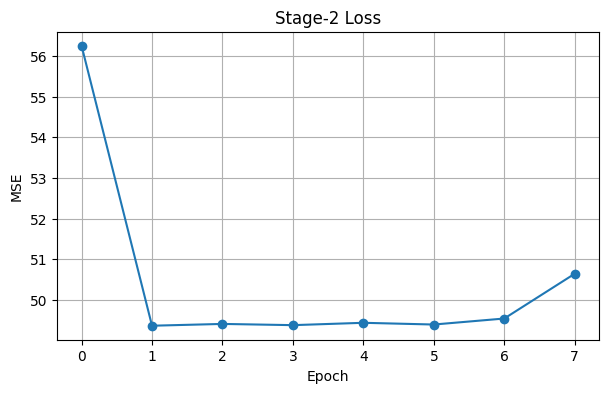

In [97]:
# --------------------------
# Stage-2 (REWORKED) — token-sequence transformer fusion (per-token outputs)
# Includes working summary + diagnostics
# --------------------------

import os, time
from typing import List
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary  # pip install torchinfo
import matplotlib.pyplot as plt

# ---- CONFIG ----
device = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
os.makedirs(OUT_DIR, exist_ok=True)

BATCH_SIZE = 16
LR = 1e-3
EPOCHS = 8
NUM_WORKERS = 2
NUM_MODALITIES = len(EO_LIST)   # EO_LIST from Stage1
EMBED_DIM = 128                 # must match Stage1 ViT embedding
TOKENS_PER_MODALITY = 64        # from Stage1 patch embedding

# ---- Dataset ----
class RowTokenDatasetVar(Dataset):
    def __init__(self, collapsed_embeddings: dict, collapsed_targets: dict, eo_list: List[str]):
        self.collapsed_embeddings = collapsed_embeddings
        self.collapsed_targets = collapsed_targets
        self.row_ids = list(collapsed_targets.keys())
        self.eo_list = eo_list

    def __len__(self):
        return len(self.row_ids)

    def __getitem__(self, idx):
        rid = self.row_ids[idx]
        emb_entry = self.collapsed_embeddings[rid]
        tokens_list = []
        seg_list = []

        for m_idx, eo in enumerate(self.eo_list):
            t = None
            if isinstance(emb_entry, dict):
                t = emb_entry.get(eo, None)
            else:
                t = emb_entry[m_idx] if m_idx < len(emb_entry) else None

            if t is None:
                t = torch.zeros((TOKENS_PER_MODALITY, EMBED_DIM), dtype=torch.float32)
            elif not isinstance(t, torch.Tensor):
                t = torch.tensor(t, dtype=torch.float32)
            if t.ndim == 1:
                t = t.unsqueeze(0)
            if t.shape[1] != EMBED_DIM:
                D = t.shape[1]
                if D > EMBED_DIM:
                    t = t[:, :EMBED_DIM]
                else:
                    t = torch.cat([t, torch.zeros((t.shape[0], EMBED_DIM - D))], dim=1)

            tokens_list.append(t)
            seg_list.append(torch.full((t.shape[0],), m_idx, dtype=torch.long))

        token_seq = torch.cat(tokens_list, dim=0)  # [T, D]
        seg_ids = torch.cat(seg_list, dim=0)       # [T]
        target = self.collapsed_targets[rid]
        target = torch.tensor(target, dtype=torch.float32) if not isinstance(target, torch.Tensor) else target.float()

        return token_seq, seg_ids, target, rid

# ---- Collate function ----
def collate_rowtoken(batch):
    seqs, segs, targets, rids = zip(*batch)
    max_len = max([s.shape[0] for s in seqs])
    B = len(seqs)
    padded = torch.zeros((B, max_len, EMBED_DIM), dtype=torch.float32)
    seg_batch = torch.full((B, max_len), -1, dtype=torch.long)
    mask = torch.zeros((B, max_len), dtype=torch.bool)
    for i, (s, seg) in enumerate(zip(seqs, segs)):
        L = s.shape[0]
        padded[i, :L, :] = s
        seg_batch[i, :L] = seg
        mask[i, :L] = 1
    targets = torch.stack(targets).float()
    return padded, seg_batch, mask, targets, list(rids)

# ---- Dataset + loader ----
dataset = RowTokenDatasetVar(collapsed_embeddings, collapsed_targets, EO_LIST)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_rowtoken,
                    num_workers=NUM_WORKERS, pin_memory=True)

# ---- Transformer model ----
class ModalityFusionTransformer(nn.Module):
    def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=3, dim_feedforward=256, dropout=0.1, max_pos=1024):
        super().__init__()
        self.mod_emb = nn.Embedding(num_modalities, embed_dim)
        self.pos_emb = nn.Embedding(max_pos, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, 1)

        nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)

    def forward(self, x, seg_ids, mask):
        B, T, D = x.shape
        pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        pos_emb = self.pos_emb(pos_idx)
        seg_ids_clamped = seg_ids.clone()
        seg_ids_clamped[seg_ids_clamped < 0] = 0
        mod_emb = self.mod_emb(seg_ids_clamped)
        mod_emb = mod_emb * mask.unsqueeze(-1).float()
        pos_emb = pos_emb * mask.unsqueeze(-1).float()
        x = x + mod_emb + pos_emb
        key_padding_mask = ~mask
        x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
        x_enc = self.norm(x_enc)
        token_logits = self.head(x_enc).squeeze(-1)
        return token_logits

    # helper to get last tokens (for diagnostics)
    def get_last_tokens(self, x, seg_ids, mask):
        B, T, D = x.shape
        pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        pos_emb = self.pos_emb(pos_idx)
        seg_ids_clamped = seg_ids.clone()
        seg_ids_clamped[seg_ids_clamped < 0] = 0
        mod_emb = self.mod_emb(seg_ids_clamped)
        mod_emb = mod_emb * mask.unsqueeze(-1).float()
        pos_emb = pos_emb * mask.unsqueeze(-1).float()
        x = x + mod_emb + pos_emb
        key_padding_mask = ~mask
        x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
        x_enc = self.norm(x_enc)
        return x_enc

# ---- Instantiate ----
model = ModalityFusionTransformer(embed_dim=EMBED_DIM, num_modalities=len(EO_LIST),
                                  nhead=4, nlayers=3, dim_feedforward=512,
                                  dropout=0.1, max_pos=2048).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# ---- Working torchinfo summary ----
batch_example = next(iter(loader))
padded_ex, seg_ex, mask_ex, targets_ex, rids_ex = batch_example
print("Example batch shapes -> padded:", padded_ex.shape, "seg:", seg_ex.shape, "mask:", mask_ex.shape, "targets:", targets_ex.shape)
try:
    print("\nModel summary (based on example batch):")
    summary(model, input_data=(padded_ex.to(device), seg_ex.to(device), mask_ex.to(device)), depth=3, col_names=("input_size","output_size","num_params"))
except Exception as e:
    print("torchinfo.summary failed:", e)

# ---- Stage-2 Output Diagnostic ----
print("\n==================== Stage 2 Output Diagnostic ====================")
with torch.no_grad():
    output_tokens = model.get_last_tokens(padded_ex.to(device), seg_ex.to(device), mask_ex.to(device))
    print("Per-modality token shapes:")
    start = 0
    for m_idx, mod in enumerate(EO_LIST):
        tokens = padded_ex[:, m_idx*TOKENS_PER_MODALITY:(m_idx+1)*TOKENS_PER_MODALITY, :]
        print(f"  {mod:12s}: tokens = {tokens.shape[1]}, embed_dim = {tokens.shape[2]}")
        start += TOKENS_PER_MODALITY

    print("\nBatch fused sequence shape (after Transformer):")
    print(f"  {tuple(output_tokens.shape)}")  # [B, T, D]

    # average per-sample scalar
    token_logits = model(padded_ex.to(device), seg_ex.to(device), mask_ex.to(device))
    sample_preds = (token_logits * mask_ex.to(device).float()).sum(dim=1) / mask_ex.sum(dim=1).clamp(min=1).float()
    print("\nExample per-sample scalar prediction:")
    print(f"  avg(valid_tokens={mask_ex.sum(dim=1)[0].item()}) = {sample_preds[0].item():.4f}")
print("===================================================================\n")

# ---- Training loop ----
print("Stage-2 training start ->", len(dataset), "samples")
best_loss = float("inf")
history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    t0 = time.time()
    for padded, seg_ids, mask, targets, rids in loader:
        padded = padded.to(device)
        seg_ids = seg_ids.to(device)
        mask = mask.to(device)
        targets = targets.to(device)

        opt.zero_grad()
        token_preds = model(padded, seg_ids, mask)
        valid_counts = mask.sum(dim=1).clamp(min=1).float()
        sample_preds = (token_preds * mask.float()).sum(dim=1) / valid_counts
        loss = criterion(sample_preds, targets)
        loss.backward()
        opt.step()

        B = targets.size(0)
        epoch_loss += loss.item() * B
        n_samples += B

    epoch_loss /= n_samples
    history.append(epoch_loss)
    t_taken = time.time() - t0
    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss:.4f} — time: {t_taken:.1f}s")

    # save best model only
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        save_path = os.path.join(OUT_DIR, "Stage_2_fusion_token_regressor_attn.pth")
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch+1, "loss": epoch_loss}, save_path)
        print("✓ saved best fusion model ->", save_path)

print("Training complete. Best loss:", best_loss)

# ---- Save history + plot ----
torch.save({"history": history}, os.path.join(OUT_DIR, "Stage_2_fusion_history_attn.pth"))
plt.figure(figsize=(7,4)); plt.plot(history, marker='o'); plt.title("Stage-2 Loss"); plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.grid(True); plt.show()


In [98]:
# # ---------- Stage 2: Token-sequence fusion training (drop-in) ----------
# import os, math, random, time
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader

# # ------------- Config -------------
# device = "cuda" if torch.cuda.is_available() else "cpu"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
# os.makedirs(OUT_DIR, exist_ok=True)

# EMBED_DIM = 128           # embedding dim from ViT encoders
# BATCH_SIZE = 16
# LR = 1e-3
# EPOCHS = 8                # adjust
# NUM_WORKERS = 2

# # ------------- Dataset -------------
# class RowTokenDataset(Dataset):
#     """
#     Each sample -> one token sequence made by concatenating modality token sequences.
#     collapsed_embeddings[row_id] is a list of tensors, each [N_tokens_mod, EMBED_DIM],
#     so we concat along dim=0 -> [T, EMBED_DIM] where T = sum(N_tokens_mod).
#     """
#     def __init__(self, collapsed_embeddings, collapsed_targets, row_ids=None):
#         self.collapsed_embeddings = collapsed_embeddings
#         self.collapsed_targets = collapsed_targets
#         self.row_ids = list(collapsed_targets.keys()) if row_ids is None else row_ids

#     def __len__(self):
#         return len(self.row_ids)

#     def __getitem__(self, idx):
#         row_id = self.row_ids[idx]
#         mod_list = self.collapsed_embeddings[row_id]   # list of tensors [N_mod, EMBED_DIM] or [N_tokens, EMBED_DIM]
#         # ensure tensors are float32 and detached clones
#         tokens_per_mod = []
#         for t in mod_list:
#             if not isinstance(t, torch.Tensor):
#                 t = torch.tensor(t, dtype=torch.float32)
#             else:
#                 t = t.detach().clone().float()
#             # expected shape: [N_tokens, EMBED_DIM]
#             if t.ndim == 1:
#                 t = t.unsqueeze(0)
#             tokens_per_mod.append(t)

#         # concat tokens across modalities along token axis -> token_seq: [T, EMBED_DIM]
#         token_seq = torch.cat(tokens_per_mod, dim=0)

#         target = self.collapsed_targets[row_id]
#         if not isinstance(target, torch.Tensor):
#             target = torch.tensor(target, dtype=torch.float32)
#         else:
#             target = target.detach().clone().float()

#         return token_seq, target, row_id

# # ------------- Collate fn (pad token sequences to max length in batch) -------------
# def collate_pad(batch):
#     # batch: list of (token_seq [T, D], target scalar, row_id)
#     token_seqs, targets, row_ids = zip(*batch)
#     lengths = [t.shape[0] for t in token_seqs]
#     max_len = max(lengths)
#     D = token_seqs[0].shape[1]

#     padded = torch.zeros(len(batch), max_len, D, dtype=torch.float32)
#     mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
#     for i, t in enumerate(token_seqs):
#         L = t.shape[0]
#         padded[i, :L, :] = t
#         mask[i, :L] = 1   # valid token positions

#     targets = torch.stack([t for t in targets]).float()
#     return padded, mask, targets, list(row_ids)

# # ------------- Build dataset/dataloader -------------
# dataset = RowTokenDataset(collapsed_embeddings, collapsed_targets)
# loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_pad,
#                     num_workers=NUM_WORKERS, pin_memory=True)

# # ------------- Model: token-level regressor -------------
# class TokenAttentionRegressor(nn.Module):
#     """
#     Input: x [B, T, D]
#     Output: per-token scalar preds [B, T] (we will average to get sample scalar)
#     """
#     def __init__(self, embed_dim=128, num_heads=4, dropout=0.0):
#         super().__init__()
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
#         self.norm = nn.LayerNorm(embed_dim)
#         self.head = nn.Linear(embed_dim, 1)   # per-token scalar
#         self.dropout = nn.Dropout(dropout)

#     def forward(self, x, mask=None):
#         # x: [B, T, D], mask: [B, T] bool (True where token valid)
#         attn_out, _ = self.attn(x, x, x, key_padding_mask=~mask if mask is not None else None)
#         x = self.norm(attn_out + x)
#         x = self.dropout(x)
#         token_logits = self.head(x).squeeze(-1)  # [B, T]
#         return token_logits

# # ------------- Instantiate -------------
# model = TokenAttentionRegressor(embed_dim=EMBED_DIM, num_heads=4).to(device)
# opt = torch.optim.Adam(model.parameters(), lr=LR)
# criterion = nn.MSELoss()

# # ------------- Training loop -------------
# print("Stage-2 training start ->", len(dataset), "samples")
# best_loss = float("inf")
# history = []

# for epoch in range(EPOCHS):
#     model.train()
#     epoch_loss = 0.0
#     n_samples = 0
#     t0 = time.time()

#     for padded, mask, targets, row_ids in loader:
#         padded = padded.to(device)        # [B, maxT, D]
#         mask = mask.to(device)            # [B, maxT]
#         targets = targets.to(device)      # [B]

#         opt.zero_grad()
#         token_preds = model(padded, mask=mask)   # [B, maxT]

#         # Compute sample-level prediction: mean over valid tokens per sample
#         sum_valid = mask.sum(dim=1).clamp(min=1).float()   # avoid div by 0
#         sample_preds = (token_preds * mask.float()).sum(dim=1) / sum_valid  # [B]

#         loss = criterion(sample_preds, targets)
#         loss.backward()
#         opt.step()

#         B = targets.size(0)
#         epoch_loss += loss.item() * B
#         n_samples += B

#     epoch_loss = epoch_loss / n_samples
#     history.append(epoch_loss)
#     t_taken = time.time() - t0
#     print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss:.4f} — time: {t_taken:.1f}s")

#     # save best
#     if epoch_loss < best_loss:
#         best_loss = epoch_loss
#         save_path = os.path.join(OUT_DIR, "Stage_2_fusion_token_regressor.pth")
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "loss": epoch_loss
#         }, save_path)
#         print("✓ saved best fusion model ->", save_path)

# print("Training complete. Best loss:", best_loss)

# # ------------- Notes & quick inference helper -------------
# # Save training history
# torch.save({"history": history}, os.path.join(OUT_DIR, "Stage_2_fusion_history.pth"))

# # Quick inference function (per-sample). Later you'll use full encoder loading & file iteration:
# def infer_row_token_sequence(token_seq, model, device="cpu"):
#     """
#     token_seq: torch.Tensor [T, D], model on device
#     returns: sample_pred_scalar, token_preds (T,)
#     """
#     model.eval()
#     with torch.no_grad():
#         t = token_seq.unsqueeze(0).to(device)   # [1, T, D]
#         mask = torch.ones(1, t.shape[1], dtype=torch.bool, device=device)
#         token_preds = model(t, mask=mask).squeeze(0).cpu().numpy()  # [T]
#         sample_pred = float(token_preds.mean())
#     return sample_pred, token_preds

# # -------------------------- PLOT LEARNING CURVE --------------------------
# import matplotlib.pyplot as plt

# plt.figure(figsize=(7,5))
# plt.plot(history, linewidth=2)
# plt.xlabel("Epoch", fontsize=12)
# plt.ylabel("MSE Loss", fontsize=12)
# plt.title("Stage-2 Training Loss Curve", fontsize=14)
# plt.grid(True)
# plt.show()


# # ----------------------------------------------------------------------
# # End of Stage-2 block.
# # ----------------------------------------------------------------------


In [99]:
# from torchinfo import summary

# # dummy input example
# example_input = torch.zeros(1, 100, EMBED_DIM).to(device)
# example_mask  = torch.ones(1, 100, dtype=torch.bool).to(device)

# print(summary(model,
#               input_data=(example_input, example_mask),
#               col_names=["input_size","output_size","num_params","kernel_size","mult_adds"]))


xxxxx

In [100]:
# import torch

# # Example: create a single batch (all samples) for training
# # Train EO modalities
# # Train EO modalities
# train_eo_emb = {k: v.detach().clone() if isinstance(v, torch.Tensor) else torch.tensor(v)
#                 for k, v in all_embeddings.items() if k != 'waveform'}

# train_wave_emb = all_embeddings['waveform'].detach().clone() if isinstance(all_embeddings['waveform'], torch.Tensor) else torch.tensor(all_embeddings['waveform'])

# # Targets (take reference from s1)
# train_targets = all_RH_targets['s1'].detach().clone() if isinstance(all_RH_targets['s1'], torch.Tensor) else torch.tensor(all_RH_targets['s1'])


# # Make a batch_dict for model input
# train_batch_dict = {**train_eo_emb, 'waveform': train_wave_emb}

# # Check shapes
# for k, v in train_batch_dict.items():
#     print(f"{k}: {v.shape}")
# print("targets:", train_targets.shape)



In [101]:
# import torch
# from torch.utils.data import Dataset

# class RowIDDataset(Dataset):
#     def __init__(self, collapsed_embeddings, collapsed_targets):
#         self.row_ids = list(collapsed_targets.keys())
#         self.collapsed_embeddings = collapsed_embeddings
#         self.collapsed_targets = collapsed_targets

#     def __len__(self):
#         return len(self.row_ids)

#     def __getitem__(self, idx):
#         row_id = self.row_ids[idx]
#         emb_list = self.collapsed_embeddings[row_id]  # list of tensors
#         target = self.collapsed_targets[row_id]

#         tokens = torch.stack(emb_list)  # [N_tokens, 128]
#         return tokens, target.float()


In [102]:
# def collate_fn(batch):
#     tokens_list, targets_list = zip(*batch)
#     max_len = max(t.shape[0] for t in tokens_list)
#     embed_dim = tokens_list[0].shape[1]

#     padded_tokens = []
#     for t in tokens_list:
#         pad_len = max_len - t.shape[0]
#         if pad_len > 0:
#             padding = torch.zeros(pad_len, embed_dim)
#             t = torch.cat([t, padding], dim=0)
#         padded_tokens.append(t)

#     tokens_batch = torch.stack(padded_tokens)  # [B, max_len, embed_dim]
#     targets_batch = torch.stack(targets_list)  # [B]
#     return tokens_batch, targets_batch


In [103]:
# from torch.utils.data import DataLoader

# dataset_obj = RowIDDataset(collapsed_embeddings, collapsed_targets)
# loader = DataLoader(dataset_obj, batch_size=16, shuffle=True, collate_fn=collate_fn)


In [104]:
# ## 11/25 fix for token sequence predictions (1024 predictions in a 32x32 patch)
# import torch
# import torch.nn as nn
# import math

# class DenseMultimodalRegressor(nn.Module):
#     """
#     Input: x: [B, N_tokens, embed_dim]
#     Output: per-token local pixel predictions: [B, N_tokens, token_px*token_px]
#     We'll then reshape into small patches per token.
#     """
#     def __init__(self, embed_dim=128, num_heads=4, token_pixel=4):
#         super().__init__()
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
#         self.norm = nn.LayerNorm(embed_dim)
#         # Output how many pixels per token (token_pixel^2)
#         self.token_pixel = token_pixel
#         self.out_dim = token_pixel * token_pixel
#         self.head = nn.Linear(embed_dim, self.out_dim)

#     def forward(self, x):
#         # x: [B, N_tokens, embed_dim]
#         attn_out, _ = self.attn(x, x, x)
#         x = self.norm(attn_out)  # [B, N_tokens, embed_dim]
#         token_preds = self.head(x)  # [B, N_tokens, token_px*token_px]
#         # return token-level flattened small patches
#         return token_preds  # [B, N_tokens, token_px^2]


# ##11/21 Works but only for single patch token so only 1 prediciton at 32x32 patch swapping to above solution
# # import torch.nn as nn

# # class MultimodalAttentionRegressor(nn.Module):
# #     def __init__(self, embed_dim=128, num_heads=4):
# #         super().__init__()
# #         self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
# #         self.head = nn.Linear(embed_dim, 1)

# #     def forward(self, x):
# #         # x: [B, N_tokens, embed_dim]
# #         attn_out, _ = self.attn(x, x, x)
# #         pooled = attn_out.mean(dim=1)  # mean pooling over tokens
# #         out = self.head(pooled)        # [B, 1]
# #         return out.squeeze(1)           # [B]


In [105]:
# ############################################################
# # 5. Training Loop
# ############################################################

# model = MultimodalAttentionRegressor().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# criterion = nn.MSELoss()

# loss_history = []

# EPOCHS = 10

# for epoch in range(EPOCHS):
#     model.train()
#     total_loss = 0

#     for tokens, targets in loader:
#         tokens = tokens.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         preds = model(tokens)
#         loss = criterion(preds, targets)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * tokens.size(0)

#     epoch_loss = total_loss / len(dataset_obj)
#     loss_history.append(epoch_loss)
#     print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss:.5f}")


# ############################################################
# # 6. Plot Loss
# ############################################################

# plt.figure(figsize=(6,4))
# plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
# plt.xlabel("Epoch")
# plt.ylabel("MSE Loss")
# plt.title("Fusion Training Loss")
# plt.grid(True)
# plt.show()


# ############################################################
# # 7. SAVE FUSION MODEL  (needed for Stage 3 inference)
# ############################################################

# SAVE_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_regressor.pth"

# # --- Recommended format ---
# torch.save({
#     "model_state_dict": model.state_dict(),
#     "epoch": EPOCHS,
#     "loss_history": loss_history,
# }, SAVE_PATH)

# print("✅ Fusion model saved to:", SAVE_PATH)

# # Optional: also save torchscript for portability
# SCRIPT_PATH = SAVE_PATH.replace(".pth", "_script.pt")
# traced = torch.jit.trace(model, torch.randn(1, 10, 128).to(device))
# torch.jit.save(traced, SCRIPT_PATH)

# print("✅ TorchScript model saved to:", SCRIPT_PATH)

### Frozen Stage 2 Load multi modal fusion modal

'/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor_attn.pth"

# Stage 3

https://github.com/MayerT1/Prep_GEDI/blob/main/prep_inference_75Overlap__matching_GroundSampleArea.ipynb

This is the ground sample area match data set: '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/Copy_of_chips_preprocessed_Matching_ground.zip'

In [117]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/Copy_of_chips_preprocessed_Matching_ground.zip'
extract_to = '/content/inference_chips_aligned'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"✓ Extracted to: {extract_to}")

# Count files
from glob import glob
all_chips = glob(os.path.join(extract_to, '**/*.tif'), recursive=True)
print(f"Total chips: {len(all_chips)}")

✓ Extracted to: /content/inference_chips_aligned
Total chips: 192192


In [118]:
from collections import Counter
import re

pattern = re.compile(r'([^/]+)_\d{4}_\d{4}_\d{4}\.tif$')
modality_counts = Counter()

for chip in all_chips:
    match = pattern.search(chip)
    if match:
        modality = match.group(1)
        modality_counts[modality] += 1

print("\nChips per modality:")
for mod, count in sorted(modality_counts.items()):
    print(f"  {mod}: {count}")


Chips per modality:
  DEMindices: 24024
  HLS: 24024
  LandsatComposite: 24024
  LandsatIndices: 24024
  S2Composite: 24024
  S2Indices: 24024
  landsatTasseledCapIndices: 24024
  s1Ascending: 24024


## Frozen inference prepprocessed 75 overlap tif https://zenodo.org/records/17756815

In [106]:
# #works ofr tiff not zarr 11/26
# import os

# EO_inference_folder = "/content/EO_inference_folder"
# os.makedirs(EO_inference_folder, exist_ok=True)

# print("EO_inference_folder:", EO_inference_folder)

EO_inference_folder: /content/EO_inference_folder


In [107]:
# import os
# import requests
# import zipfile

# # -----------------------------------------------------------
# # 1. Define paths
# # -----------------------------------------------------------
# zip_url = "https://zenodo.org/records/17756815/files/32x32_tif_patch_75_overlap_Preprocessing.zip?download=1"
# local_zip_path = "/content/32x32_tif_patch_75_overlap_Preprocessing.zip"
# extract_dir = "/content/EO_inference_folder"

# # Make sure the output folder exists
# os.makedirs(extract_dir, exist_ok=True)

# # -----------------------------------------------------------
# # 2. Download ZIP from Zenodo
# # -----------------------------------------------------------
# print("Downloading ZIP file...")
# response = requests.get(zip_url, stream=True)

# with open(local_zip_path, "wb") as f:
#     for chunk in response.iter_content(chunk_size=8192):
#         if chunk:
#             f.write(chunk)

# print("Download complete:", local_zip_path)

# # -----------------------------------------------------------
# # 3. Extract ZIP into /content/EO_inference_folder
# # -----------------------------------------------------------
# print("Extracting ZIP...")
# with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# print("Extraction complete!")
# print("Extracted to:", extract_dir)


Download complete: /content/32x32_tif_patch_75_overlap_Preprocessing.zip
Extracting ZIP...
Extraction complete!
Extracted to: /content/EO_inference_folder


#### Prep Inference (Similar to before for training)

check the files before moving them

In [108]:
# import os

# folder = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/32x32_tif_patch"

# prefixes = [
#     "s1Ascending",
#     "S2Composite",
#     "S2Indices",
#     "LandsatComposite",
#     "LandsatIndices",
#     "HLS",
#     "landsatTasseledCapIndices",
#     "DEMindices"
# ]

# # Initialize counts
# counts = {p: 0 for p in prefixes}

# # Loop through directory
# for fname in os.listdir(folder):
#     for p in prefixes:
#         if fname.startswith(p):
#             counts[p] += 1
#             break  # avoid double-counting if two prefixes overlap

# # Print results
# for p, c in counts.items():
#     print(f"{p}: {c}")


In [109]:
# #works ofr tiff not zarr 11/26
# import os

# EO_inference_folder = "/content/EO_inference_folder"
# os.makedirs(EO_inference_folder, exist_ok=True)

# print("EO_inference_folder:", EO_inference_folder)

### Move Inference tifs

In [110]:
# ##works ofr tiff not zarr 11/26
# import os
# import shutil

# src_dir = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/32x32_tif_patch"
# dst_dir = "/content/EO_inference_folder"

# # Create destination folder if not existing
# os.makedirs(dst_dir, exist_ok=True)

# # Move all .tif files
# for file in os.listdir(src_dir):
#     if file.endswith(".tif"):
#         shutil.copy2(os.path.join(src_dir, file), os.path.join(dst_dir, file))

# print("Finished copying TIFF files!")


Investigate INF a set of Tifs before modifying/prepping

In [111]:
# ##works ofr tiff not zarr 11/26
# import os
# import random


# # list only .tif files in the folder
# selected_files = [f for f in os.listdir(dst_dir) if f.lower().endswith(".tif")]

# # sample 5 files
# sample_files_Inf = random.sample(selected_files, 5)
# sample_files_Inf


In [112]:
# ##works ofr tiff not zarr 11/26
# import rasterio
# import numpy as np
# import os
# import matplotlib.pyplot as plt

# for fname in sample_files_Inf:
#     fpath = os.path.join(dst_dir, fname)

#     print("\n" + "="*80)
#     print("FILE:", fname)

#     with rasterio.open(fpath) as src:
#         width = src.width
#         height = src.height
#         count = src.count
#         transform = src.transform

#         print(f"BANDS: {count}")
#         print(f"SIZE (pixels): {width} x {height}")
#         print(f"TOTAL PIXELS: {width * height}")
#         print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (approx meters)")

#         # Loop over bands for stats
#         for b in range(1, count + 1):
#             data = src.read(b).astype(float)

#             # Mask nodata
#             if src.nodata is not None:
#                 data = np.where(data == src.nodata, np.nan, data)

#             print(f"\n  Band {b} statistics:")
#             print(f"      min:  {np.nanmin(data)}")
#             print(f"      max:  {np.nanmax(data)}")
#             print(f"      mean: {np.nanmean(data)}")
#             print(f"      std:  {np.nanstd(data)}")

#         # ---- Visualization ----
#         plt.figure(figsize=(6, 6))

#         if count >= 3:
#             img = src.read([1, 2, 3]).transpose(1, 2, 0)

#             # Normalize for display
#             img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)

#             plt.imshow(img)
#             plt.title(f"RGB visualization: {fname}")

#         elif count == 1:
#             img = src.read(1)
#             plt.imshow(img, cmap='gray')
#             plt.title(f"Single-band grayscale: {fname}")

#         else:
#             print(f"Skipping visualization for {fname}: unsupported band count.")

#         plt.axis('off')
#         plt.show()


### Prep tifs: Pad, Normalize, inspect, save to content

In [113]:
# import rasterio
# import numpy as np
# import os

# # -------------------------------------------------------------------------
# # CONFIG
# # -------------------------------------------------------------------------
# # Directory containing your TIFFs
# # dst_dir = "/content/EO_inference_folder"

# os.makedirs(dst_dir, exist_ok=True)

# print("Scanning directory:", dst_dir)

# all_tifs = [
#     f for f in os.listdir(dst_dir)
#     if f.lower().endswith((".tif", ".tiff"))
# ]

# total_files = len(all_tifs)
# corrected_files = 0
# untouched_files = 0

# print(f"\nFound {total_files} TIFFs in {dst_dir}\n")

# # -------------------------------------------------------------------------
# # PROCESSING
# # -------------------------------------------------------------------------

# for fname in all_tifs:
#     fpath = os.path.join(dst_dir, fname)

#     with rasterio.open(fpath) as src:
#         profile = src.profile.copy()
#         band_count = src.count

#         bands = []
#         nan_stats = []   # store # of NaNs per band

#         # Read each band
#         for b in range(1, band_count + 1):
#             data = src.read(b).astype(float)

#             # Convert nodata → NaN
#             if src.nodata is not None:
#                 data[data == src.nodata] = np.nan

#             nan_count = np.isnan(data).sum()
#             nan_stats.append(nan_count)

#             # Replace NaNs with median if necessary
#             if nan_count > 0:
#                 med = np.nanmedian(data)

#                 # If entire band is NaN, median = NaN
#                 # Replace all NaN with 0 to avoid crashing
#                 if np.isnan(med):
#                     med = 0.0

#                 data = np.where(np.isnan(data), med, data)

#             bands.append(data)

#     # PRINT PER-FILE SUMMARY
#     print(f"\nProcessing: {fname}")
#     for i, n in enumerate(nan_stats, start=1):
#         print(f"  Band {i}: {n} NaNs {'(fixed)' if n > 0 else '(clean)'}")

#     # Determine whether anything was modified
#     if any(n > 0 for n in nan_stats):
#         corrected_files += 1
#         print(f"  --> FIXED NaNs and rewriting TIFF.\n")

#         # Write cleaned TIFF back to disk
#         with rasterio.open(fpath, "w", **profile) as dst:
#             for i, band in enumerate(bands, start=1):
#                 dst.write(band.astype(profile["dtype"]), i)
#     else:
#         untouched_files += 1
#         print("  --> No NaNs found. File left unchanged.\n")

# # -------------------------------------------------------------------------
# # FINAL SUMMARY
# # -------------------------------------------------------------------------
# print("\n" + "=" * 70)
# print("TIFF NaN CLEANUP SUMMARY")
# print("=" * 70)
# print(f"Total TIFFs scanned         : {total_files}")
# print(f"TIFFs with NaNs corrected   : {corrected_files}")
# print(f"TIFFs already clean         : {untouched_files}")
# print("=" * 70)
# print("Completed median-fill correction for ALL TIFFs.")
# print("No files were dropped or deleted.")
# print("=" * 70 + "\n")














# # #works for tiff not zarr 11/26

# # import rasterio
# # import numpy as np
# # import os

# # # -------------------------------------------------------------------------
# # # 1. QUALITY CHECK: only scan TIFFs in PROCESSED_DIR
# # # -------------------------------------------------------------------------

# # # PROCESSED_DIR = "/content/processed_32x32_normalized"
# # dst_dir = "/content/EO_inference_folder"
# # os.makedirs(dst_dir, exist_ok=True)

# # print("Scanning directory:", dst_dir)

# # all_tifs = [
# #     f for f in os.listdir(dst_dir)
# #     if f.lower().endswith((".tif", ".tiff"))
# # ]

# # total_files = len(all_tifs)
# # corrected_files = 0
# # dropped_files = 0

# # print(f"\nFound {total_files} TIFFs in {dst_dir}\n")

# # selected_files = []   # <-- Files that pass checks
# # dropped_list = []     # <-- Files to delete


# # for fname in all_tifs:
# #     fpath = os.path.join(dst_dir, fname)

# #     with rasterio.open(fpath) as src:
# #         bands = []
# #         needs_correction = False
# #         too_many_nans = False

# #         for b in range(1, src.count + 1):
# #             data = src.read(b).astype(float)

# #             if src.nodata is not None:
# #                 data[data == src.nodata] = np.nan

# #             nan_count = np.isnan(data).sum()

# #             if nan_count > 0:
# #                 needs_correction = True
# #             if nan_count >= 1024: #100:
# #                 too_many_nans = True

# #             bands.append(data)

# #     # Drop files with too many NaNs
# #     if too_many_nans:
# #         dropped_files += 1
# #         dropped_list.append(fname)     # <--- NOW correctly recorded
# #         print(f"DROPPED: {fname} (≥100 NaNs)")
# #         continue

# #     # Fix files that have ≤99 NaNs
# #     if needs_correction:
# #         corrected_files += 1
# #         print(f"FIXING: {fname} (median fill)")

# #         cleaned_bands = []
# #         for data in bands:
# #             if np.isnan(data).any():
# #                 med = np.nanmedian(data)
# #                 data = np.where(np.isnan(data), med, data)
# #             cleaned_bands.append(data)

# #         # Write cleaned TIFF back to disk
# #         with rasterio.open(fpath) as src:
# #             profile = src.profile

# #         with rasterio.open(fpath, "w", **profile) as dst:
# #             for i, band in enumerate(cleaned_bands, start=1):
# #                 dst.write(band.astype(profile["dtype"]), i)

# #     # Keep this TIFF for further processing
# #     selected_files.append(fname)

# # # -------------------------------------------------------------------------
# # # SUMMARY
# # # -------------------------------------------------------------------------
# # print("\n" + "="*60)
# # print("TIFF QUALITY CHECK SUMMARY")
# # print(f"Total TIFFs scanned           : {total_files}")
# # print(f"TIFFs corrected (median fill) : {corrected_files}")
# # print(f"TIFFs dropped (≥100 NaNs)     : {dropped_files}")
# # print(f"TIFFs passed to processing    : {len(selected_files)}")
# # print("="*60 + "\n")

# # print("Dropped files:", dropped_list)

# # # -------------------------------------------------------------------------
# # # DELETE DROPPED FILES
# # # -------------------------------------------------------------------------
# # print("\nDeleting dropped TIFF files...\n")

# # for fname in dropped_list:
# #     fpath = os.path.join(PROCESSED_DIR, fname)
# #     if os.path.exists(fpath):
# #         os.remove(fpath)
# #         print("Deleted:", fname)

# # print("\nFinished deleting dropped TIFFs.")
# # print("Total deleted files:", len(dropped_list))


warning 30 minute run time

In [114]:
# ##works for tiff not zarr 11/26
# import rasterio
# from rasterio.transform import Affine
# from rasterio.enums import Resampling
# import numpy as np
# import os

# # import rasterio
# from rasterio.transform import Affine
# from rasterio.enums import Resampling
# import numpy as np
# import os

# # Pre-existing functions
# def resize_to_max32(src):
#     h = src.height
#     w = src.width
#     bands = src.count

#     if h <= 32 and w <= 32:
#         return src.read(), src.transform

#     scale_h = 32 / h
#     scale_w = 32 / w
#     scale = min(scale_h, scale_w)

#     new_h = max(1, int(h * scale))
#     new_w = max(1, int(w * scale))

#     resized = src.read(
#         out_shape=(bands, new_h, new_w),
#         resampling=Resampling.bilinear
#     )

#     new_transform = Affine(
#         src.transform.a / scale, src.transform.b, src.transform.c,
#         src.transform.d, src.transform.e / scale, src.transform.f
#     )

#     return resized, new_transform

# def pad_to_32x32(arr, transform):
#     bands, h, w = arr.shape
#     padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

#     h_start = (32 - h) // 2
#     w_start = (32 - w) // 2

#     padded[:, h_start:h_start+h, w_start:w_start+w] = arr
#     new_transform = transform * Affine.translation(-w_start, -h_start)
#     return padded, new_transform

# def minmax_normalize(arr):
#     arr = arr.astype(float)
#     for b in range(arr.shape[0]):
#         mn = np.nanmin(arr[b])
#         mx = np.nanmax(arr[b])
#         arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
#     return arr

# # Folder with TIFFs
# INPUT_DIR = "/content/EO_inference_folder"
# OUTPUT_DIR = INPUT_DIR  # overwrite or set a different folder

# # Collect all TIFF files
# selected_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(".tif") or f.lower().endswith(".tiff")]

# processed_paths = {}

# for fname in selected_files:
#     src_path = os.path.join(INPUT_DIR, fname)
#     out_path = os.path.join(OUTPUT_DIR, fname)  # overwrite original files or change name

#     with rasterio.open(src_path) as src:
#         # Step 1: Resize
#         resized, transform_resized = resize_to_max32(src)

#         # Step 2: Pad
#         padded, transform_padded = pad_to_32x32(resized, transform_resized)

#         # Step 3: Normalize
#         normalized = minmax_normalize(padded)

#         # Write raster
#         profile = src.profile.copy()
#         profile.update({
#             "height": 32,
#             "width": 32,
#             "transform": transform_padded,
#             "dtype": "float32"
#         })

#         with rasterio.open(out_path, "w", **profile) as dst:
#             dst.write(normalized.astype("float32"))

#     processed_paths[fname] = out_path

# print("Processed", len(processed_paths), "TIFFs successfully.")



Confirm Infernece is prepped

In [115]:
# import os

# folder = "/content/EO_inference_folder"

# prefixes = [
#     "s1Ascending",
#     "S2Composite",
#     "S2Indices",
#     "LandsatComposite",
#     "LandsatIndices",
#     "HLS",
#     "landsatTasseledCapIndices",
#     "DEMindices"
# ]

# # Initialize counts
# counts = {p: 0 for p in prefixes}

# # Loop through directory
# for fname in os.listdir(folder):
#     for p in prefixes:
#         if fname.startswith(p):
#             counts[p] += 1
#             break  # avoid double-counting if two prefixes overlap

# # Print results
# for p, c in counts.items():
#     print(f"{p}: {c}")


In [ ]:
# ##works for tiff not zarr 11/26

# import rasterio
# import numpy as np
# import matplotlib.pyplot as plt

# for fname, fpath in processed_sample_files.items():

#     print("\n" + "="*80)
#     print("PROCESSED FILE:", fname)
#     print("LOCATION:", fpath)

#     with rasterio.open(fpath) as src:
#         width, height = src.width, src.height
#         count = src.count
#         transform = src.transform

#         print(f"BANDS: {count}")
#         print(f"SIZE (pixels): {width} x {height}")
#         print(f"TOTAL PIXELS: {width * height}")
#         print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (approx meters)")

#         # ---- Band statistics ----
#         for b in range(1, count + 1):
#             data = src.read(b).astype(float)

#             print(f"\n  Band {b} statistics:")
#             print(f"      min:  {np.nanmin(data)}")
#             print(f"      max:  {np.nanmax(data)}")
#             print(f"      mean: {np.nanmean(data)}")
#             print(f"      std:  {np.nanstd(data)}")

#         # ---- Visualization ----
#         plt.figure(figsize=(6, 6))

#         if count >= 3:
#             img = src.read([1, 2, 3]).transpose(1, 2, 0)

#             # Normalize
#             img = (img - img.min()) / (img.max() - img.min() + 1e-6)

#             plt.imshow(img)
#             plt.title(f"Processed RGB preview: {fname}")

#         else:
#             img = src.read(1)
#             plt.imshow(img, cmap="gray")
#             plt.title(f"Processed grayscale preview: {fname}")

#         plt.axis("off")
#         plt.show()


## Inference Pipeline

Claude attempt

In [119]:
# -----------------------------
# Stage-3: Full inference with enhanced smoothing
# Using geographically-aligned preprocessed chips
# -----------------------------
import os
from glob import glob
from collections import defaultdict
import re
import numpy as np
import rasterio
from rasterio.windows import Window
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter

# ------------------- CONFIG -------------------
PATCH_SIZE = 32
OVERLAP = 0.75
STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))  # 8 pixels

PATCH_EMBED_PATCH = 4
TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH  # 8
TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
EMBED_DIM = 128

# Paths
REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
PATCH_FOLDER = "/content/inference_chips_aligned"
OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed_v2.tif"

# Modality mappings
EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
eo_map = {
    "s1Ascending": "s1",
    "S2Composite": "s2",
    "S2Indices": "s2idx",
    "DEMindices": "dem",
    "landsatTasseledCapIndices": "tcap",
    "HLS": "hls",
    "LandsatComposite": "landsat",
    "LandsatIndices": "landsatidx",
}
BANDS_PER_COV = {'s1':4,'s2':6,'s2idx':8,'landsat':6,'landsatidx':7,
                 'hls':7,'tcap':6,'dem':2}

# Model paths
ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
FUSION_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor_attn.pth"

# Output settings
CLIP_MIN, CLIP_MAX = 0.0, 40.0
TOKEN_SIGMA = 2.0      # Smoothing on 8×8 token grid (anti-blocking)
PATCH_SIGMA = 1.0      # Smoothing on 32×32 patch (final polish)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running Stage 3 on device:", DEVICE)

# ------------------- Stage-1 encoder (ViT) -------------------
class PatchEmbed(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self,x):
        x_norm = self.norm1(x)
        attn_out,_ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTCustom(nn.Module):
    def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = x.transpose(0,1)
        for blk in self.blocks: x = blk(x)
        x = x.transpose(0,1)
        x = self.norm(x)
        return x[:,1:]  # return tokens only [B, 64, 128]

# ------------------- Stage-2 Fusion -------------------
class ModalityFusionTransformer(nn.Module):
    def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=3, dim_feedforward=512, dropout=0.1, max_pos=2048):
        super().__init__()
        self.embed_dim = embed_dim
        self.mod_emb = nn.Embedding(num_modalities, embed_dim)
        self.pos_emb = nn.Embedding(max_pos, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout, activation='gelu',
                                                   batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, 1)
        nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)
    def forward(self, x, seg_ids, mask):
        B, T, D = x.shape
        pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B,T)
        pos_emb = self.pos_emb(pos_idx)
        seg_ids_clamped = seg_ids.clone()
        seg_ids_clamped[seg_ids_clamped < 0] = 0
        mod_emb = self.mod_emb(seg_ids_clamped)
        x = x + mod_emb + pos_emb
        key_padding_mask = ~mask
        x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
        x_enc = self.norm(x_enc)
        token_logits = self.head(x_enc).squeeze(-1)
        return token_logits

# ------------------- Load encoders -------------------
print("Loading encoders...")
encoder_paths = {eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST}
encoders = {}
for eo in EO_LIST:
    ck = torch.load(encoder_paths[eo], map_location=DEVICE)
    enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
    state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
    enc.load_state_dict(state_dict)
    enc.to(DEVICE).eval()
    encoders[eo] = enc
print(f"✓ Loaded {len(encoders)} encoders")

# ------------------- Load Stage-2 fusion -------------------
print("Loading fusion model...")
fusion_ckpt = torch.load(FUSION_MODEL_PATH, map_location=DEVICE)
fusion_model = ModalityFusionTransformer(embed_dim=EMBED_DIM, num_modalities=len(EO_LIST)).to(DEVICE)
state_dict = fusion_ckpt["model_state_dict"] if isinstance(fusion_ckpt, dict) and "model_state_dict" in fusion_ckpt else fusion_ckpt
fusion_model.load_state_dict(state_dict)
fusion_model.eval()
print("✓ Loaded fusion model")

# ------------------- Index patches by (row, col) -------------------
print("\nIndexing patch files by location...")
patch_index = defaultdict(dict)
pattern = re.compile(r'([^_]+)_(\d{4})_(\d{4})_(\d{4})\.tif')

for filepath in glob(os.path.join(PATCH_FOLDER, '**/*.tif'), recursive=True):
    filename = os.path.basename(filepath)
    match = pattern.match(filename)
    if match:
        prefix = match.group(1)
        year = match.group(2)
        row = int(match.group(3))
        col = int(match.group(4))

        if prefix in eo_map:
            eo = eo_map[prefix]
            patch_index[(row, col)][eo] = filepath

# Filter to complete locations
complete_locations = [loc for loc, eo_dict in patch_index.items() if len(eo_dict) == len(EO_LIST)]
print(f"✓ Found {len(complete_locations)} complete patch locations")

# ------------------- Get reference raster info -------------------
with rasterio.open(REFERENCE_RASTER) as ref:
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_res = ref.res[0]

print(f"Reference: {ref_height}×{ref_width} at {ref_res}m")

# ------------------- Determine output grid -------------------
rows = [loc[0] for loc in complete_locations]
cols = [loc[1] for loc in complete_locations]
min_row, max_row = min(rows), max(rows)
min_col, max_col = min(cols), max(cols)

output_height = (max_row - min_row) * STRIDE_PIX + PATCH_SIZE
output_width = (max_col - min_col) * STRIDE_PIX + PATCH_SIZE

print(f"Output: {output_height}×{output_width} (rows {min_row}-{max_row}, cols {min_col}-{max_col})")

# Initialize output
out_pred = np.zeros((output_height, output_width), dtype=np.float32)
weight_sum = np.zeros((output_height, output_width), dtype=np.float32)

seg_ids_tensor = torch.cat([
    torch.full((TOKENS_PER_MODALITY,), i, dtype=torch.long)
    for i in range(len(EO_LIST))
], dim=0).unsqueeze(0).to(DEVICE)

mask_tensor = torch.ones(1, len(EO_LIST) * TOKENS_PER_MODALITY, dtype=torch.bool).to(DEVICE)

# ------------------- Inference loop -------------------
print(f"\nStarting inference...")

with torch.no_grad():
    for (row, col) in tqdm(complete_locations, desc="Processing"):
        patch_tokens = []

        for eo in EO_LIST:
            patch_path = patch_index[(row, col)][eo]
            with rasterio.open(patch_path) as src:
                patch_data = src.read().astype(np.float32)

            patch_tensor = torch.tensor(patch_data[np.newaxis, ...], dtype=torch.float32).to(DEVICE)
            tokens = encoders[eo](patch_tensor)
            patch_tokens.append(tokens)

        tokens_stack = torch.cat(patch_tokens, dim=1)
        token_preds = fusion_model(tokens_stack, seg_ids_tensor, mask_tensor)

        # Reshape and average across modalities
        token_preds_np = token_preds.cpu().numpy().reshape(len(EO_LIST), TOKENS_PER_ROW, TOKENS_PER_ROW)
        token_mean = token_preds_np.mean(axis=0)  # [8, 8]

        # CRITICAL: Smooth the 8×8 token grid BEFORE upsampling (anti-blocking)
        token_mean_smooth = gaussian_filter(token_mean, sigma=TOKEN_SIGMA)

        # Upsample with bicubic (smoother than bilinear)
        patch_pred = F.interpolate(
            torch.tensor(token_mean_smooth[None, None, ...]),
            size=(PATCH_SIZE, PATCH_SIZE),
            mode='bicubic',
            align_corners=False
        ).squeeze().numpy()

        # Final smoothing on upsampled patch
        patch_pred = gaussian_filter(patch_pred, sigma=PATCH_SIGMA)

        # Accumulate
        i = (row - min_row) * STRIDE_PIX
        j = (col - min_col) * STRIDE_PIX
        h_end = min(i + PATCH_SIZE, output_height)
        w_end = min(j + PATCH_SIZE, output_width)

        out_pred[i:h_end, j:w_end] += patch_pred[:h_end-i, :w_end-j]
        weight_sum[i:h_end, j:w_end] += 1.0

# Normalize and clip
out_pred /= np.maximum(weight_sum, 1e-6)
out_pred = np.clip(out_pred, CLIP_MIN, CLIP_MAX)

print(f"\nPrediction stats: min={out_pred.min():.2f}, max={out_pred.max():.2f}, mean={out_pred.mean():.2f}")

# Calculate geotransform
out_transform = rasterio.Affine(
    ref_res, 0.0, ref_transform.c + min_col * STRIDE_PIX * ref_res,
    0.0, -ref_res, ref_transform.f - min_row * STRIDE_PIX * ref_res
)

# Write output
os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
with rasterio.open(
    OUT_TIF, 'w',
    driver='GTiff',
    height=output_height, width=output_width,
    count=1, dtype=np.float32,
    crs=ref_crs,
    transform=out_transform,
    compress='lzw'
) as dst:
    dst.write(out_pred, 1)

print(f"\n✓ Inference complete!")
print(f"✓ Output: {OUT_TIF}")
print(f"✓ Size: {output_height}×{output_width} at {ref_res}m")

Running Stage 3 on device: cpu
Loading encoders...
✓ Loaded 8 encoders
Loading fusion model...
✓ Loaded fusion model

Indexing patch files by location...
✓ Found 24024 complete patch locations
Reference: 1256×1268 at 10.0m
Output: 1256×1272 (rows 0-153, cols 0-155)

Starting inference...


Processing: 100%|██████████| 24024/24024 [1:21:47<00:00,  4.90it/s]



Prediction stats: min=9.49, max=9.50, mean=9.50

✓ Inference complete!
✓ Output: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed_v2.tif
✓ Size: 1256×1272 at 10.0m


Raster info:
Width: 1272, Height: 1256, Bands: 1
CRS: EPSG:32616


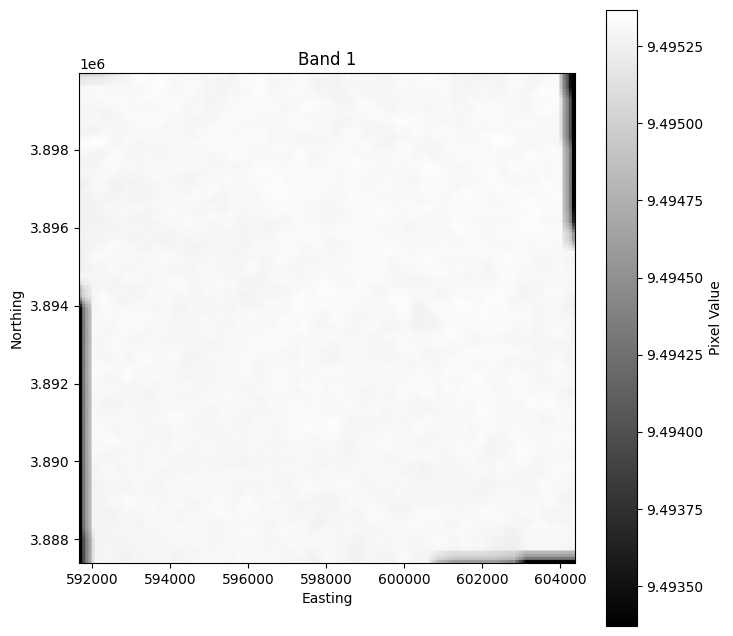

In [121]:
import rasterio
import matplotlib.pyplot as plt

# Path to your raster
ref_raster_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed_v2.tif"

# Open the raster
with rasterio.open(ref_raster_path) as src:
    print("Raster info:")
    print(f"Width: {src.width}, Height: {src.height}, Bands: {src.count}")
    print(f"CRS: {src.crs}")

    # Read the first band
    band1 = src.read(1)

    # Optional: get extent for proper axis labeling
    extent = [
        src.bounds.left, src.bounds.right,
        src.bounds.bottom, src.bounds.top
    ]

# Plot the first band
plt.figure(figsize=(8,8))
plt.imshow(band1, cmap='gray', extent=extent)
plt.title("Band 1")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.colorbar(label="Pixel Value")
plt.show()


11/29 dev^

In [ ]:
# ## -----------------------------
# # Stage-3: Full inference with Stage-2 fusion + diagnostics
# # -----------------------------
# import os, re, math, time
# from glob import glob
# from collections import defaultdict

# import numpy as np
# import rasterio
# from rasterio.transform import Affine
# from tqdm import tqdm
# from scipy import ndimage
# import torch
# import torch.nn as nn

# # ------------------- CONFIG -------------------
# PATCH_SIZE = 32
# OVERLAP = 0.75
# STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))
# REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
# PATCH_FOLDER = "/content/EO_inference_folder"
# OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed.tif"

# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# BANDS_PER_COV = {
#     's1':4,'s2':6,'s2idx':8,'landsat':6,'landsatidx':7,
#     'hls':7,'tcap':6,'dem':2
# }
# SPATIAL_RES = {'s1':10,'s2':20,'s2idx':20,'landsat':30,'landsatidx':30,
#                'hls':30,'tcap':30,'dem':30}

# ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
# FUSION_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor_attn.pth"

# # smoothing params
# TOKEN_GAUSSIAN_SIGMA_PIX = 0.8
# PATCH_GAUSSIAN_SIGMA = 0.8
# CLIP_NEGATIVE_TO_ZERO = True

# # ViT geometry (matches Stage2)
# PATCH_EMBED_PATCH = 4
# TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH  # 8
# TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
# EMBED_DIM = 128

# # Device
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Running Stage 3 on device:", device)

# # ------------------- Stage-1 encoder (ViT) -------------------
# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
#         super().__init__()
#         self.patch_size = patch_size
#         self.num_patches = (img_size // patch_size) ** 2
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         x = self.proj(x)
#         x = x.flatten(2).transpose(1,2)
#         return x

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self,x):
#         x_norm = self.norm1(x)
#         attn_out,_ = self.attn(x_norm, x_norm, x_norm)
#         x = x + attn_out
#         x = x + self.mlp(self.norm2(x))
#         return x

# class ViTCustom(nn.Module):
#     def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
#         super().__init__()
#         self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
#         self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
#         self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
#         self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
#         self.norm = nn.LayerNorm(embed_dim)
#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat([cls_tokens, x], dim=1)
#         x = x + self.pos_embed
#         x = x.transpose(0,1)
#         for blk in self.blocks:
#             x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         return x[:,1:]   # return tokens only

# # ------------------- Stage-2 Fusion -------------------
# class ModalityFusionTransformer(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=3, dim_feedforward=512, dropout=0.1, max_pos=2048):
#         super().__init__()
#         self.embed_dim = embed_dim
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)
#         self.pos_emb = nn.Embedding(max_pos, embed_dim)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
#                                                    dim_feedforward=dim_feedforward,
#                                                    dropout=dropout, activation='gelu',
#                                                    batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
#         self.norm = nn.LayerNorm(embed_dim)
#         self.head = nn.Linear(embed_dim, 1)
#         nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)
#     def forward(self, x, seg_ids, mask):
#         B, T, D = x.shape
#         pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
#         pos_emb = self.pos_emb(pos_idx)
#         seg_ids_clamped = seg_ids.clone()
#         seg_ids_clamped[seg_ids_clamped < 0] = 0
#         mod_emb = self.mod_emb(seg_ids_clamped)
#         pos_emb = pos_emb * mask.unsqueeze(-1).float()
#         mod_emb = mod_emb * mask.unsqueeze(-1).float()
#         x = x + mod_emb + pos_emb
#         key_padding_mask = ~mask
#         x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
#         x_enc = self.norm(x_enc)
#         token_logits = self.head(x_enc).squeeze(-1)
#         return token_logits

# # ------------------- Load encoders -------------------
# encoder_paths = {eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST}
# encoders = {}
# # for eo in EO_LIST:
# #     path = encoder_paths[eo]
# #     ck = torch.load(path, map_location=device)
# #     enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
# #     state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
# #     enc.load_state_dict(state_dict)
# #     enc.to(device).eval()
# #     encoders[eo] = enc
# # print("Loaded encoders:", list(encoders.keys()))


# for eo in EO_LIST:
#     path = encoder_paths[eo]
#     if not os.path.exists(path):
#         raise FileNotFoundError(f"Encoder file not found for {eo}: {path}")
#     ck = torch.load(path, map_location=device)
#     enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
#     state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
#     enc.load_state_dict(state_dict)
#     enc.to(device).eval()
#     encoders[eo] = enc
# print("Loaded encoders:", list(encoders.keys()))

# # ------------------- Load Stage-2 fusion -------------------
# fusion_ckpt = torch.load(FUSION_MODEL_PATH, map_location=device)
# fusion_model = ModalityFusionTransformer(embed_dim=EMBED_DIM, num_modalities=len(EO_LIST),
#                                          nhead=4, nlayers=3, dim_feedforward=512,
#                                          dropout=0.1, max_pos=2048).to(device)
# state_dict = fusion_ckpt["model_state_dict"] if isinstance(fusion_ckpt, dict) and "model_state_dict" in fusion_ckpt else fusion_ckpt
# fusion_model.load_state_dict(state_dict)
# fusion_model.eval()
# print("Loaded Stage-2 fusion model:", FUSION_MODEL_PATH)

# # ------------------- Torchinfo summaries -------------------
# # try:
# #     from torchinfo import summary
# #     print("\n--- Encoder summaries ---")
# #     for eo in EO_LIST:
# #         c = BANDS_PER_COV[eo]
# #         dummy = torch.randn(1,c,PATCH_SIZE,PATCH_SIZE).to(device)
# #         summary(encoders[eo], input_data=dummy, col_names=("input_size","output_size","num_params"), verbose=0)
# #     total_tokens = TOKENS_PER_MODALITY * len(EO_LIST)
# #     dummy_tokens = torch.randn(1,total_tokens,EMBED_DIM).to(device)
# #     dummy_mask = torch.ones(1,total_tokens,dtype=torch.bool).to(device)
# #     print("\n--- Fusion summary ---")
# #     summary(fusion_model, input_data=(dummy_tokens, dummy_mask), col_names=("input_size","output_size","num_params"), verbose=0)
# # except Exception as e:
# #     print("Torchinfo summary failed:", e)

# # ------------------- Model summaries & Stage-3 fusion diagnostic (REPLACE previous summary/diag block) -------------------

# try:
#     from torchinfo import summary
#     have_torchinfo = True
# except Exception:
#     have_torchinfo = False

# # --- Prepare realistic dummy inputs (on same device) ---
# total_tokens = TOKENS_PER_MODALITY * len(EO_LIST)   # e.g. 64 * 8 = 512
# print(f"Prepared summary inputs: total_tokens={total_tokens}, embed_dim={EMBED_DIM}, device={device}")

# # Dummy mask for full-valid sequence
# dummy_mask = torch.ones(1, total_tokens, dtype=torch.bool).to(device)

# # Build dummy seg_ids: repeating modality indices for each modality's tokens
# seg_ids_list = []
# for m_idx in range(len(EO_LIST)):
#     seg_ids_list.append(torch.full((TOKENS_PER_MODALITY,), m_idx, dtype=torch.long))
# seg_ids_tensor = torch.cat(seg_ids_list, dim=0).unsqueeze(0).to(device)   # shape [1, total_tokens]

# # --- Encoder summaries (one per EO) ---
# print("\n--- Encoder summaries (real shapes) ---")
# for eo in EO_LIST:
#     try:
#         c = BANDS_PER_COV[eo]
#         dummy_input = torch.randn(1, c, PATCH_SIZE, PATCH_SIZE).to(device)
#         print(f"\nEncoder: {eo}  (input channels={c})")
#         if have_torchinfo:
#             try:
#                 # show only small summary columns to avoid huge output
#                 summary(encoders[eo], input_data=dummy_input, col_names=("input_size","output_size","num_params"), verbose=0)
#             except Exception as e:
#                 print("  torchinfo.summary for encoder failed:", e)
#                 # fallback: run a forward to show output shape
#                 with torch.no_grad():
#                     out = encoders[eo](dummy_input)
#                 print("  Forward OK — encoder output shape:", tuple(out.shape))
#         else:
#             with torch.no_grad():
#                 out = encoders[eo](dummy_input)
#             print("  torchinfo not available. Encoder forward OK — output shape:", tuple(out.shape))
#     except Exception as e:
#         print(f"  ERROR running encoder summary for {eo}: {e}")

# # --- Fusion model summary (correct input signature: x, seg_ids, mask) ---
# print("\n--- Fusion model summary (Token-level fusion) ---")
# try:
#     dummy_tokens = torch.randn(1, total_tokens, EMBED_DIM).to(device)  # [1, T, D]
#     if have_torchinfo:
#         try:
#             # pass the required 3-tuple (x, seg_ids, mask)
#             summary(fusion_model,
#                     input_data=(dummy_tokens, seg_ids_tensor, dummy_mask),
#                     col_names=("input_size","output_size","num_params"),
#                     verbose=0)
#         except Exception as e:
#             print("  torchinfo.summary for fusion model failed:", e)
#             # fallback: run forward and print shapes
#             with torch.no_grad():
#                 out = fusion_model(dummy_tokens, seg_ids_tensor, dummy_mask)
#             print("  Forward OK — fusion output shape:", tuple(out.shape))
#     else:
#         with torch.no_grad():
#             out = fusion_model(dummy_tokens, seg_ids_tensor, dummy_mask)
#         print("  torchinfo not available. Fusion forward OK — output shape:", tuple(out.shape))
# except Exception as e:
#     print("  ERROR preparing fusion model summary:", e)

# # --- Stage-3 Fusion Diagnostic (uses realistic dummy per-modality tokens) ---
# print("\n--- Stage 3 Fusion Diagnostic (realistic token arrangement) ---")
# try:
#     # Build per-modality dummy tokens and concat across modalities in EO_LIST order
#     example_tokens = []
#     for eo_idx, eo in enumerate(EO_LIST):
#         # shape [1, TOKENS_PER_MODALITY, EMBED_DIM]
#         t = torch.randn(1, TOKENS_PER_MODALITY, EMBED_DIM).to(device)
#         example_tokens.append(t)

#     # concat along token axis -> [1, total_tokens, EMBED_DIM]
#     tokens_stack = torch.cat(example_tokens, dim=1).to(device)

#     # Build seg_ids matching this concatenation: [1, total_tokens]
#     seg_ids_example = torch.cat([torch.full((1, TOKENS_PER_MODALITY), i, dtype=torch.long) for i in range(len(EO_LIST))], dim=1).to(device)
#     mask_example = torch.ones(1, total_tokens, dtype=torch.bool).to(device)

#     # Run the fusion model correctly with seg_ids and mask
#     with torch.no_grad():
#         token_preds = fusion_model(tokens_stack, seg_ids_example, mask_example)   # [1, total_tokens]

#     # Diagnostics output
#     token_preds_np = token_preds.squeeze(0).cpu().numpy()
#     sample_pred = float(token_preds_np.mean())
#     print("Per-modality token shapes (tokens, embed_dim):")
#     for eo in EO_LIST:
#         print(f"  {eo:12s}: tokens = {TOKENS_PER_MODALITY}, embed_dim = {EMBED_DIM}")
#     print("\nBatch fused sequence shape (token preds):", tuple(token_preds.shape))
#     print(f"Example per-sample scalar prediction (avg valid tokens={total_tokens}): {sample_pred:.4f}")

# except Exception as e:
#     print("Stage-3 fusion diagnostic failed:", e)

# print("\n--- End of summaries & diagnostic ---\n")



# # ------------------- Diagnostic example -------------------
# with torch.no_grad():
#     example_tokens = []
#     start_idx = 0
#     for eo in EO_LIST:
#         dummy_tok = torch.randn(1,TOKENS_PER_MODALITY,EMBED_DIM).to(device)
#         example_tokens.append(dummy_tok)
#         start_idx += TOKENS_PER_MODALITY
#     tokens_stack = torch.cat(example_tokens, dim=1)
#     mask = torch.ones(1,tokens_stack.shape[1],dtype=torch.bool).to(device)
#     token_preds = fusion_model(tokens_stack, mask=mask)
#     sample_pred = float(token_preds.mean())
#     print("\n==================== Stage 3 Fusion Diagnostic ====================")
#     for idx, eo in enumerate(EO_LIST):
#         print(f"{eo:12s}: tokens={TOKENS_PER_MODALITY}, embed_dim={EMBED_DIM}")
#     print("Batch fused sequence shape (after Transformer head):", token_preds.shape)
#     print(f"Example per-sample scalar prediction (avg over tokens) = {sample_pred:.4f}")
#     print("===================================================================")

# # ------------------- Stage-3 accumulation / inference would follow here -------------------


In [ ]:
# ## -----------------------------
# # Stage-3: Full inference with Stage-2 fusion + smooth 10m output
# # -----------------------------
# import os, math
# from glob import glob
# import numpy as np
# import rasterio
# from rasterio.transform import Affine
# from tqdm import tqdm
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from scipy.ndimage import gaussian_filter

# # ------------------- CONFIG -------------------
# PATCH_SIZE = 32
# OVERLAP = 0.75
# STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))

# PATCH_EMBED_PATCH = 4
# TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH  # 8
# TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
# EMBED_DIM = 128

# REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
# PATCH_FOLDER = "/content/EO_inference_folder"
# OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed.tif"

# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# eo_map = {
#     "s1Ascending": "s1",
#     "S2Composite": "s2",
#     "S2Indices": "s2idx",
#     "DEMindices": "dem",
#     "landsatTasseledCapIndices": "tcap",
#     "HLS": "hls",
#     "LandsatComposite": "landsat",
#     "LandsatIndices": "landsatidx",
# }
# SPATIAL_RES = {'s1':10,'s2':20,'s2idx':20,'landsat':30,'landsatidx':30,
#                'hls':30,'tcap':30,'dem':30}
# BANDS_PER_COV = {'s1':4,'s2':6,'s2idx':8,'landsat':6,'landsatidx':7,
#                  'hls':7,'tcap':6,'dem':2}

# ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
# FUSION_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor_attn.pth"

# CLIP_MIN, CLIP_MAX = 0.0, 35.0
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print("Running Stage 3 on device:", DEVICE)

# # ------------------- Stage-1 encoder (ViT) -------------------
# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
#         super().__init__()
#         self.patch_size = patch_size
#         self.num_patches = (img_size // patch_size) ** 2
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         x = self.proj(x)
#         x = x.flatten(2).transpose(1,2)
#         return x

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self,x):
#         x_norm = self.norm1(x)
#         attn_out,_ = self.attn(x_norm, x_norm, x_norm)
#         x = x + attn_out
#         x = x + self.mlp(self.norm2(x))
#         return x

# class ViTCustom(nn.Module):
#     def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
#         super().__init__()
#         self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
#         self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
#         self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
#         self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
#         self.norm = nn.LayerNorm(embed_dim)
#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat([cls_tokens, x], dim=1)
#         x = x + self.pos_embed
#         x = x.transpose(0,1)
#         for blk in self.blocks: x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         return x[:,1:]  # return tokens only

# # ------------------- Stage-2 Fusion -------------------
# class ModalityFusionTransformer(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=3, dim_feedforward=512, dropout=0.1, max_pos=2048):
#         super().__init__()
#         self.embed_dim = embed_dim
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)
#         self.pos_emb = nn.Embedding(max_pos, embed_dim)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
#                                                    dim_feedforward=dim_feedforward,
#                                                    dropout=dropout, activation='gelu',
#                                                    batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
#         self.norm = nn.LayerNorm(embed_dim)
#         self.head = nn.Linear(embed_dim, 1)
#         nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)
#     def forward(self, x, seg_ids, mask):
#         B, T, D = x.shape
#         pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B,T)
#         pos_emb = self.pos_emb(pos_idx)
#         seg_ids_clamped = seg_ids.clone()
#         seg_ids_clamped[seg_ids_clamped < 0] = 0
#         mod_emb = self.mod_emb(seg_ids_clamped)
#         x = x + mod_emb + pos_emb
#         key_padding_mask = ~mask
#         x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
#         x_enc = self.norm(x_enc)
#         token_logits = self.head(x_enc).squeeze(-1)
#         return token_logits

# # ------------------- Load encoders -------------------
# encoder_paths = {eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST}
# encoders = {}
# for eo in EO_LIST:
#     ck = torch.load(encoder_paths[eo], map_location=DEVICE)
#     enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
#     state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
#     enc.load_state_dict(state_dict)
#     enc.to(DEVICE).eval()
#     encoders[eo] = enc
# print("Loaded encoders and fusion model.")

# # ------------------- Load Stage-2 fusion -------------------
# fusion_ckpt = torch.load(FUSION_MODEL_PATH, map_location=DEVICE)
# fusion_model = ModalityFusionTransformer(embed_dim=EMBED_DIM, num_modalities=len(EO_LIST)).to(DEVICE)
# state_dict = fusion_ckpt["model_state_dict"] if isinstance(fusion_ckpt, dict) and "model_state_dict" in ck else fusion_ckpt
# fusion_model.load_state_dict(state_dict)
# fusion_model.eval()

# # ------------------- Inference -------------------
# # Read reference raster to get shape/transform
# with rasterio.open(REFERENCE_RASTER) as ref:
#     H, W = ref.height, ref.width
#     transform = ref.transform
#     crs = ref.crs

# # Initialize accumulation arrays
# out_pred = np.zeros((H,W), dtype=np.float32)
# weight_sum = np.zeros((H,W), dtype=np.float32)

# # Build seg_ids for fusion
# seg_ids_tensor = torch.cat([torch.full((TOKENS_PER_MODALITY,), i, dtype=torch.long) for i in range(len(EO_LIST))], dim=0).unsqueeze(0).to(DEVICE)

# # Loop over patches
# for i in tqdm(range(0,H,PATCH_SIZE)):
#     for j in range(0,W,PATCH_SIZE):
#         patch_tokens = []
#         for prefix, eo in eo_map.items():
#             files = sorted(glob(os.path.join(PATCH_FOLDER, f"{prefix}*")))
#             if len(files)==0:
#                 raise FileNotFoundError(f"No EO files found for {prefix} in {PATCH_FOLDER}")
#             patch_array = np.array(rasterio.open(files[0]).read(window=rasterio.windows.Window(j,i,PATCH_SIZE,PATCH_SIZE)), dtype=np.float32)
#             patch_tensor = torch.tensor(patch_array[np.newaxis,...], dtype=torch.float32).to(DEVICE)
#             with torch.no_grad():
#                 tokens = encoders[eo](patch_tensor)
#             patch_tokens.append(tokens)
#         # Concatenate tokens along token dimension
#         tokens_stack = torch.cat(patch_tokens, dim=1)  # [1, total_tokens, embed_dim]
#         mask_tensor = torch.ones(1, tokens_stack.shape[1], dtype=torch.bool).to(DEVICE)
#         with torch.no_grad():
#             token_preds = fusion_model(tokens_stack, seg_ids_tensor, mask_tensor)  # [1, total_tokens]
#         token_preds = token_preds.cpu().numpy().reshape(len(EO_LIST), TOKENS_PER_ROW, TOKENS_PER_ROW)
#         # Average across modalities
#         token_mean = token_preds.mean(axis=0)  # [TOKENS_PER_ROW, TOKENS_PER_ROW]
#         # Upsample to PATCH_SIZE x PATCH_SIZE
#         patch_pred = F.interpolate(torch.tensor(token_mean[None,None,...]), size=(PATCH_SIZE,PATCH_SIZE), mode='bilinear', align_corners=False)
#         patch_pred = patch_pred.squeeze().numpy()
#         # Gaussian smoothing
#         patch_pred = gaussian_filter(patch_pred, sigma=0.8)
#         # Accumulate
#         h_end = min(i+PATCH_SIZE,H)
#         w_end = min(j+PATCH_SIZE,W)
#         out_pred[i:h_end,j:w_end] += patch_pred[:h_end-i,:w_end-j]
#         weight_sum[i:h_end,j:w_end] += 1.0

# # Normalize by weights
# out_pred /= np.maximum(weight_sum,1e-6)
# out_pred = np.clip(out_pred, CLIP_MIN, CLIP_MAX)

# # Write final raster
# os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
# with rasterio.open(
#     OUT_TIF, 'w',
#     driver='GTiff',
#     height=H, width=W,
#     count=1, dtype=np.float32,
#     crs=crs,
#     transform=transform
# ) as dst:
#     dst.write(out_pred,1)

# print(f"Stage 3 inference complete. Output saved to {OUT_TIF}")


In [ ]:
# import rasterio
# import matplotlib.pyplot as plt

# # Path to your raster
# ref_raster_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed.tif"

# # Open the raster
# with rasterio.open(ref_raster_path) as src:
#     print("Raster info:")
#     print(f"Width: {src.width}, Height: {src.height}, Bands: {src.count}")
#     print(f"CRS: {src.crs}")

#     # Read the first band
#     band1 = src.read(1)

#     # Optional: get extent for proper axis labeling
#     extent = [
#         src.bounds.left, src.bounds.right,
#         src.bounds.bottom, src.bounds.top
#     ]

# # Plot the first band
# plt.figure(figsize=(8,8))
# plt.imshow(band1, cmap='gray', extent=extent)
# plt.title("Band 1")
# plt.xlabel("Easting")
# plt.ylabel("Northing")
# plt.colorbar(label="Pixel Value")
# plt.show()


In [ ]:
# # =========================================================
# #   FULL STAGE-3 MODEL SUMMARY (REAL EO CHANNELS)
# # =========================================================

# import torch
# import torch.nn as nn
# from torchinfo import summary

# # ---------------------------------------------------------
# # CONFIG
# # ---------------------------------------------------------
# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

# BANDS_PER_COV = {
#     's1': 4, 's2': 6, 's2idx': 8,
#     'landsat': 6, 'landsatidx': 7,
#     'hls': 7, 'tcap': 6, 'dem': 2
# }

# PATCH_SIZE = 32
# PATCH_EMBED = 4            # Stage-1 ViT patch size
# EMBED_DIM = 128
# DEPTH = 4
# HEADS = 4


# # =========================================================
# # 1) Stage-1 Encoder (your ViTCustom)
# # =========================================================

# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels, patch_size, embed_dim, img_size):
#         super().__init__()
#         self.patch = patch_size
#         self.proj = nn.Conv2d(in_channels, embed_dim,
#                               kernel_size=patch_size,
#                               stride=patch_size)
#         self.num_patches = (img_size // patch_size) ** 2

#     def forward(self, x):
#         # B,C,H,W → B,Embed,N
#         x = self.proj(x)                      # [B,128,8,8]
#         x = x.flatten(2).transpose(1,2)       # [B,64,128]
#         return x


# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim, num_heads, mlp_ratio=2.0):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         hidden = int(embed_dim * mlp_ratio)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, hidden),
#             nn.GELU(),
#             nn.Linear(hidden, embed_dim)
#         )

#     def forward(self, x):
#         x2 = self.norm1(x)
#         attn_out,_ = self.attn(x2, x2, x2)
#         x = x + attn_out
#         x2 = self.norm2(x)
#         x = x + self.mlp(x2)
#         return x


# class ViTCustom(nn.Module):
#     def __init__(self, in_channels):
#         super().__init__()
#         self.patch_embed = PatchEmbed(
#             in_channels=in_channels,
#             patch_size=PATCH_EMBED,
#             embed_dim=EMBED_DIM,
#             img_size=PATCH_SIZE
#         )
#         N = self.patch_embed.num_patches  # 64 tokens

#         self.cls = nn.Parameter(torch.zeros(1,1,EMBED_DIM))
#         self.pos = nn.Parameter(torch.zeros(1, N+1, EMBED_DIM))

#         self.blocks = nn.ModuleList([
#             TransformerBlock(EMBED_DIM, HEADS)
#             for _ in range(DEPTH)
#         ])
#         self.norm = nn.LayerNorm(EMBED_DIM)

#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)
#         cls = self.cls.expand(B,-1,-1)
#         x = torch.cat([cls,x], dim=1)
#         x = x + self.pos
#         x = x.transpose(0,1)
#         for blk in self.blocks:
#             x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         return x[:,1:]   # return 64 tokens only


# # =========================================================
# # 2) Stage-2 Fusion Model
# # =========================================================
# class TokenAttentionRegressor(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.attn = nn.MultiheadAttention(EMBED_DIM, HEADS, batch_first=True)
#         self.norm = nn.LayerNorm(EMBED_DIM)
#         self.head = nn.Linear(EMBED_DIM, 1)

#     def forward(self, x):
#         out,_ = self.attn(x,x,x)
#         x = self.norm(out + x)
#         return self.head(x).squeeze(-1)   # [B, tokens]


# # =========================================================
# # 3) FULL STAGE-3 MODULE (ENCODERS + FUSION)
# # =========================================================
# class FullStage3Wrapper(nn.Module):
#     """
#     This module wraps ALL Stage-1 encoders and the Stage-2 fusion model.

#     Input:
#         - A dictionary of EO tensors (one per modality)
#           or a stacked tensor [B, ΣC, H, W] for summary.
#     """

#     def __init__(self):
#         super().__init__()

#         # Build encoders for each EO type
#         self.enc = nn.ModuleDict({
#             eo: ViTCustom(in_channels=BANDS_PER_COV[eo])
#             for eo in EO_LIST
#         })

#         # Stage 2 fusion
#         self.fusion = TokenAttentionRegressor()

#     def forward(self, x):
#         """
#         x = dict: {'s1': tensor[B,4,32,32], 's2': tensor[B,6,32,32], ...}
#         For model summary, we pass a fake unified tensor.
#         """

#         # x will be a dict in real inference.
#         # Here, torchinfo passes a single tensor
#         # so we manually split it.
#         split_inputs = {}
#         idx = 0
#         for eo in EO_LIST:
#             b = BANDS_PER_COV[eo]
#             split_inputs[eo] = x[:, idx:idx+b]
#             idx += b

#         # Encode each modality
#         tok_list = []
#         for eo in EO_LIST:
#             tok = self.enc[eo](split_inputs[eo])   # [B,64,128]
#             tok_list.append(tok)

#         # concat tokens from all EO
#         all_tokens = torch.cat(tok_list, dim=1)     # [B, 64*8, 128]

#         # Stage-2 fusion
#         preds = self.fusion(all_tokens)             # [B,512]
#         return preds


# # =========================================================
# #   RUN TORCHINFO SUMMARY
# # =========================================================

# # Build model
# model = FullStage3Wrapper()

# # Build one fake input representing ALL EO together
# total_channels = sum(BANDS_PER_COV.values())
# dummy = torch.zeros(1, total_channels, PATCH_SIZE, PATCH_SIZE)

# summary(model, input_data=dummy, depth=5, col_names=["kernel_size","num_params","mult_adds"])


In [ ]:
# # Full Stage-3: token-splat + Gaussian blending (single runnable block)
# # Paste & run in the notebook cell (assumes encoders & fusion .pth exist).
# import os, re, math, time
# from glob import glob
# from collections import defaultdict

# import numpy as np
# import rasterio
# from rasterio.transform import Affine
# from tqdm import tqdm
# from scipy import ndimage
# import torch
# import torch.nn as nn

# # ------------------- CONFIG (edit if needed) -------------------
# PATCH_SIZE = 32                # input patch size used to create inference TIFFs
# OVERLAP = 0.75                 # your chosen overlap
# STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))   # expected 8
# REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
# PATCH_FOLDER = "/content/EO_inference_folder"
# OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed.tif"

# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# eo_map = {
#     "s1Ascending": "s1",
#     "S2Composite": "s2",
#     "S2Indices": "s2idx",
#     "DEMindices": "dem",
#     "landsatTasseledCapIndices": "tcap",
#     "HLS": "hls",
#     "LandsatComposite": "landsat",
#     "LandsatIndices": "landsatidx",
# }
# SPATIAL_RES = {
#     's1': 10, 's2': 20, 's2idx': 20,
#     'landsat': 30, 'landsatidx': 30,
#     'hls': 30, 'tcap': 30, 'dem': 30
# }
# BANDS_PER_COV = {
#     's1': 4, 's2': 6, 's2idx': 8,
#     'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
# }

# ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
# encoder_paths = { eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST }
# FUSION_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor.pth"

# # smoothing params (tweak)
# TOKEN_GAUSSIAN_SIGMA_PIX = 0.8   # sigma in reference pixels for token splat
# PATCH_GAUSSIAN_SIGMA = 0.8       # light global smoothing at the end
# CLIP_NEGATIVE_TO_ZERO = True

# # ViT geometry (matches Stage1)
# PATCH_EMBED_PATCH = 4            # ViT patch size within 32x32 patch
# TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH   # 8
# TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
# EMBED_DIM = 128

# # Device
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Running Stage 3 on device:", device)

# # ------------------- Stage1/Stage2 class definitions (must match training code) -------------------
# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
#         super().__init__()
#         self.patch_size = patch_size
#         self.num_patches = (img_size // patch_size) ** 2
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         x = self.proj(x)
#         x = x.flatten(2).transpose(1,2)
#         return x

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self,x):
#         x_norm = self.norm1(x)
#         attn_out,_ = self.attn(x_norm, x_norm, x_norm)
#         x = x + attn_out
#         x = x + self.mlp(self.norm2(x))
#         return x

# class ViTCustom(nn.Module):
#     def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
#         super().__init__()
#         self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
#         self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
#         self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
#         self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
#         self.norm = nn.LayerNorm(embed_dim)
#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)                    # [B, num_patches, embed_dim]
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat([cls_tokens, x], dim=1)
#         x = x + self.pos_embed
#         x = x.transpose(0,1)
#         for blk in self.blocks:
#             x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         return x[:,1:]   # return tokens only: [B, num_patches, embed_dim]

# class TokenAttentionRegressor(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, dropout=0.0):
#         super().__init__()
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
#         self.norm = nn.LayerNorm(embed_dim)
#         self.head = nn.Linear(embed_dim, 1)
#         self.dropout = nn.Dropout(dropout)
#     def forward(self, x, mask=None):
#         # x: [B, T, D], mask: [B, T]
#         attn_out, _ = self.attn(x, x, x, key_padding_mask=~mask if (mask is not None) else None)
#         x = self.norm(attn_out + x)
#         x = self.dropout(x)
#         token_logits = self.head(x).squeeze(-1)   # [B, T]
#         return token_logits

# # ------------------- utility functions -------------------
# def gaussian_kernel_2d(h, w, sigma):
#     """2D gaussian normalized to sum=1 (safe for small sizes)."""
#     if h <= 0 or w <= 0:
#         return np.zeros((0,0), dtype=np.float32)
#     y = np.arange(h) - (h-1)/2.0
#     x = np.arange(w) - (w-1)/2.0
#     yy, xx = np.meshgrid(y, x, indexing='ij')
#     g = np.exp(-(xx**2 + yy**2) / (2.0 * (sigma**2)))
#     s = g.sum()
#     if s <= 0:
#         return np.ones((h,w), dtype=np.float32) / (h*w)
#     return (g / s).astype(np.float32)

# def read_patch_as_tensor(fp, eo_key, device):
#     with rasterio.open(fp) as src:
#         arr = src.read().astype(np.float32)   # [C,H,W]
#     c_expected = BANDS_PER_COV[eo_key]
#     if arr.shape[0] != c_expected:
#         if arr.shape[0] > c_expected:
#             arr = arr[:c_expected, :, :]
#         else:
#             pad_ch = c_expected - arr.shape[0]
#             arr = np.pad(arr, ((0,pad_ch),(0,0),(0,0)), mode='constant', constant_values=0.0)
#     t = torch.from_numpy(arr).unsqueeze(0).to(device)
#     return t

# # ------------------- read reference raster -------------------
# with rasterio.open(REFERENCE_RASTER) as src:
#     ref_meta = src.meta.copy()
#     ref_h, ref_w = src.height, src.width
#     ref_transform = src.transform
#     ref_crs = src.crs

# # ------------------- scan patch files and group -------------------
# FNAME_RE = re.compile(r"(?P<eo>[^_]+)_(?P<yr>\d{4})_(?P<row>\d{4})_(?P<col>\d{4})\.tif$")
# patch_files = glob(os.path.join(PATCH_FOLDER, "*.tif"))
# if len(patch_files) == 0:
#     raise RuntimeError(f"No patch files in {PATCH_FOLDER}")

# groups = {}
# for p in patch_files:
#     fname = os.path.basename(p)
#     m = FNAME_RE.match(fname)
#     if m:
#         eo_prefix = m.group("eo")
#         row_idx = int(m.group("row"))
#         col_idx = int(m.group("col"))
#     else:
#         parts = fname.split("_")
#         if len(parts) >= 4:
#             eo_prefix = parts[0]
#             try:
#                 row_idx = int(parts[-2]); col_idx = int(parts[-1].split(".")[0])
#             except:
#                 continue
#         else:
#             continue
#     if eo_prefix not in eo_map:
#         continue
#     eo_key = eo_map[eo_prefix]
#     # convert native stride to ref 10m pixels
#     meters_per_native_stride = STRIDE_PIX * SPATIAL_RES[eo_key]
#     ref_stride_pixels = int(round(meters_per_native_stride / 10.0))
#     ref_start_row = int(round(row_idx * ref_stride_pixels))
#     ref_start_col = int(round(col_idx * ref_stride_pixels))
#     groups.setdefault((ref_start_row, ref_start_col), {})[eo_key] = p

# print("Total unique patch groups:", len(groups))

# # ------------------- load ViT encoders -------------------
# encoders = {}
# for eo in EO_LIST:
#     path = encoder_paths.get(eo)
#     if not path or not os.path.exists(path):
#         raise RuntimeError(f"Missing encoder for {eo} at {path}")
#     enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
#     ck = torch.load(path, map_location=device)
#     # handle if saved as dict or state_dict
#     if isinstance(ck, dict) and "model_state_dict" in ck:
#         state_dict = ck["model_state_dict"]
#     else:
#         state_dict = ck
#     enc.load_state_dict(state_dict)
#     enc.to(device).eval()
#     encoders[eo] = enc
# print("Loaded encoders for modalities:", list(encoders.keys()))

# # ------------------- load fusion model -------------------
# if not os.path.exists(FUSION_MODEL_PATH):
#     raise RuntimeError("Missing fusion model at: " + FUSION_MODEL_PATH)
# fusion_ckpt = torch.load(FUSION_MODEL_PATH, map_location=device)
# fusion_model = TokenAttentionRegressor(embed_dim=EMBED_DIM, num_heads=4).to(device)
# if isinstance(fusion_ckpt, dict) and "model_state_dict" in fusion_ckpt:
#     fusion_model.load_state_dict(fusion_ckpt["model_state_dict"])
# else:
#     fusion_model.load_state_dict(fusion_ckpt)
# fusion_model.eval()
# print("Loaded fusion model:", FUSION_MODEL_PATH)

# # ------------------- torchinfo summaries (real input sizes) -------------------
# try:
#     from torchinfo import summary
#     print("\n--- Model summaries (encoder + fusion) ---")
#     for eo in EO_LIST:
#         c = BANDS_PER_COV[eo]
#         dummy = torch.randn(1, c, PATCH_SIZE, PATCH_SIZE).to(device)
#         print(f"\nEncoder summary for {eo} (input channels={c}):")
#         summary(encoders[eo], input_data=dummy, col_names=("input_size","output_size","num_params"), verbose=0)
#     # fusion summary with a realistic token length (all modalities present)
#     total_tokens = TOKENS_PER_MODALITY * len(EO_LIST)
#     dummy_tokens = torch.randn(1, total_tokens, EMBED_DIM).to(device)
#     dummy_mask = torch.ones(1, total_tokens, dtype=torch.bool).to(device)
#     print("\nFusion model summary (TokenAttentionRegressor):")
#     summary(fusion_model, input_data=(dummy_tokens, dummy_mask), col_names=("input_size","output_size","num_params"), verbose=0)
# except Exception as e:
#     print("torchinfo.summary failed or not installed:", e)
#     print("You can `pip install torchinfo` to see model summaries.")

# # ------------------- prepare accumulation arrays -------------------
# pred_sum = np.zeros((ref_h, ref_w), dtype=np.float64)
# weight_sum = np.zeros((ref_h, ref_w), dtype=np.float64)

# emb_cache = {}  # filepath -> numpy [num_tokens, embed_dim]

# start_time = time.time()
# items = list(groups.items())
# pbar = tqdm(items, total=len(items), desc="Groups")

# # token footprint in reference pixels (float)
# # token_size_ref_px_by_eo gives float footprint (can be fractional) per EO
# token_size_ref_px_by_eo = { eo: (PATCH_EMBED_PATCH * SPATIAL_RES[eo]) / 10.0 for eo in EO_LIST }

# for (ref_r, ref_c), eo_files in pbar:
#     # build token sequence in EO_LIST order (each modality contributes TOKENS_PER_MODALITY tokens)
#     tokens_list = []
#     token_slices = []
#     start_idx = 0
#     for eo in EO_LIST:
#         if eo in eo_files:
#             fp = eo_files[eo]
#             if fp in emb_cache:
#                 emb_np = emb_cache[fp]
#             else:
#                 try:
#                     pt = read_patch_as_tensor(fp, eo, device)   # [1,C,H,W]
#                     with torch.no_grad():
#                         emb_t = encoders[eo](pt)   # [1, num_tokens, embed_dim]
#                     emb_np = emb_t.squeeze(0).cpu().numpy()
#                     emb_cache[fp] = emb_np
#                 except Exception as e:
#                     print(f"Warning: failed to embed {fp}: {e}")
#                     emb_np = np.zeros((TOKENS_PER_MODALITY, EMBED_DIM), dtype=np.float32)
#                     emb_cache[fp] = emb_np
#         else:
#             emb_np = np.zeros((TOKENS_PER_MODALITY, EMBED_DIM), dtype=np.float32)

#         tokens_list.append(torch.from_numpy(emb_np).to(device))
#         token_slices.append((eo, start_idx, start_idx + TOKENS_PER_MODALITY))
#         start_idx += TOKENS_PER_MODALITY

#     tokens_stack = torch.cat(tokens_list, dim=0).unsqueeze(0).to(device)  # [1, T_total, EMBED_DIM]
#     mask = torch.ones(1, tokens_stack.shape[1], dtype=torch.bool).to(device)

#     with torch.no_grad():
#         token_preds = fusion_model(tokens_stack, mask=mask)   # [1, T_total]
#     token_preds = token_preds.squeeze(0).cpu().numpy()   # shape (T_total,)

#     # For each modality, transform its token preds into token grid and splat onto ref grid
#     for (eo, si, ei) in token_slices:
#         eo_preds = token_preds[si:ei]   # length TOKENS_PER_MODALITY
#         token_grid = eo_preds.reshape((TOKENS_PER_ROW, TOKENS_PER_ROW))

#         # token size (in reference px) (float)
#         token_size_ref_px = token_size_ref_px_by_eo[eo]
#         # kernel integer size (at least 1). Use at least 1 px, and make odd kernel sizes to center nicely
#         k = max(1, int(round(token_size_ref_px)))
#         # ensure odd kernel for symmetry if k>1
#         if k % 2 == 0 and k>1:
#             k += 1

#         # loop tokens
#         for r in range(TOKENS_PER_ROW):
#             for c in range(TOKENS_PER_ROW):
#                 val = float(token_grid[r, c])
#                 # center of token in ref-pixels (float). Use (r + 0.5) to center token cell
#                 center_y = ref_r + (r + 0.5) * token_size_ref_px
#                 center_x = ref_c + (c + 0.5) * token_size_ref_px

#                 # compute integer window (centered)
#                 half_h = (k - 1) / 2.0
#                 half_w = (k - 1) / 2.0
#                 y0 = int(math.floor(center_y - half_h))
#                 x0 = int(math.floor(center_x - half_w))
#                 y1 = y0 + k
#                 x1 = x0 + k

#                 # Clip to raster bounds and compute kernel slice indices
#                 if y1 <= 0 or x1 <= 0 or y0 >= ref_h or x0 >= ref_w:
#                     # completely outside
#                     continue
#                 ky0 = 0; kx0 = 0
#                 ky1 = k; kx1 = k
#                 if y0 < 0:
#                     ky0 = -y0
#                     y0 = 0
#                 if x0 < 0:
#                     kx0 = -x0
#                     x0 = 0
#                 if y1 > ref_h:
#                     ky1 = k - (y1 - ref_h)
#                     y1 = ref_h
#                 if x1 > ref_w:
#                     kx1 = k - (x1 - ref_w)
#                     x1 = ref_w

#                 h_sel = y1 - y0
#                 w_sel = x1 - x0
#                 if h_sel <= 0 or w_sel <= 0:
#                     continue

#                 kernel = gaussian_kernel_2d(k, k, sigma=max(0.5, TOKEN_GAUSSIAN_SIGMA_PIX))
#                 # slice kernel to fit clipped window
#                 kernel_sel = kernel[ky0:ky1, kx0:kx1]
#                 if kernel_sel.size == 0:
#                     continue

#                 # weighted accumulate
#                 pred_sum[y0:y1, x0:x1] += val * kernel_sel
#                 weight_sum[y0:y1, x0:x1] += kernel_sel

#     # (optional) update progress description
#     if pbar.n % 500 == 0:
#         pbar.set_postfix_str(f"processed {pbar.n}/{len(items)} groups")

# # ------------------- normalize and finalize -------------------
# print("Normalizing accumulated predictions ...")
# eps = 1e-12
# valid_mask = weight_sum > eps
# pred_final = np.full((ref_h, ref_w), np.nan, dtype=np.float32)
# pred_final[valid_mask] = (pred_sum[valid_mask] / weight_sum[valid_mask]).astype(np.float32)

# # fill remaining NaNs using nearest neighbor
# nan_mask = np.isnan(pred_final)
# if np.any(nan_mask):
#     print("Filling holes (nearest neighbor) ...")
#     _, inds = ndimage.distance_transform_edt(nan_mask, return_distances=True, return_indices=True)
#     inds = inds.astype(int)
#     yi = inds[0]; xi = inds[1]
#     filled = pred_final[yi, xi]
#     pred_final[nan_mask] = filled[nan_mask]

# # optional light global smoothing
# if PATCH_GAUSSIAN_SIGMA is not None and PATCH_GAUSSIAN_SIGMA > 0:
#     print("Applying light global gaussian smoothing ...")
#     pred_final = ndimage.gaussian_filter(pred_final, sigma=PATCH_GAUSSIAN_SIGMA)

# if CLIP_NEGATIVE_TO_ZERO:
#     pred_final = np.maximum(pred_final, 0.0)

# # ------------------- save GeoTIFF -------------------
# os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
# out_meta = ref_meta.copy()
# out_meta.update({
#     "driver": "GTiff",
#     "height": ref_h,
#     "width": ref_w,
#     "count": 1,
#     "dtype": "float32",
#     "crs": ref_crs,
#     "transform": ref_transform
# })
# with rasterio.open(OUT_TIF, "w", **out_meta) as dst:
#     dst.write(pred_final, 1)

# print("✅ Stage 3 RH raster saved:", OUT_TIF)
# print("Time elapsed (s):", time.time() - start_time)


In [ ]:
#11/26

# # ----------------------------
# # Stage 3: Robust grouped inference + reconstruction
# # ----------------------------
# import os, re, math
# import numpy as np
# import rasterio
# from glob import glob
# from tqdm import tqdm
# from scipy import ndimage
# import torch

# # ---------- CONFIG (adjust if different) ----------
# PATCH_SIZE = 32              # patch pixels (per patch file)
# OVERLAP = 0.25               # 25% overlap used during patch creation
# REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
# PATCH_FOLDER = "/content/EO_inference_folder"
# OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction.tif"

# # EO lists / spatial resolution (must match your stage1 config)
# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# SPATIAL_RES = {
#     's1': 10, 's2': 20, 's2idx': 20,
#     'landsat': 30, 'landsatidx': 30,
#     'hls': 30, 'tcap': 30, 'dem': 30
# }

# # regex to parse filenames: EO_YYYY_ROW_COL.tif (row/col zero-padded)
# FNAME_RE = re.compile(r"(?P<eo>[^_]+)_(?P<yr>\d{4})_(?P<row>\d{4})_(?P<col>\d{4})\.tif$")

# # ---------- Read reference raster metadata ----------
# with rasterio.open(REFERENCE_RASTER) as src:
#     ref_meta = src.meta.copy()
#     ref_h, ref_w = src.height, src.width
#     ref_transform = src.transform
#     ref_crs = src.crs

# # ---------- Precompute native stride (in native pixels) ----------
# native_stride = int(round(PATCH_SIZE * (1.0 - OVERLAP)))  # e.g., 24 for 25% overlap

# # ---------- Scan patch files and map to reference start coords ----------
# patch_files = glob(os.path.join(PATCH_FOLDER, "*.tif"))
# if len(patch_files) == 0:
#     raise RuntimeError(f"No patch files found in {PATCH_FOLDER}")

# # dict mapping (ref_row, ref_col) -> { eo_key: filepath, ... }
# groups = {}

# for p in patch_files:
#     fname = os.path.basename(p)
#     m = FNAME_RE.match(fname)
#     if not m:
#         print("Skipping file (unexpected name):", fname)
#         continue
#     eo_prefix = m.group("eo")
#     row_idx = int(m.group("row"))
#     col_idx = int(m.group("col"))

#     # map eo_prefix to eo_key using your eo_map
#     if eo_prefix not in eo_map:
#         print("Unknown EO prefix (skipping):", eo_prefix)
#         continue
#     eo_key = eo_map[eo_prefix]

#     # compute reference start pixel: convert this patch's native index to reference 10m grid
#     # native stride in native pixels -> in meters = native_stride * SPATIAL_RES[eo_key]
#     # convert to reference pixels (10m) => multiply by (SPATIAL_RES / 10)
#     meters_per_native_stride = native_stride * SPATIAL_RES[eo_key]
#     ref_stride_pixels = int(round(meters_per_native_stride / 10.0))

#     ref_start_row = int(round(row_idx * ref_stride_pixels))
#     ref_start_col = int(round(col_idx * ref_stride_pixels))

#     key = (ref_start_row, ref_start_col)
#     groups.setdefault(key, {})[eo_key] = p

# # report
# print(f"Grouping patches by reference start coordinate ...")
# print("Total unique group locations:", len(groups))

# # ---------- Prepare accumulation arrays at reference (10m) grid ----------
# pred_sum = np.zeros((ref_h, ref_w), dtype=np.float64)
# pred_count = np.zeros((ref_h, ref_w), dtype=np.uint16)

# # ---------- Helper: read patch into tensor and compute embedding ----------
# def read_patch_as_tensor(fp, device):
#     # returns tensor shape [1, C, H, W] on device
#     with rasterio.open(fp) as src:
#         arr = src.read().astype(np.float32)  # [C,H,W]
#     # convert to torch tensor
#     t = torch.from_numpy(arr).unsqueeze(0).to(device)  # [1,C,H,W]
#     return t

# # ---------- Loop groups, compute embeddings per EO_list order, run fusion ----------
# print("Computing embeddings for all patch groups and running fusion inference ...")
# device = next(fusion_model.parameters()).device if hasattr(fusion_model, 'parameters') else ("cuda" if torch.cuda.is_available() else "cpu")

# # We will cache embeddings per-file to avoid re-reading if same file used multiple times (shouldn't happen often)
# emb_cache = {}

# for (ref_r, ref_c), eo_files in tqdm(groups.items(), total=len(groups)):

#     # Build token list in order EO_LIST. For missing modalities, insert zero embedding.
#     tokens = []
#     for eo in EO_LIST:
#         if eo in eo_files:
#             fp = eo_files[eo]
#             if fp in emb_cache:
#                 emb = emb_cache[fp]
#             else:
#                 try:
#                     pt = read_patch_as_tensor(fp, device)  # [1,C,H,W]
#                     with torch.no_grad():
#                         emb = encoders[eo](pt)           # expected [1, embed_dim]
#                     emb_cache[fp] = emb.cpu() if emb.device != torch.device('cpu') else emb
#                     emb = emb_cache[fp]
#                 except Exception as e:
#                     # if encoder fails, replace with zero embedding and warn
#                     print(f"Warning: failed to embed {fp}: {e}")
#                     emb = torch.zeros(1, 128)
#                     emb_cache[fp] = emb
#             # ensure shape [embed_dim] on cpu numpy later
#             tokens.append(emb.squeeze(0).to(device))
#         else:
#             # missing modality -> zero embedding (matching embedding dim 128)
#             tokens.append(torch.zeros(128, device=device))

#     # Stack tokens -> shape [N_tokens, embed_dim], then add batch dim -> [1, N_tokens, embed_dim]
#     tokens_stack = torch.stack(tokens, dim=0).unsqueeze(0).to(device)

#     # Inference
#     with torch.no_grad():
#         pred_tensor = fusion_model(tokens_stack)  # shape [1] or [1,]
#     pred_value = float(pred_tensor.cpu().item())

#     # Clip negatives (RH cannot be negative)
#     if pred_value < 0:
#         pred_value = 0.0

#     # Determine coverage area in reference pixels.
#     # Use the maximum native patch footprint among modalities present to cover the area reasonably.
#     # For each eo in group, compute its patch footprint in reference pixels; take max to be safe.
#     max_h = 0
#     max_w = 0
#     for eo, fp in eo_files.items():
#         # patch footprint in meters = PATCH_SIZE * spatial_res[eo]
#         meters = PATCH_SIZE * SPATIAL_RES[eo]
#         pixels_ref = int(round(meters / 10.0))
#         if pixels_ref > max_h:
#             max_h = pixels_ref
#         if pixels_ref > max_w:
#             max_w = pixels_ref

#     # fallback to reference patch size for s1 if none found
#     if max_h == 0:
#         max_h = int(round(PATCH_SIZE * SPATIAL_RES['s1'] / 10.0))
#         max_w = max_h

#     # compute pixel window to add prediction
#     y0 = ref_r
#     x0 = ref_c
#     y1 = min(ref_h, y0 + max_h)
#     x1 = min(ref_w, x0 + max_w)

#     if y0 >= ref_h or x0 >= ref_w:
#         # patch lies outside target raster (rare) --> skip
#         continue

#     # Add pred_value into accumulation arrays (sum & count) for averaging overlaps
#     pred_sum[y0:y1, x0:x1] += pred_value
#     pred_count[y0:y1, x0:x1] += 1

# # ---------- Average overlapping contributions ----------
# print("Averaging overlapping contributions ...")
# valid_mask = pred_count > 0
# pred_final = np.full((ref_h, ref_w), np.nan, dtype=np.float32)
# pred_final[valid_mask] = (pred_sum[valid_mask] / pred_count[valid_mask]).astype(np.float32)

# # ---------- Fill holes (NaNs) using nearest-neighbor via distance transform ----------
# print("Filling holes with nearest-neighbor interpolation ...")
# nan_mask = np.isnan(pred_final)
# if np.any(nan_mask):
#     # mask of valid pixels
#     valid = ~nan_mask
#     # compute nearest valid indices for each pixel
#     # distance_transform_edt returns indices for the nearest non-zero elements of input
#     # We pass valid as boolean, but distance_transform expects inverted mask; use ~valid (zeros where valid)
#     # return_indices=True returns an array of indices; cast to int to avoid IndexError
#     _, inds = ndimage.distance_transform_edt(nan_mask, return_distances=True, return_indices=True)
#     # inds has shape (ndim, H, W)
#     inds = inds.astype(int)
#     yi = inds[0]
#     xi = inds[1]
#     # map
#     filled = pred_final[yi, xi]
#     pred_final[nan_mask] = filled[nan_mask]

# # ---------- Save georeferenced raster ----------
# os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
# out_meta = ref_meta.copy()
# out_meta.update({
#     "driver": "GTiff",
#     "height": ref_h,
#     "width": ref_w,
#     "count": 1,
#     "dtype": "float32",
#     "crs": ref_crs,
#     "transform": ref_transform
# })

# with rasterio.open(OUT_TIF, "w", **out_meta) as dst:
#     dst.write(pred_final, 1)

# print("✅ Stage 3 RH raster saved:", OUT_TIF)
